# TabNet — Deep Learning Primary Model
## Early Warning System for At-Risk Students | OULAD Dataset


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 — INSTALL & IMPORTS
# ════════════════════════════════════════════════════════════════════════════
!pip install shap lime xgboost scikit-learn pandas numpy matplotlib seaborn scipy joblib statsmodels -q
!pip install pytorch-tabnet -q

import os, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr, kendalltau
import joblib

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, learning_curve as sk_lc)
from sklearn.preprocessing   import StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from xgboost                  import XGBClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.calibration       import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef, log_loss, brier_score_loss,
    classification_report
)
from collections import Counter

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

import shap
from lime import lime_tabular

SEED = 42
np.random.seed(SEED); random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

FIGURES_DIR = Path('figures_TabNet')
MODELS_DIR  = Path('models_TabNet')
CSV_DIR     = Path('results_TabNet')
for d in [FIGURES_DIR, MODELS_DIR, CSV_DIR]:
    d.mkdir(exist_ok=True)

PRIMARY_NAME  = 'TabNet'
PRIMARY_COLOR = '#1B5E20'

MODEL_COLORS = {
    'XGBoost'             : '#006064',
    'TabNet'             : '#1B5E20',
    'Logistic Regression': '#B71C1C',
}

print(f'Libraries loaded. PRIMARY = {PRIMARY_NAME}  |  Device = {DEVICE}  |  Seed = {SEED}')


# ── LIME configuration (centralised, single source of truth) ──────────────────
# LIME_PERTURB_SAMPLES: perturbations per instance for LIME's local surrogate.
#   LIME default = 5000 (Ribeiro et al., 2016); literature recommends >=1000-5000
#   for stable tabular rankings. Verified by the bootstrap CV% stability analysis.
# LIME_GLOBAL_N: #test instances explained for the "global" LIME ranking (LIME is
#   local; global = mean|weight| over a STRATIFIED sample preserving class ratio).
LIME_PERTURB_SAMPLES = 5000
LIME_GLOBAL_N        = 300

def stratified_sample_indices(y, n, seed=SEED):
    """Return up to n indices preserving the class ratio of y (stratified)."""
    y = np.asarray(y); rng = np.random.RandomState(seed)
    if n >= len(y):
        return np.arange(len(y))
    idx_by_cls = {cls: np.where(y == cls)[0] for cls in np.unique(y)}
    picked = []
    for cls, idxs in idx_by_cls.items():
        k = max(1, int(round(n * len(idxs) / len(y))))
        picked.extend(rng.choice(idxs, min(k, len(idxs)), replace=False))
    return np.array(sorted(picked))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00
Libraries loaded. PRIMARY = TabNet  |  Device = cuda  |  Seed = 42


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 — MOUNT DRIVE & LOAD DATA
# ════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path('/content/drive/MyDrive/OULAD')

def load_csv(name):
    p = DATA_DIR / name
    if not p.exists():
        raise FileNotFoundError(f'Missing: {p}')
    df = pd.read_csv(p)
    print(f'  {name:35s} {df.shape}')
    return df

print('Loading OULAD …')
raw_info    = load_csv('studentInfo.csv')
raw_assess  = load_csv('studentAssessment.csv')
raw_vle     = load_csv('studentVle.csv')
raw_asmeta  = load_csv('assessments.csv')
raw_vlemeta = load_csv('vle.csv')
raw_courses = load_csv('courses.csv')
print('Done.')


Mounted at /content/drive
Loading OULAD …
  studentInfo.csv                     (32593, 12)
  studentAssessment.csv               (173912, 5)
  studentVle.csv                      (10655280, 6)
  assessments.csv                     (206, 6)
  vle.csv                             (6364, 6)
  courses.csv                         (22, 3)
Done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 — DATA CLEANING  [LEAKAGE-CORRECTED VERSION]
# ════════════════════════════════════════════════════════════════════════════
info    = raw_info.copy();   assess  = raw_assess.copy()
vle     = raw_vle.copy();    asmeta  = raw_asmeta.copy()
vlemeta = raw_vlemeta.copy()

# ── Held-out presentation, defined BEFORE any statistic is computed ──────────
TEST_PRES = sorted(raw_info['code_presentation'].unique())[-1]      # -> '2014J'
print(f'Held-out test presentation: {TEST_PRES}')

def tr(df):
    """Boolean mask selecting training-pool rows (all presentations except TEST_PRES)."""
    return df['code_presentation'] != TEST_PRES

cleaning_log = []
def clog(action, table, n, detail=''):
    cleaning_log.append({'Action':action,'Table':table,'N_affected':n,'Detail':detail})
    print(f'  [{table}] {action}: {n:,}  | {detail}')

print('STEP 1: Duplicate removal')
for nm,df_r in [('info',info),('assess',assess),('vle',vle)]:
    n = len(df_r); df_r.drop_duplicates(inplace=True); clog('drop_duplicates',nm,n-len(df_r))

print('\nSTEP 2: studentInfo categoricals')
info['imd_band'] = info['imd_band'].astype(str).str.strip().str.replace(' ','')
def map_imd(val):
    s = str(val).lower()
    if s in ['nan','unknown','none','']: return np.nan
    try: lo=int(s.split('-')[0].replace('%','')); return max(1,min(10,lo//10+1))
    except: return np.nan
info['imd_band_ordinal'] = info['imd_band'].apply(map_imd)
n_nan_imd = info['imd_band_ordinal'].isna().sum()
imd_med   = info.loc[tr(info),'imd_band_ordinal'].median()          # [FIX] train only
info['imd_band_ordinal'] = info['imd_band_ordinal'].fillna(imd_med)
clog('imd_band->ordinal, NaN->median','info',n_nan_imd,f'median={imd_med} (train only)')
for col in ['gender','disability']:
    n = info[col].isna().sum()
    if n>0:
        mode_tr = info.loc[tr(info),col].mode()[0]                  # [FIX] train only
        info[col] = info[col].fillna(mode_tr)
        clog(f'{col} NaN->mode','info',n,f'mode={mode_tr} (train only)')
valid_ages=['0-35','35-55','55<=']
n_bad_age=(~info['age_band'].isin(valid_ages)).sum()
age_mode_tr = info.loc[tr(info) & info['age_band'].isin(valid_ages),
                       'age_band'].mode()[0]                        # [FIX] train only
info.loc[~info['age_band'].isin(valid_ages),'age_band']=age_mode_tr
clog('age_band invalid->mode','info',n_bad_age,f'mode={age_mode_tr} (train only)')
info_tr      = info.loc[tr(info)]                                   # [FIX] train only
thresh       = 0.01*len(info_tr)
rare_regions = info_tr['region'].value_counts()[lambda x:x<thresh].index.tolist()
n_rare       = info['region'].isin(rare_regions).sum()
info.loc[info['region'].isin(rare_regions),'region']='Other'
clog('rare region->Other','info',n_rare,str(rare_regions)+' (train-derived)')

print('\nSTEP 3: studentAssessment')
n_over=(assess['score']>100).sum(); n_under=(assess['score']<0).sum()
assess.loc[assess['score']>100,'score']=100; assess.loc[assess['score']<0,'score']=0
clog('score cap','assess',n_over+n_under)
n_null=assess['score'].isna().sum(); assess['score']=assess['score'].fillna(0)
clog('score NaN->0','assess',n_null,'non-submission=0')
asmeta_cols=['id_assessment','date','weight','assessment_type']
for c in ['code_module','code_presentation']:
    if c in asmeta.columns: asmeta_cols.append(c)
assess=assess.merge(asmeta[asmeta_cols],on='id_assessment',how='left')
assess['date_submitted']=pd.to_numeric(assess['date_submitted'],errors='coerce')
assess['date']=pd.to_numeric(assess['date'],errors='coerce')
n_null_dates=assess['date'].isna().sum()+assess['date_submitted'].isna().sum()
# [FIX] due-date median computed on training presentations only (after the merge)
if 'code_presentation' in assess.columns:
    date_med_tr = assess.loc[tr(assess),'date'].median()
else:
    date_med_tr = assess['date'].median()
    print('  [warn] assess has no code_presentation; date median computed on all rows')
assess['date']=assess['date'].fillna(date_med_tr)
assess['date_submitted']=assess['date_submitted'].fillna(assess['date'])
clog('date NaN','assess',n_null_dates,f'median={date_med_tr} (train only) / due')
assess['days_early_late']=assess['date']-assess['date_submitted']
assess['is_late']=(assess['days_early_late']<0).astype(int)

print('\nSTEP 4: studentVle')
n_neg2=(vle['sum_click']<0).sum(); vle.loc[vle['sum_click']<0,'sum_click']=0
clog('sum_click<0->0','vle',n_neg2)
vle['sum_click']=vle['sum_click'].fillna(0)
vle_tr    = vle.loc[tr(vle),'sum_click']                            # [FIX] train only
Q1,Q3     = vle_tr.quantile(0.25), vle_tr.quantile(0.75)
cap_upper = Q3+1.5*(Q3-Q1); n_out=(vle['sum_click']>cap_upper).sum()
vle['sum_click']=vle['sum_click'].clip(upper=cap_upper)
clog('IQR cap','vle',n_out,f'cap={cap_upper:.1f} (train presentations only)')
vle=vle.merge(raw_courses[['code_module','code_presentation','module_presentation_length']],
              on=['code_module','code_presentation'],how='left')
mpl_med_tr = vle.loc[tr(vle),'module_presentation_length'].median() # [FIX] train only
vle['module_presentation_length']=vle['module_presentation_length'].fillna(mpl_med_tr)
n_bad_d=(vle['date']>vle['module_presentation_length']+30).sum()
vle=vle[vle['date']<=vle['module_presentation_length']+30].copy()
clog('bad dates removed','vle',n_bad_d)
vle=vle.merge(vlemeta[['id_site','activity_type']],on='id_site',how='left')
vle['activity_type']=vle['activity_type'].fillna('unknown')

pd.DataFrame(cleaning_log).to_csv(CSV_DIR/'data_cleaning_log.csv',index=False)
print('Cleaning done.')

# ── Train-only statistics — record these for Section 3.4.1 of the thesis ────
print('\n--- Train-only statistics (report in Section 3.4.1) ---')
print(f'  Statistics estimated on : {sorted(set(raw_info["code_presentation"]))} minus {TEST_PRES}')
print(f'  IQR cap (sum_click)     : {cap_upper:.1f}')
print(f'  Rows clipped            : {n_out:,}')
print(f'  IMD ordinal median      : {imd_med}')
print(f'  Assessment date median  : {date_med_tr}')
print(f'  Rare regions merged     : {rare_regions}')

Held-out test presentation: 2014J
STEP 1: Duplicate removal
  [info] drop_duplicates: 0  | 
  [assess] drop_duplicates: 0  | 
  [vle] drop_duplicates: 787,170  | 

STEP 2: studentInfo categoricals
  [info] imd_band->ordinal, NaN->median: 1,111  | median=5.0 (train only)
  [info] age_band invalid->mode: 0  | mode=0-35 (train only)
  [info] rare region->Other: 0  | [] (train-derived)

STEP 3: studentAssessment
  [assess] score cap: 0  | 
  [assess] score NaN->0: 173  | non-submission=0
  [assess] date NaN: 2,865  | median=129.0 (train only) / due

STEP 4: studentVle
  [vle] sum_click<0->0: 0  | 
  [vle] IQR cap: 911,352  | cap=8.5 (train presentations only)
  [vle] bad dates removed: 0  | 
Cleaning done.

--- Train-only statistics (report in Section 3.4.1) ---
  Statistics estimated on : ['2013B', '2013J', '2014B', '2014J'] minus 2014J
  IQR cap (sum_click)     : 8.5
  Rows clipped            : 911,352
  IMD ordinal median      : 5.0
  Assessment date median  : 129.0
  Rare regions merge

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — EARLY WARNING WINDOW + FEATURE ENGINEERING  (30 days)
# ════════════════════════════════════════════════════════════════════════════
EARLY_WINDOW = 30
info['target'] = info['final_result'].map({'Fail':1,'Withdrawn':1,'Pass':0,'Distinction':0})
info.dropna(subset=['target'],inplace=True); info['target']=info['target'].astype(int)
print(f'Target: {info["target"].value_counts().to_dict()}  at-risk={info["target"].mean()*100:.1f}%')

assess_early = assess[assess['date']<=EARLY_WINDOW].copy()
vle_early    = vle[vle['date']<=EARLY_WINDOW].copy()

def clean_suffix_cols(df):
    for cx in [c for c in df.columns if c.endswith('_x')]:
        base=cx[:-2]; cy=base+'_y'
        df[base]=df[cx].combine_first(df[cy]) if cy in df.columns else df[cx]
        df.drop(columns=[cx]+([cy] if cy in df.columns else []),inplace=True)
    return df

assess_early=clean_suffix_cols(assess_early)
if 'code_module' not in assess_early.columns or assess_early['code_module'].isna().all():
    sm=info[['id_student','code_module','code_presentation']].drop_duplicates(subset='id_student',keep='first')
    assess_early=assess_early.merge(sm,on='id_student',how='left')
    assess_early=clean_suffix_cols(assess_early)
for col in ['code_module','code_presentation']:
    if assess_early[col].isna().any(): assess_early.dropna(subset=[col],inplace=True)

first_scores=(assess_early.sort_values('date')
    .groupby(['id_student','code_module','code_presentation'])['score']
    .first().reset_index().rename(columns={'score':'first_assessment_score'}))

def wtd_avg(g):
    w=g['weight'].fillna(1).replace(0,1)
    return np.average(g['score'],weights=w) if w.sum()>0 else g['score'].mean()

assess_feats=(assess_early.groupby(['id_student','code_module','code_presentation'])
    .apply(lambda g: pd.Series({
        'avg_assessment_score':g['score'].mean(),'std_assessment_score':g['score'].std(ddof=0),
        'min_assessment_score':g['score'].min(),'max_assessment_score':g['score'].max(),
        'num_assessments_completed':len(g),'pct_late_submissions':g['is_late'].mean(),
        'num_late_submissions':g['is_late'].sum(),'weighted_avg_score':wtd_avg(g),
        'avg_days_early':g['days_early_late'].mean(),
        'n_zeros':(g['score']==0).sum(),'pct_zeros':(g['score']==0).mean(),
    }),include_groups=False).reset_index())
assess_feats=assess_feats.merge(first_scores,on=['id_student','code_module','code_presentation'],how='left').fillna(0)

week1=(vle_early[vle_early['date']<=7].groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'clicks_week_1'}))
week2=(vle_early[(vle_early['date']>7)&(vle_early['date']<=14)]
    .groupby(['id_student','code_module','code_presentation'])['sum_click']
    .sum().reset_index().rename(columns={'sum_click':'clicks_week_2'}))
divers=(vle_early.groupby(['id_student','code_module','code_presentation'])['activity_type']
    .nunique().reset_index().rename(columns={'activity_type':'activity_diversity'}))
max_d=(vle_early.groupby(['id_student','code_module','code_presentation'])['date']
    .max().reset_index().rename(columns={'date':'max_date'}))
vle2=vle_early.merge(max_d,on=['id_student','code_module','code_presentation'],how='left')
vle2['half']=np.where(vle2['date']<=vle2['max_date']/2,'first','second')
half=(vle2.groupby(['id_student','code_module','code_presentation','half'])['sum_click']
    .sum().unstack(fill_value=0).reset_index())
half.columns.name=None
for c in ['first','second']:
    if c not in half.columns: half[c]=0
half['engagement_trend']=half['second']/(half['first']+1)
vle_feats=(vle_early.groupby(['id_student','code_module','code_presentation'])
    .apply(lambda g: pd.Series({
        'total_clicks':g['sum_click'].sum(),'num_active_days':g['date'].nunique(),
        'avg_clicks_per_day':g['sum_click'].mean(),'max_clicks_day':g['sum_click'].max(),
        'std_clicks':g['sum_click'].std(ddof=0),'last_active_day':g['date'].max(),
        'first_active_day':g['date'].min(),'n_sessions':len(g),
    }),include_groups=False).reset_index())
vle_feats['active_span']=vle_feats['last_active_day']-vle_feats['first_active_day']
vle_feats['late_start']=(vle_feats['first_active_day']>14).astype(int)
vle_feats['early_dropout']=(vle_feats['last_active_day']<20).astype(int)
for ex in [week1,week2,divers,half[['id_student','code_module','code_presentation','engagement_trend']]]:
    vle_feats=vle_feats.merge(ex,on=['id_student','code_module','code_presentation'],how='left')
vle_feats=vle_feats.fillna(0)
print(f'Assessment features: {assess_feats.shape[1]-3}  |  VLE features: {vle_feats.shape[1]-3}')


Target: {1: 17208, 0: 15385}  at-risk=52.8%
Assessment features: 12  |  VLE features: 15


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — MERGE, ENCODE & TEMPORAL SPLIT  [LEAKAGE-CORRECTED VERSION]
# ════════════════════════════════════════════════════════════════════════════
df=info.merge(assess_feats,on=['id_student','code_module','code_presentation'],how='left')
df=df.merge(vle_feats,on=['id_student','code_module','code_presentation'],how='left')
for col in vle_feats.columns.drop(['id_student','code_module','code_presentation']):
    df[col]=df[col].fillna(0)
for col in assess_feats.columns.drop(['id_student','code_module','code_presentation']):
    df[col]=df[col].fillna(0)

nan_check=df.isnull().sum(); print('NaN:','PASSED' if not nan_check[nan_check>0].any() else nan_check[nan_check>0])
num_cols=df.select_dtypes(include=np.number).columns
inf_check=np.isinf(df[num_cols]).sum()
if inf_check[inf_check>0].any(): df[num_cols]=df[num_cols].replace([np.inf,-np.inf],0); print('Inf replaced')
else: print('Inf: PASSED')

if 'imd_band' in df.columns: df.drop(columns=['imd_band'],inplace=True)
CAT_COLS=[c for c in ['gender','age_band','disability','highest_education','region','code_module'] if c in df.columns]
for c in CAT_COLS: df[c]=df[c].fillna('Unknown').astype(str)
df_enc=pd.get_dummies(df,columns=CAT_COLS,drop_first=False,dtype=int)
DROP=[c for c in ['id_student','code_presentation','final_result','date_registration',
                  'date_unregistration','id_presentation','module_presentation_length'] if c in df_enc.columns]
df_enc.drop(columns=DROP,inplace=True)

X=df_enc.drop(columns=['target']); y=df_enc['target']
FEATURE_NAMES=list(X.columns)
print(f'Feature matrix: {X.shape[0]:,} x {X.shape[1]}')

if 'code_presentation' in df.columns:
    pres_values=df['code_presentation'].values; unique_pres=sorted(set(pres_values))
    test_pres=unique_pres[-1]; train_mask=np.array([p!=test_pres for p in pres_values]); test_mask=~train_mask
    X_train=X[train_mask]; X_test=X[test_mask]
    y_train=pd.Series(y.values[train_mask],name='target')
    y_test=pd.Series(y.values[test_mask],name='target')
    print(f'Temporal split | Test: {test_pres}')
    # [FIX] the split rule must match the rule used for cleaning statistics in Cell 3
    assert test_pres == TEST_PRES, (
        f'Split presentation ({test_pres}) differs from the presentation used for '
        f'cleaning statistics ({TEST_PRES}) - statistics would leak into the test set.'
    )
else:
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=SEED)

y_train_arr=np.array(y_train,dtype=np.int64); y_test_arr=np.array(y_test,dtype=np.int64)
print(f'Train: {X_train.shape}  at-risk={y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   at-risk={y_test.mean()*100:.1f}%')


# [FIX] cache the split so later re-analysis (e.g. the cohort table for Section 4.1)
#       never requires retraining the models
import joblib
joblib.dump({'X_train': X_train, 'X_test': X_test,
             'y_train': y_train, 'y_test': y_test,
             'TEST_PRES': TEST_PRES},
            CSV_DIR/'split_cache.joblib')
print('Split cached ->', CSV_DIR/'split_cache.joblib')

imp_global=SimpleImputer(strategy='median'); scl_global=StandardScaler()

NaN: PASSED
Inf: PASSED
Feature matrix: 32,593 x 62
Temporal split | Test: 2014J
Train: (21333, 62)  at-risk=53.5%
Test : (11260, 62)   at-risk=51.5%
Split cached -> results_TabNet/split_cache.joblib


Imbalance ratio: 0.87:1
Strategy for TabNet: sample weights (neg_weight=1, pos_weight=imb_ratio)


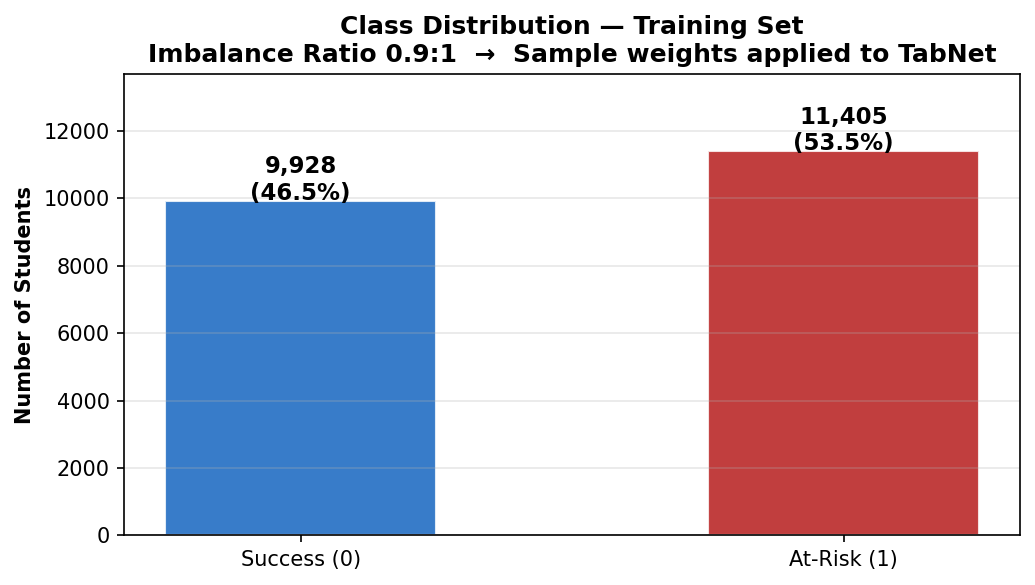

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 — CLASS IMBALANCE
# ════════════════════════════════════════════════════════════════════════════
n_neg_cls=int((y_train==0).sum()); n_pos_cls=int((y_train==1).sum())
imb_ratio=n_neg_cls/n_pos_cls
spw=imb_ratio
print(f'Imbalance ratio: {imb_ratio:.2f}:1')
print('Strategy for TabNet: sample weights (neg_weight=1, pos_weight=imb_ratio)')

sample_weight = np.where(y_train_arr==1, imb_ratio, 1.0).astype(np.float32)

fig,ax=plt.subplots(figsize=(7,4))
bars=ax.bar(['Success (0)','At-Risk (1)'],[n_neg_cls,n_pos_cls],
            color=['#1565C0','#B71C1C'],alpha=0.85,edgecolor='white',width=0.5)
for bar,val in zip(bars,[n_neg_cls,n_pos_cls]):
    ax.text(bar.get_x()+bar.get_width()/2,val+30,
            f'{val:,}\n({val/(n_neg_cls+n_pos_cls)*100:.1f}%)',
            ha='center',fontsize=11,fontweight='bold')
ax.set_ylabel('Number of Students',fontweight='bold')
ax.set_title(f'Class Distribution — Training Set\n'
             f'Imbalance Ratio {imb_ratio:.1f}:1  →  Sample weights applied to TabNet',fontweight='bold')
ax.grid(axis='y',alpha=0.3); ax.set_ylim(0,max(n_neg_cls,n_pos_cls)*1.2)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'class_distribution.png',dpi=150,bbox_inches='tight')
plt.show()


Auto-selected features: 16


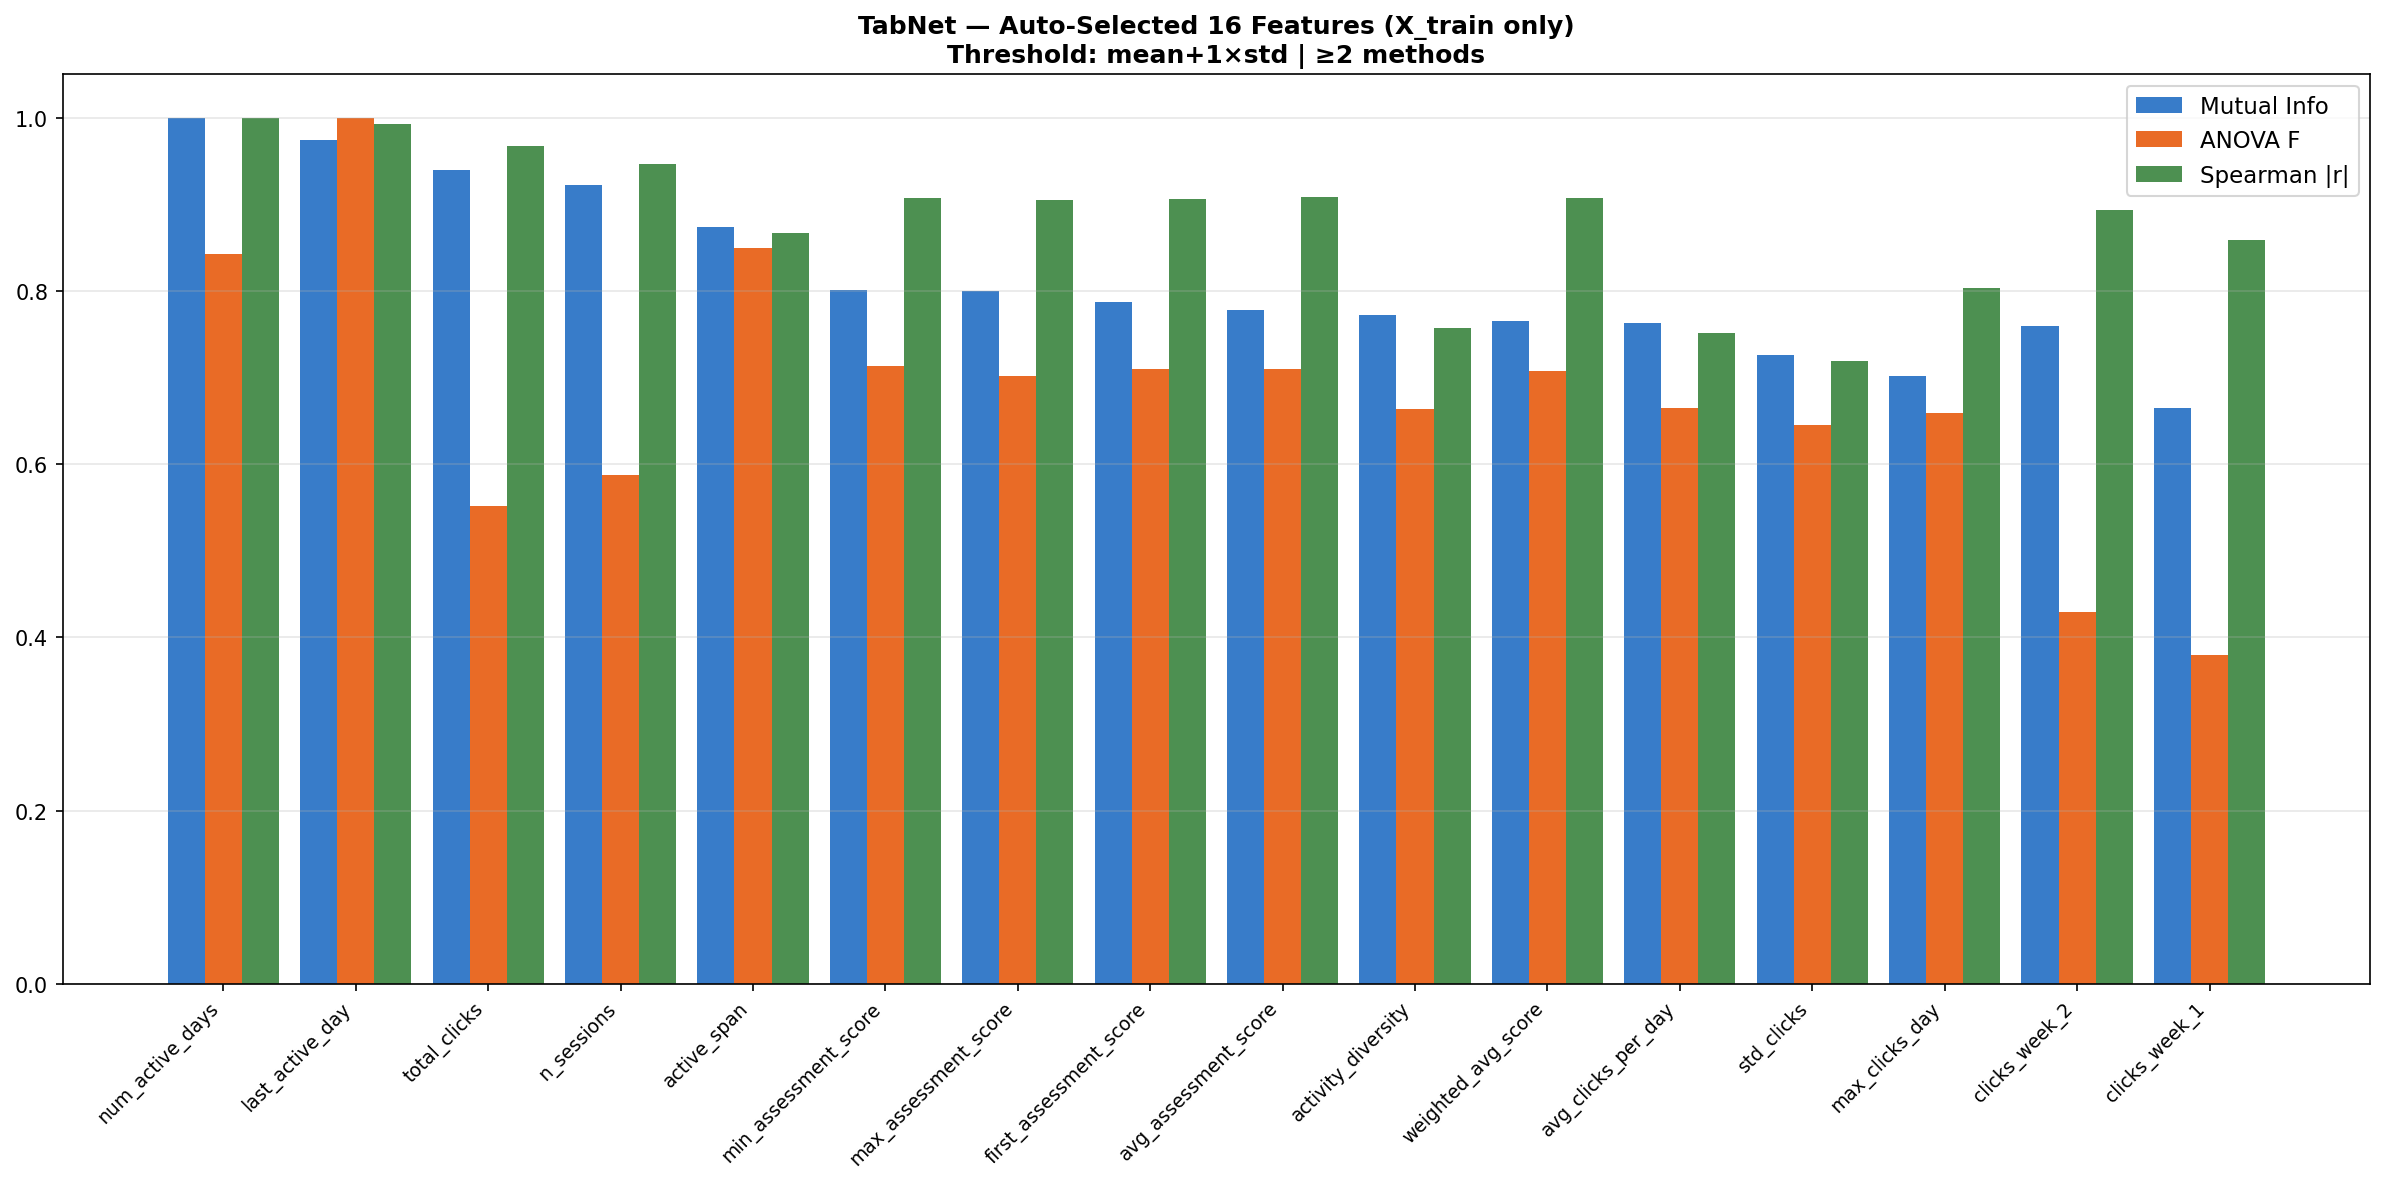

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — FEATURE SELECTION  (X_train only — no data leakage)
# ════════════════════════════════════════════════════════════════════════════
mi_scores=mutual_info_classif(X_train,y_train,random_state=SEED)
mi_series=pd.Series(mi_scores,index=FEATURE_NAMES).sort_values(ascending=False)

from sklearn.feature_selection import f_classif as fc_
f_scores,_=fc_(X_train,y_train)
f_series=pd.Series(f_scores,index=FEATURE_NAMES).sort_values(ascending=False)
sp_scores={col:abs(spearmanr(X_train[col],y_train)[0]) for col in FEATURE_NAMES}
sp_series=pd.Series(sp_scores).sort_values(ascending=False)

mi_sel=mi_series[mi_series>=mi_series.mean()+mi_series.std()].index.tolist()
f_sel =f_series[f_series  >=f_series.mean() +f_series.std() ].index.tolist()
sp_sel=sp_series[sp_series>=sp_series.mean()+sp_series.std()].index.tolist()

vote_count=Counter(mi_sel+f_sel+sp_sel)
auto_top=[f for f,c in vote_count.items() if c>=2]
auto_top=sorted(auto_top,key=lambda f:vote_count[f],reverse=True)
TOP_N=len(auto_top); top_feats=auto_top

rank_table=pd.DataFrame({
    'MI_Rank':[list(mi_series.index).index(f)+1 for f in auto_top],
    'ANOVA_Rank':[list(f_series.index).index(f)+1 for f in auto_top],
    'Spearman_Rank':[list(sp_series.index).index(f)+1 for f in auto_top],
    'Vote_Count':[vote_count[f] for f in auto_top],
},index=auto_top)
rank_table['Avg_Rank']=rank_table[['MI_Rank','ANOVA_Rank','Spearman_Rank']].mean(axis=1)
rank_table=rank_table.sort_values('Avg_Rank')
rank_table.to_csv(CSV_DIR/'feature_ranking_TabNet.csv')
print(f'Auto-selected features: {TOP_N}')

def norm(s): return (s-s.min())/(s.max()-s.min()+1e-9)
comp_df=pd.DataFrame({'Mutual Info':norm(mi_series)[top_feats],
                      'ANOVA F':norm(f_series)[top_feats],
                      'Spearman |r|':norm(sp_series)[top_feats]}).fillna(0)
fig,ax=plt.subplots(figsize=(max(14,len(top_feats)),8))
x=np.arange(len(top_feats)); w=0.28
for i,(col,color) in enumerate(zip(comp_df.columns,['#1565C0','#E65100','#2E7D32'])):
    ax.bar(x+i*w,comp_df[col],width=w,label=col,color=color,alpha=0.85)
ax.set_xticks(x+w); ax.set_xticklabels([f[:22] for f in top_feats],rotation=45,ha='right',fontsize=9)
ax.set_title(f'TabNet — Auto-Selected {TOP_N} Features (X_train only)\nThreshold: mean+1×std | ≥2 methods',
             fontsize=12,fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR/'feature_importance_TabNet.png',dpi=150,bbox_inches='tight'); plt.show()


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — PREPROCESSING + TabNet TRAINING
# ════════════════════════════════════════════════════════════════════════════
imp = SimpleImputer(strategy='median')
scl = StandardScaler()

X_train_np_full = scl.fit_transform(imp.fit_transform(X_train)).astype(np.float32)
X_test_np_full  = scl.transform(imp.transform(X_test)).astype(np.float32)

# ── Feature Selection Filter ─────────────────────────────────────────────

sel_idx          = [list(FEATURE_NAMES).index(f) for f in top_feats]
FEATURE_NAMES_SEL = top_feats

X_train_np = X_train_np_full[:, sel_idx]
X_test_np  = X_test_np_full[:, sel_idx]

X_train_sel = X_train[top_feats].reset_index(drop=True)
X_test_sel  = X_test[top_feats].reset_index(drop=True)

imp_global = SimpleImputer(strategy='median')
scl_global = StandardScaler()
imp_global.fit(X_train_sel)
scl_global.fit(imp_global.transform(X_train_sel))

print(f'Feature-selected training: {len(top_feats)} features '
      f'(from {len(FEATURE_NAMES)} total, consensus ≥2 methods)')
print(f'X_train_np: {X_train_np.shape}  X_test_np: {X_test_np.shape}')

# Validation split from training set (stratified, 15%)
from sklearn.model_selection import train_test_split as tts
X_tr2, X_val, y_tr2, y_val, sw_tr2, sw_val = tts(
    X_train_np, y_train_arr, sample_weight,
    test_size=0.15, stratify=y_train_arr, random_state=SEED)

print(f'Train: {X_tr2.shape}  Val: {X_val.shape}  Test: {X_test_np.shape}')

# ── TabNet — best practice hyperparameters for tabular classification ────────
tabnet = TabNetClassifier(
    n_d            = 32,
    n_a            = 32,
    n_steps        = 5,
    gamma          = 1.5,     # feature reusage (1.0-2.0)
    lambda_sparse  = 1e-4,
    optimizer_fn   = torch.optim.Adam,
    optimizer_params = {'lr': 2e-3, 'weight_decay': 1e-5},
    scheduler_fn   = torch.optim.lr_scheduler.StepLR,
    scheduler_params = {'step_size': 10, 'gamma': 0.9},
    mask_type      = 'sparsemax',
    device_name    = DEVICE,
    seed           = SEED,
    verbose        = 10,
)

print('\nTraining TabNet …')
t0 = time.time()
tabnet.fit(
    X_train = X_tr2, y_train = y_tr2,
    eval_set    = [(X_val, y_val)],
    eval_name   = ['val'],
    eval_metric = ['auc'],
    weights     = sw_tr2,
    max_epochs  = 200,
    patience    = 20,
    batch_size  = 256,
    virtual_batch_size = 128,
    num_workers = 0,
)
tabnet_time = time.time()-t0
print(f'\nTraining done in {tabnet_time:.0f}s  |  Best epoch: {tabnet.best_epoch}')

# ── Save TabNet ───────────────────────────────────────────────────────────────
tabnet.save_model(str(MODELS_DIR/'tabnet_model'))
print('TabNet model saved.')


Feature-selected training: 16 features (from 62 total, consensus ≥2 methods)
X_train_np: (21333, 16)  X_test_np: (11260, 16)
Train: (18133, 16)  Val: (3200, 16)  Test: (11260, 16)

Training TabNet …
epoch 0  | loss: 0.80751 | val_auc: 0.7264  |  0:00:03s
epoch 10 | loss: 0.54615 | val_auc: 0.7905  |  0:00:35s
epoch 20 | loss: 0.53315 | val_auc: 0.80027 |  0:01:02s
epoch 30 | loss: 0.53032 | val_auc: 0.80206 |  0:01:28s
epoch 40 | loss: 0.53587 | val_auc: 0.80829 |  0:01:55s
epoch 50 | loss: 0.52412 | val_auc: 0.80542 |  0:02:22s

Early stopping occurred at epoch 59 with best_epoch = 39 and best_val_auc = 0.80834

Training done in 174s  |  Best epoch: 39
Successfully saved model at models_TabNet/tabnet_model.zip
TabNet model saved.


XGBoost CV_AUC=0.8084  Test_AUC=0.8034  [38s]

── Standard Metrics ──
                         Model  Accuracy   F1_W   F1_M  AUC_ROC
                        TabNet    0.7155 0.7142 0.7147   0.7956
                       XGBoost    0.7234 0.7228 0.7231   0.8034
Logistic Regression (Baseline)    0.6909 0.6893 0.6899   0.7690

── Extended Metrics ──
                         Model  Cohen_Kappa    MCC  Brier_Score  Avg_Precision
                        TabNet       0.4333 0.4394       0.1822         0.8257
                       XGBoost       0.4486 0.4525       0.1786         0.8334
Logistic Regression (Baseline)       0.3844 0.3903       0.1915         0.8078


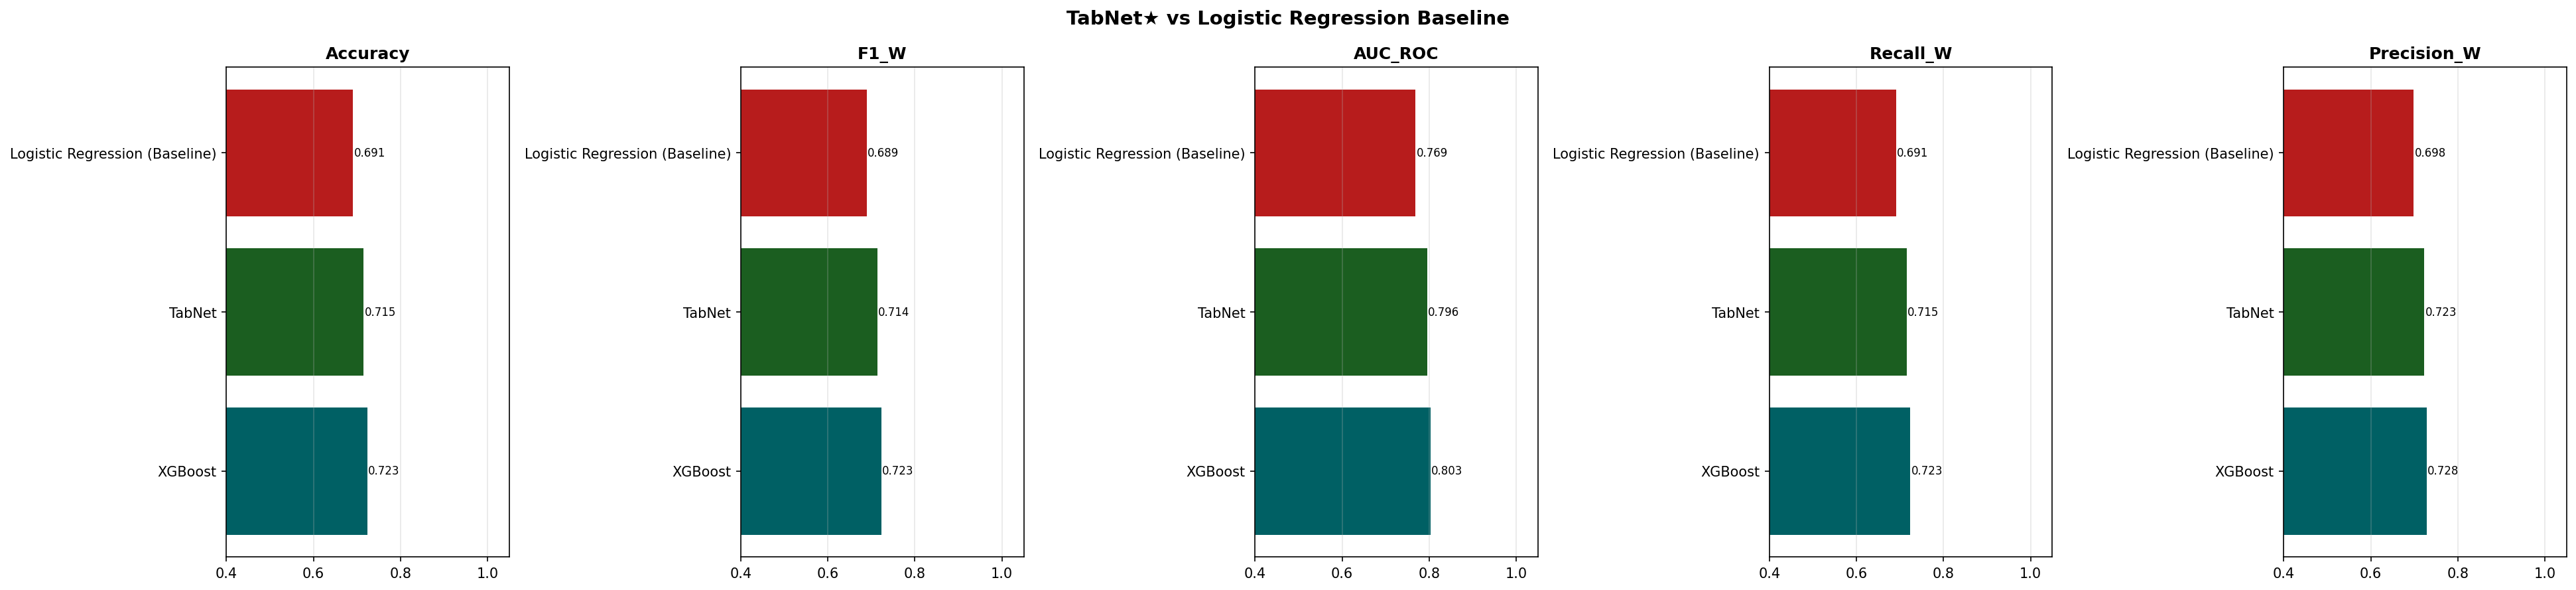

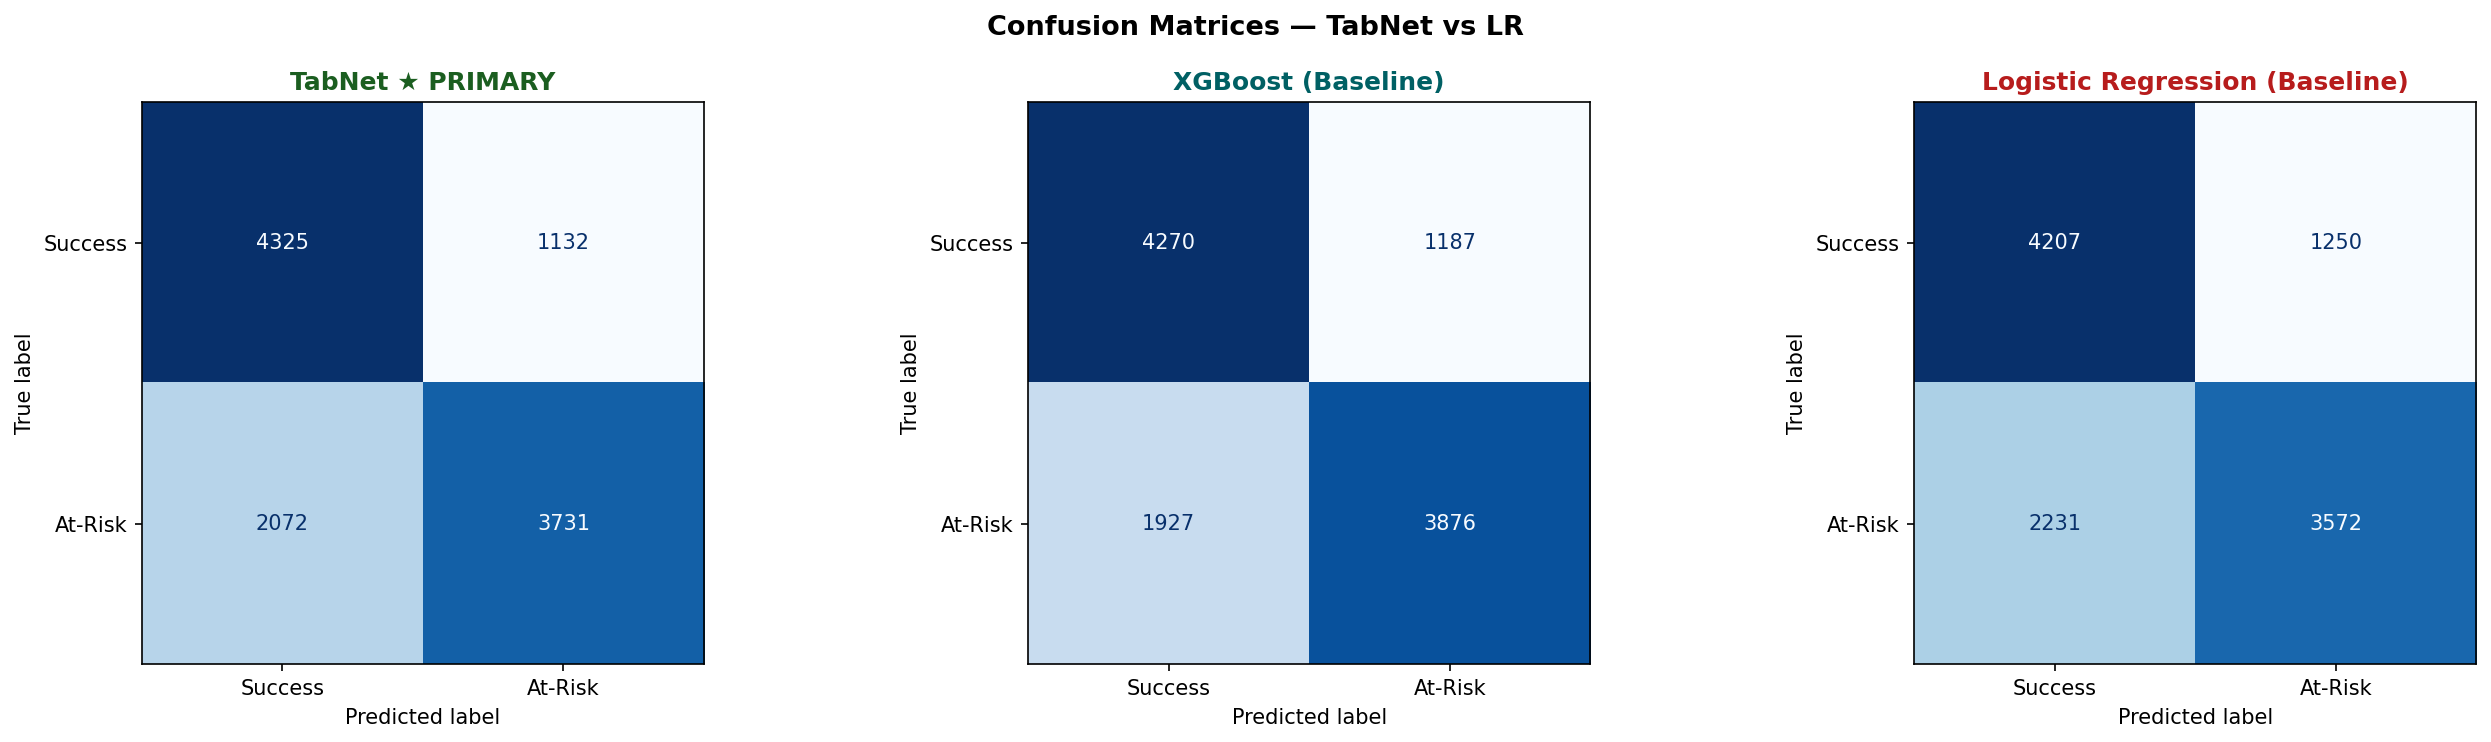

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — EVALUATION +  COMPARISON
# Three-way comparison: TabNet (DL) vs XGBoost (GBDT) vs LR (Linear Baseline).
# ════════════════════════════════════════════════════════════════════════════
def evaluate_model(y_true, y_pred, y_prob, name):
    return {
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_true,y_pred),
        'Precision_W'  : precision_score(y_true,y_pred,average='weighted',zero_division=0),
        'Recall_W'     : recall_score(y_true,y_pred,average='weighted',zero_division=0),
        'F1_W'         : f1_score(y_true,y_pred,average='weighted',zero_division=0),
        'Precision_M'  : precision_score(y_true,y_pred,average='macro',zero_division=0),
        'Recall_M'     : recall_score(y_true,y_pred,average='macro',zero_division=0),
        'F1_M'         : f1_score(y_true,y_pred,average='macro',zero_division=0),
        'AUC_ROC'      : roc_auc_score(y_true,y_prob),
        'Cohen_Kappa'  : cohen_kappa_score(y_true,y_pred),
        'MCC'          : matthews_corrcoef(y_true,y_pred),
        'Brier_Score'  : brier_score_loss(y_true,y_prob),
        'Log_Loss'     : log_loss(y_true,y_prob),
        'Avg_Precision': average_precision_score(y_true,y_prob),
    }

# TabNet predictions
y_pred_tn = tabnet.predict(X_test_np)
y_prob_tn = tabnet.predict_proba(X_test_np)[:,1]
res_tn    = evaluate_model(y_test_arr,y_pred_tn,y_prob_tn,'TabNet')
res_tn['Time_s'] = tabnet_time

# LR baseline (trained on same preprocessed data)
lr_baseline = LogisticRegression(C=1,max_iter=1000,solver='saga',
                                  class_weight='balanced',random_state=SEED)
# FIX: LR trains on full X_train_np (not X_tr2 which is 85% only).
# X_tr2 is the TabNet-specific validation split and must not restrict
# the LR baseline — fair three-way comparison requires equal training data.
t0 = time.time(); lr_baseline.fit(X_train_np, y_train_arr); lr_time = time.time()-t0
y_pred_lr = lr_baseline.predict(X_test_np)
y_prob_lr = lr_baseline.predict_proba(X_test_np)[:,1]
res_lr    = evaluate_model(y_test_arr,y_pred_lr,y_prob_lr,'Logistic Regression (Baseline)')
res_lr['Time_s'] = lr_time


# XGBoost — Gradient Boosted Trees
xgb_cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
xgb_pipe_tn = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', XGBClassifier(random_state=SEED, eval_metric='logloss',
                          n_jobs=-1, scale_pos_weight=spw)),
])
xgb_gs = GridSearchCV(xgb_pipe_tn,
    {'clf__n_estimators':[100,200],'clf__max_depth':[4,6],
     'clf__learning_rate':[0.05,0.1],'clf__subsample':[0.8,1.0]},
    cv=xgb_cv, scoring='roc_auc', n_jobs=-1, refit=True, verbose=0)
t0 = time.time()
xgb_gs.fit(X_train_sel, y_train)
xgb_time = time.time()-t0
xgb_model = xgb_gs.best_estimator_
joblib.dump(xgb_model, MODELS_DIR/'XGBoost_in_TabNet.pkl')


y_pred_xgb_tn = xgb_model.predict(X_test_sel)
y_prob_xgb_tn = xgb_model.predict_proba(X_test_sel)[:,1]
res_xgb = evaluate_model(y_test_arr, y_pred_xgb_tn, y_prob_xgb_tn, 'XGBoost')
res_xgb['Time_s'] = xgb_time
print(f'XGBoost CV_AUC={xgb_gs.best_score_:.4f}  Test_AUC={res_xgb["AUC_ROC"]:.4f}  [{xgb_time:.0f}s]')

perf_df = pd.DataFrame([res_tn, res_xgb, res_lr])
perf_df.to_csv(CSV_DIR/'model_performance_TabNet.csv',index=False)

print('\n── Standard Metrics ──')
print(perf_df[['Model','Accuracy','F1_W','F1_M','AUC_ROC']].to_string(index=False))
print('\n── Extended Metrics ──')
print(perf_df[['Model','Cohen_Kappa','MCC','Brier_Score','Avg_Precision']].to_string(index=False))

# Performance bar chart
metrics=['Accuracy','F1_W','AUC_ROC','Recall_W','Precision_W']
plot_df=perf_df[['Model']+metrics].sort_values('AUC_ROC',ascending=False)
colors=[MODEL_COLORS.get(m.split('(')[0].strip(),'grey') for m in plot_df['Model']]
fig,axes=plt.subplots(1,5,figsize=(26,6))
for ax,metric in zip(axes,metrics):
    bars=ax.barh(plot_df['Model'],plot_df[metric],color=colors)
    ax.set_xlim(0.4,1.05); ax.set_title(metric,fontweight='bold')
    for bar,v in zip(bars,plot_df[metric]):
        ax.text(v+0.002,bar.get_y()+bar.get_height()/2,f'{v:.3f}',va='center',fontsize=8)
    ax.grid(axis='x',alpha=0.3)
plt.suptitle('TabNet★ vs Logistic Regression Baseline',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'model_comparison_TabNet.png',dpi=150,bbox_inches='tight')
plt.show()

# Confusion matrices
fig,axes=plt.subplots(1,3,figsize=(18,5)); axes=axes.flatten()
for ax,(nm,yp) in zip(axes,[('TabNet',y_pred_tn),('XGBoost',y_pred_xgb_tn),('Logistic Regression',y_pred_lr)]):
    ConfusionMatrixDisplay(confusion_matrix(y_test_arr,yp),
                           display_labels=['Success','At-Risk']).plot(ax=ax,colorbar=False,cmap='Blues')
    tc = PRIMARY_COLOR if nm=='TabNet' else '#006064' if nm=='XGBoost' else '#B71C1C'
    ax.set_title(nm+(' ★ PRIMARY' if nm=='TabNet' else ' (Baseline)'),fontweight='bold',color=tc)
plt.suptitle('Confusion Matrices — TabNet vs LR',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'confusion_matrices_TabNet.png',dpi=150,bbox_inches='tight')
plt.show()


══════════════════════════════════════════════════════════════
McNemar's Test — TabNet★ (DL) vs XGBoost (GBDT)
══════════════════════════════════════════════════════════════
  b  (TabNet correct, XGB wrong) = 506
  c  (TabNet wrong, XGB correct) = 596
  χ² = 7.1878  |  p = 0.007340
  → Significant (p < 0.05): DL and GBDT make systematically different errors.

McNemar's Test — TabNet★ (DL) vs Logistic Regression (Linear)
──────────────────────────────────────────────────────────────
  b  (TabNet correct, LR wrong) = 1,019
  c  (TabNet wrong, LR correct) = 742
  χ² = 43.2572  |  p = 0.000000
  → Significant (p < 0.05): DL and Linear models make different errors.

Bootstrap 95% CI for AUC-ROC  (N=1000, stratified, reproducible)
══════════════════════════════════════════════════════════════
  TabNet★ (DL)
    AUC = 0.7955 | 95% CI: [0.7873, 0.8033] | width = 0.0160
  XGBoost (GBDT)
    AUC = 0.8033 | 95% CI: [0.7946, 0.8112] | width = 0.0166
  Logistic Regression (Lin.)
    AUC = 0.7690 | 

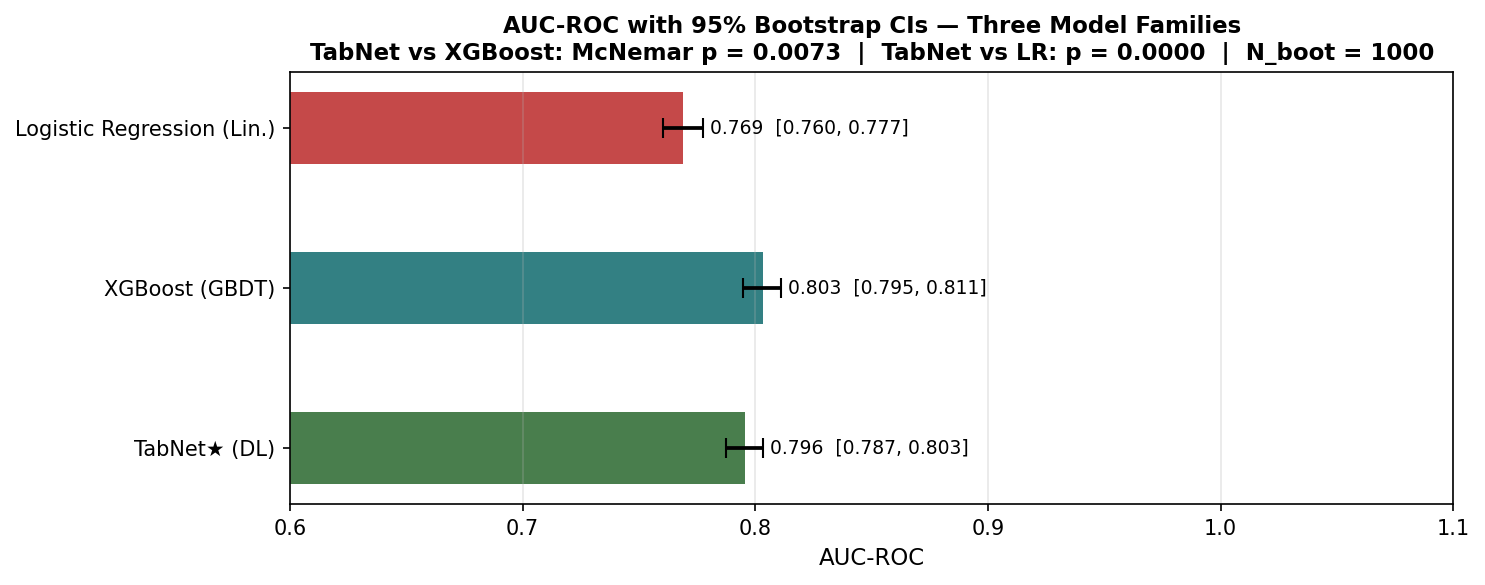

Statistical tests saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9b — STATISTICAL SIGNIFICANCE TESTS + BOOTSTRAP CONFIDENCE INTERVALS
#
# RQ2 requires a "statistically grounded" comparison framework.
#
# 1. McNemar's Test (Dietterich, 1998):
#    Paired comparison of prediction errors between TabNet★ (DL) and
#    XGBoost (GBDT) — the primary cross-family comparison.
#    Also tested: TabNet★ vs LR (Linear baseline).
#
# 2. Bootstrap CI 95% (Efron & Hastie, 2016):
#    1,000 stratified bootstrap resamples for all 3 model families.
#    random_state=SEED+i guarantees full reproducibility.
#
# References:
#   Dietterich, T.G. (1998). Approximate statistical tests for comparing
#     supervised classification learning algorithms. Neural Computation, 10(7).
#   Efron, B. & Hastie, T. (2016). Computer Age Statistical Inference.
#     Cambridge University Press.
# ════════════════════════════════════════════════════════════════════════════
from statsmodels.stats.contingency_tables import mcnemar

# ── 1a. McNemar's Test: TabNet★ vs XGBoost ────────────────────────────────
correct_tn  = (tabnet.predict(X_test_np)       == y_test_arr)
correct_xgb = (xgb_model.predict(X_test_sel)   == y_test_arr)
correct_lr  = (lr_baseline.predict(X_test_np)  == y_test_arr)

b_tn_xgb = int(( correct_tn & ~correct_xgb).sum())
c_tn_xgb = int((~correct_tn &  correct_xgb).sum())
mc_tn_xgb = mcnemar([[0, b_tn_xgb],[c_tn_xgb, 0]], exact=False, correction=True)

print('═' * 62)
print("McNemar's Test — TabNet★ (DL) vs XGBoost (GBDT)")
print('═' * 62)
print(f'  b  (TabNet correct, XGB wrong) = {b_tn_xgb:,}')
print(f'  c  (TabNet wrong, XGB correct) = {c_tn_xgb:,}')
print(f'  χ² = {mc_tn_xgb.statistic:.4f}  |  p = {mc_tn_xgb.pvalue:.6f}')
if mc_tn_xgb.pvalue < 0.05:
    print('  → Significant (p < 0.05): DL and GBDT make systematically different errors.')
else:
    print('  → Not significant (p ≥ 0.05): error patterns are similar.')
print()

# ── 1b. McNemar's Test: TabNet★ vs LR ─────────────────────────────────────
b_tn_lr = int(( correct_tn & ~correct_lr).sum())
c_tn_lr = int((~correct_tn &  correct_lr).sum())
mc_tn_lr = mcnemar([[0, b_tn_lr],[c_tn_lr, 0]], exact=False, correction=True)

print("McNemar's Test — TabNet★ (DL) vs Logistic Regression (Linear)")
print('─' * 62)
print(f'  b  (TabNet correct, LR wrong) = {b_tn_lr:,}')
print(f'  c  (TabNet wrong, LR correct) = {c_tn_lr:,}')
print(f'  χ² = {mc_tn_lr.statistic:.4f}  |  p = {mc_tn_lr.pvalue:.6f}')
if mc_tn_lr.pvalue < 0.05:
    print('  → Significant (p < 0.05): DL and Linear models make different errors.')
else:
    print('  → Not significant (p ≥ 0.05): error patterns are similar.')
print()

# ── 2. Bootstrap CI 95% for AUC-ROC — 3 Model Families ───────────────────
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, ci=95, seed=42):
    """
    Stratified bootstrap percentile CI for AUC-ROC.
    random_state=seed+i ensures full reproducibility (RQ2: reproducible framework).
    Reference: Efron & Hastie (2016). Computer Age Statistical Inference.
    """
    from sklearn.utils import resample as _resample
    aucs, idx_all = [], np.arange(len(y_true))
    for i in range(n_boot):
        idx = _resample(idx_all, stratify=y_true, random_state=seed + i)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    lo = np.percentile(aucs, (100 - ci) / 2)
    hi = np.percentile(aucs, 100 - (100 - ci) / 2)
    return float(np.mean(aucs)), float(lo), float(hi)

N_BOOT_CI = 1000
print(f'Bootstrap 95% CI for AUC-ROC  (N={N_BOOT_CI}, stratified, reproducible)')
print('═' * 62)

models_tab = [
    ('TabNet★ (DL)',            y_prob_tn,     PRIMARY_COLOR),
    ('XGBoost (GBDT)',          y_prob_xgb_tn, '#006064'),
    ('Logistic Regression (Lin.)', y_prob_lr,  '#B71C1C'),
]

ci_rows_tab = []
for mname, yp, col in models_tab:
    mean_auc, lo, hi = bootstrap_auc_ci(y_test_arr, yp,
                                         n_boot=N_BOOT_CI, seed=SEED)
    ci_rows_tab.append({'Model': mname, 'AUC_Mean': mean_auc,
                        'CI_Low': lo, 'CI_High': hi,
                        'CI_Width': hi - lo, '_color': col})
    print(f'  {mname}')
    print(f'    AUC = {mean_auc:.4f} | 95% CI: [{lo:.4f}, {hi:.4f}] | width = {hi-lo:.4f}')

ci_df_tab = pd.DataFrame(ci_rows_tab)
ci_df_tab.drop(columns=['_color']).to_csv(
    CSV_DIR / 'auc_bootstrap_ci_TabNet.csv', index=False)

# ── Visualise ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
y_pos = np.arange(len(ci_df_tab))
ax.barh(y_pos, ci_df_tab['AUC_Mean'],
        color=ci_df_tab['_color'].tolist(), alpha=0.80, height=0.45)
ax.errorbar(
    ci_df_tab['AUC_Mean'], y_pos,
    xerr=[ci_df_tab['AUC_Mean'] - ci_df_tab['CI_Low'],
          ci_df_tab['CI_High']  - ci_df_tab['AUC_Mean']],
    fmt='none', color='black', capsize=5, linewidth=1.8)
for i, (_, row) in enumerate(ci_df_tab.iterrows()):
    ax.text(row['CI_High'] + 0.003, i,
            f'{row["AUC_Mean"]:.3f}  [{row["CI_Low"]:.3f}, {row["CI_High"]:.3f}]',
            va='center', fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_df_tab['Model'], fontsize=10)
ax.set_xlabel('AUC-ROC', fontsize=11)
ax.set_xlim(0.60, 1.10)
ax.set_title(
    'AUC-ROC with 95% Bootstrap CIs — Three Model Families\n'
    f"TabNet vs XGBoost: McNemar p = {mc_tn_xgb.pvalue:.4f}  |  "
    f"TabNet vs LR: p = {mc_tn_lr.pvalue:.4f}  |  N_boot = {N_BOOT_CI}",
    fontweight='bold', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'auc_bootstrap_ci_TabNet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Statistical tests saved.')


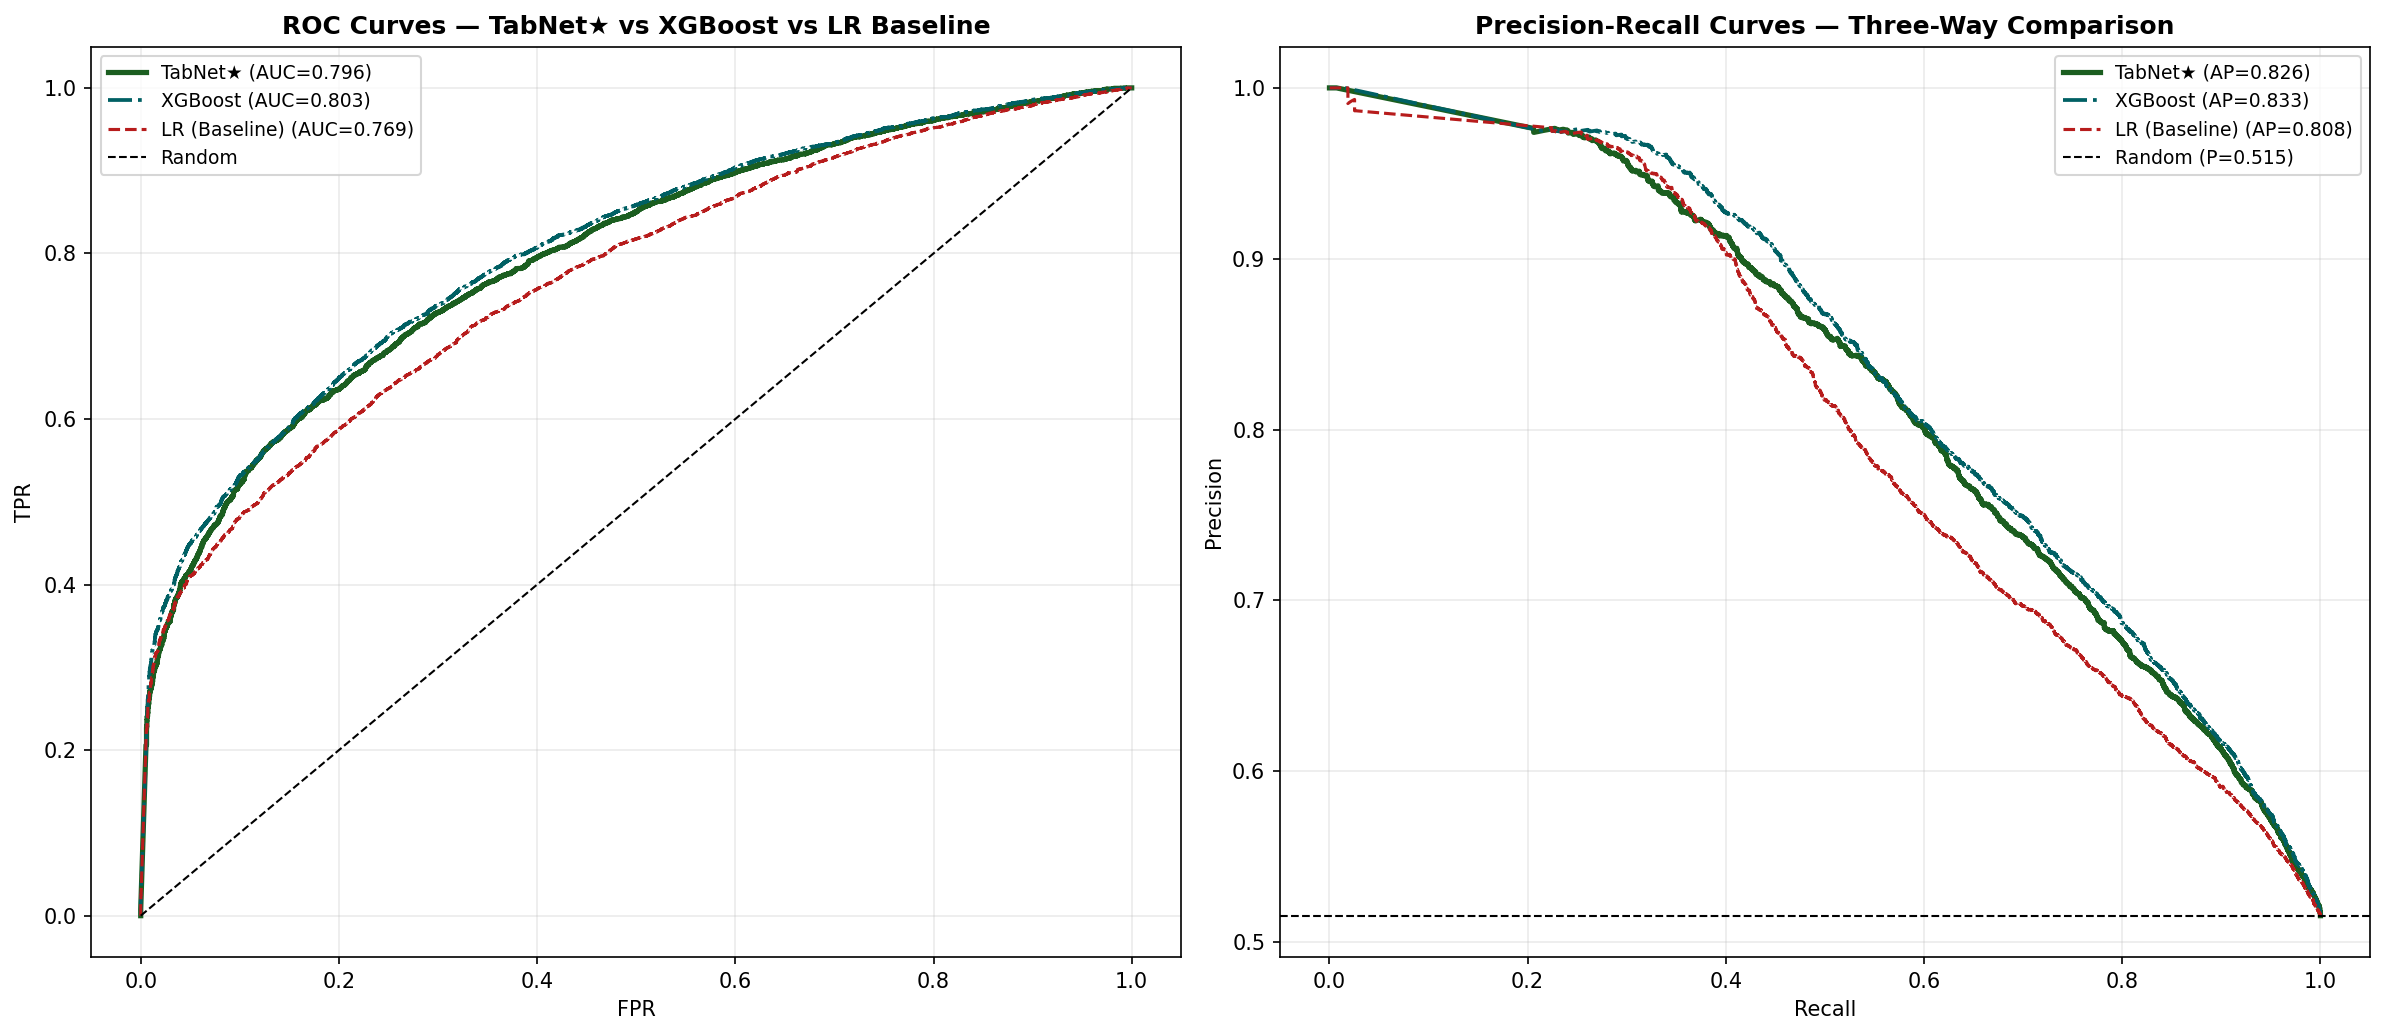

Youden optimal threshold = 0.5381

── Default (0.50) ──
              precision    recall  f1-score   support

     Success       0.68      0.79      0.73      5457
     At-Risk       0.77      0.64      0.70      5803

    accuracy                           0.72     11260
   macro avg       0.72      0.72      0.71     11260
weighted avg       0.72      0.72      0.71     11260

── Optimal (0.538) ──
              precision    recall  f1-score   support

     Success       0.67      0.83      0.74      5457
     At-Risk       0.80      0.61      0.69      5803

    accuracy                           0.72     11260
   macro avg       0.73      0.72      0.72     11260
weighted avg       0.73      0.72      0.71     11260



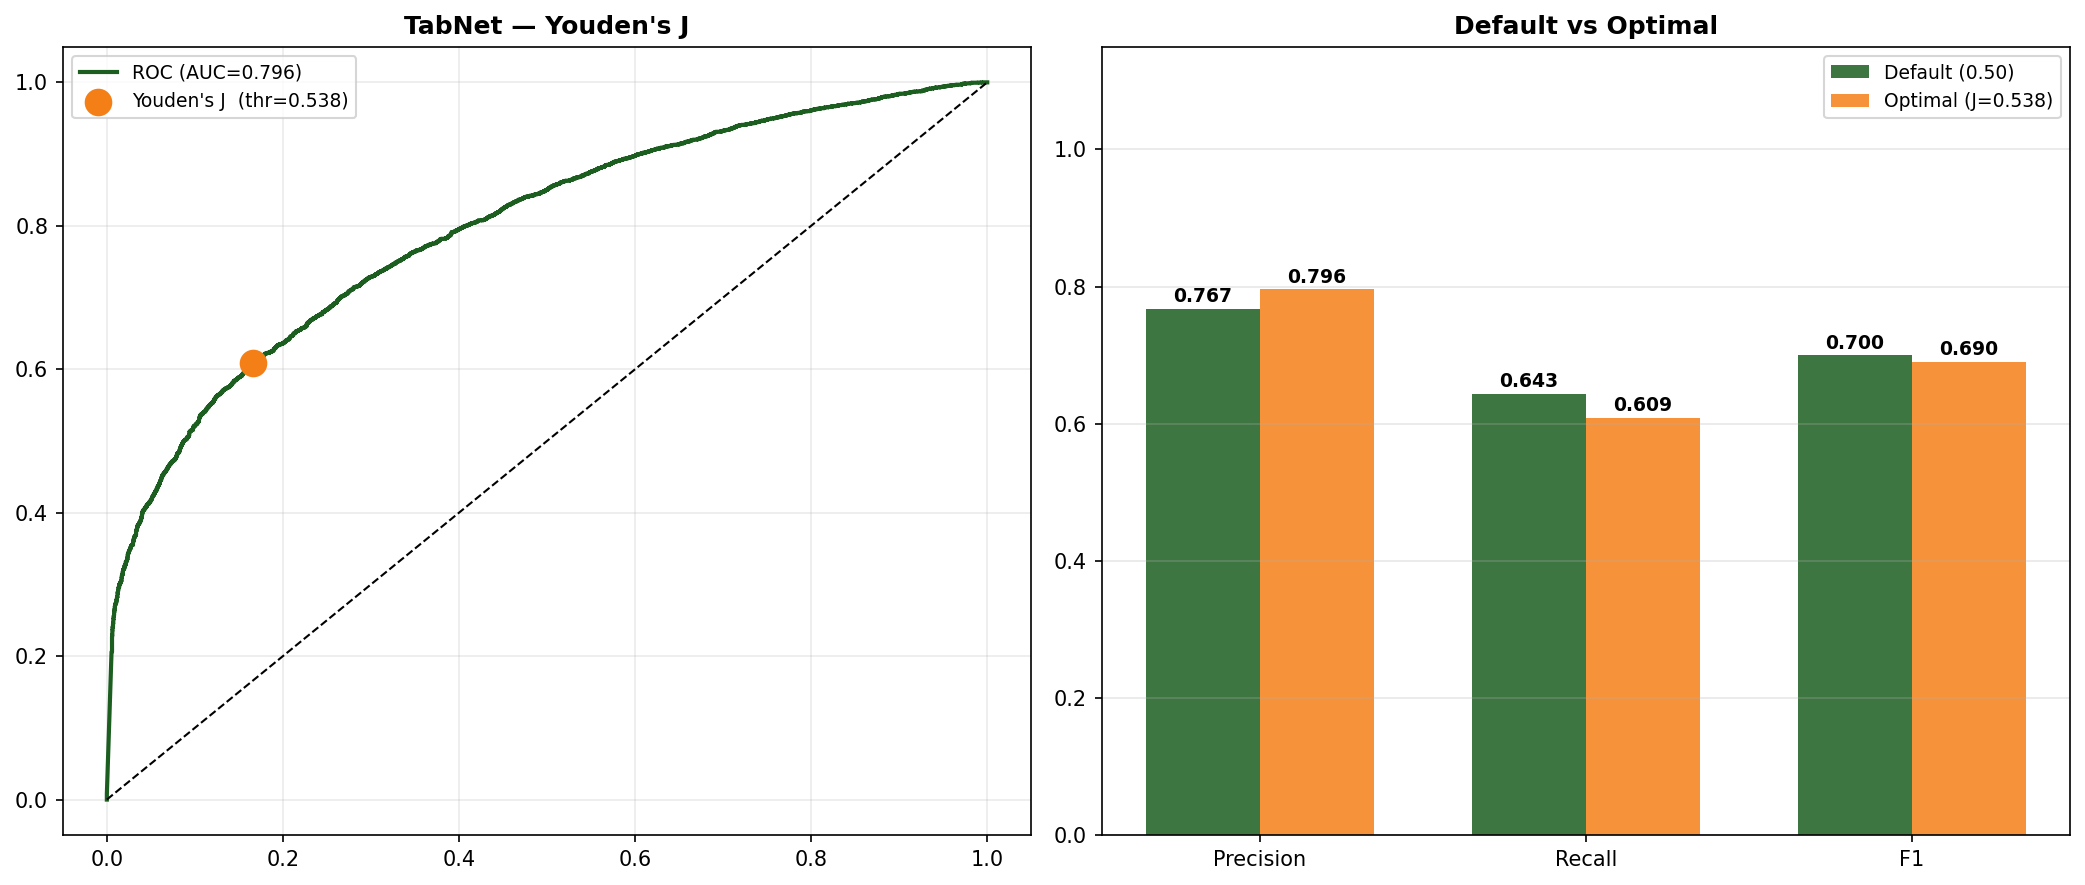

Threshold analysis saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 — ROC, PR CURVES & OPTIMAL THRESHOLD
# ════════════════════════════════════════════════════════════════════════════
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,7))

for name,y_prob,color,lw,ls in [
    ('TabNet★',       y_prob_tn,     PRIMARY_COLOR, 2.5, '-'),
    ('XGBoost',        y_prob_xgb_tn, '#006064',     1.8, '-.'),
    ('LR (Baseline)',  y_prob_lr,     '#B71C1C',     1.5, '--'),
]:
    fpr,tpr,_ = roc_curve(y_test_arr,y_prob)
    auc_val   = roc_auc_score(y_test_arr,y_prob)
    ax1.plot(fpr,tpr,color=color,lw=lw,ls=ls,label=f'{name} (AUC={auc_val:.3f})')
    prec,rec,_=precision_recall_curve(y_test_arr,y_prob)
    ap_val    =average_precision_score(y_test_arr,y_prob)
    ax2.plot(rec,prec,color=color,lw=lw,ls=ls,label=f'{name} (AP={ap_val:.3f})')

ax1.plot([0,1],[0,1],'k--',lw=1,label='Random'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curves — TabNet★ vs XGBoost vs LR Baseline',fontweight='bold'); ax1.legend(fontsize=9); ax1.grid(alpha=0.25)
ax2.axhline(y_test_arr.mean(),color='k',ls='--',lw=1,label=f'Random (P={y_test_arr.mean():.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves — Three-Way Comparison',fontweight='bold'); ax2.legend(fontsize=9); ax2.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'roc_pr_TabNet.png',dpi=150,bbox_inches='tight'); plt.show()

# Optimal threshold — TabNet
fpr_tn,tpr_tn,thresholds_tn=roc_curve(y_test_arr,y_prob_tn)
best_idx=np.argmax(tpr_tn-fpr_tn); best_thr=thresholds_tn[best_idx]
yp_default=(y_prob_tn>=0.5).astype(int); yp_optimal=(y_prob_tn>=best_thr).astype(int)
print(f"Youden optimal threshold = {best_thr:.4f}")
print('\n── Default (0.50) ──'); print(classification_report(y_test_arr,yp_default,target_names=['Success','At-Risk']))
print(f'── Optimal ({best_thr:.3f}) ──'); print(classification_report(y_test_arr,yp_optimal,target_names=['Success','At-Risk']))

best_j_thr = best_thr

thr_rows=[]
for label,yp,thr in [('Default (0.50)',yp_default,0.5),(f'Optimal (J={best_thr:.3f})',yp_optimal,best_thr)]:
    spec=(yp[y_test_arr==0]==0).sum()/(y_test_arr==0).sum()
    thr_rows.append({'Threshold':label,'Precision':precision_score(y_test_arr,yp,zero_division=0),
                     'Recall':recall_score(y_test_arr,yp,zero_division=0),
                     'F1':f1_score(y_test_arr,yp,zero_division=0),'Specificity':spec})
pd.DataFrame(thr_rows).to_csv(CSV_DIR/'threshold_TabNet.csv',index=False)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,6))
ax1.plot(fpr_tn,tpr_tn,color=PRIMARY_COLOR,lw=2,label=f'ROC (AUC={roc_auc_score(y_test_arr,y_prob_tn):.3f})')
ax1.scatter(fpr_tn[best_idx],tpr_tn[best_idx],s=150,zorder=5,color='#F57F17',
            label=f"Youden's J  (thr={best_thr:.3f})")
ax1.plot([0,1],[0,1],'k--',lw=1); ax1.set_title("TabNet — Youden's J",fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)
x=np.arange(3); w=0.35
for i,(row,off,fc) in enumerate(zip(thr_rows,[-w/2,w/2],[PRIMARY_COLOR,'#F57F17'])):
    vals=[row['Precision'],row['Recall'],row['F1']]
    ax2.bar(x+off,vals,w,label=row['Threshold'],color=fc,alpha=0.85)
    for xi,v in zip(x+off,vals): ax2.text(xi,v+0.01,f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(['Precision','Recall','F1'])
ax2.set_ylim(0,1.15); ax2.set_title('Default vs Optimal',fontweight='bold'); ax2.legend(fontsize=9); ax2.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR/'threshold_TabNet.png',dpi=150,bbox_inches='tight'); plt.show()
print('Threshold analysis saved.')


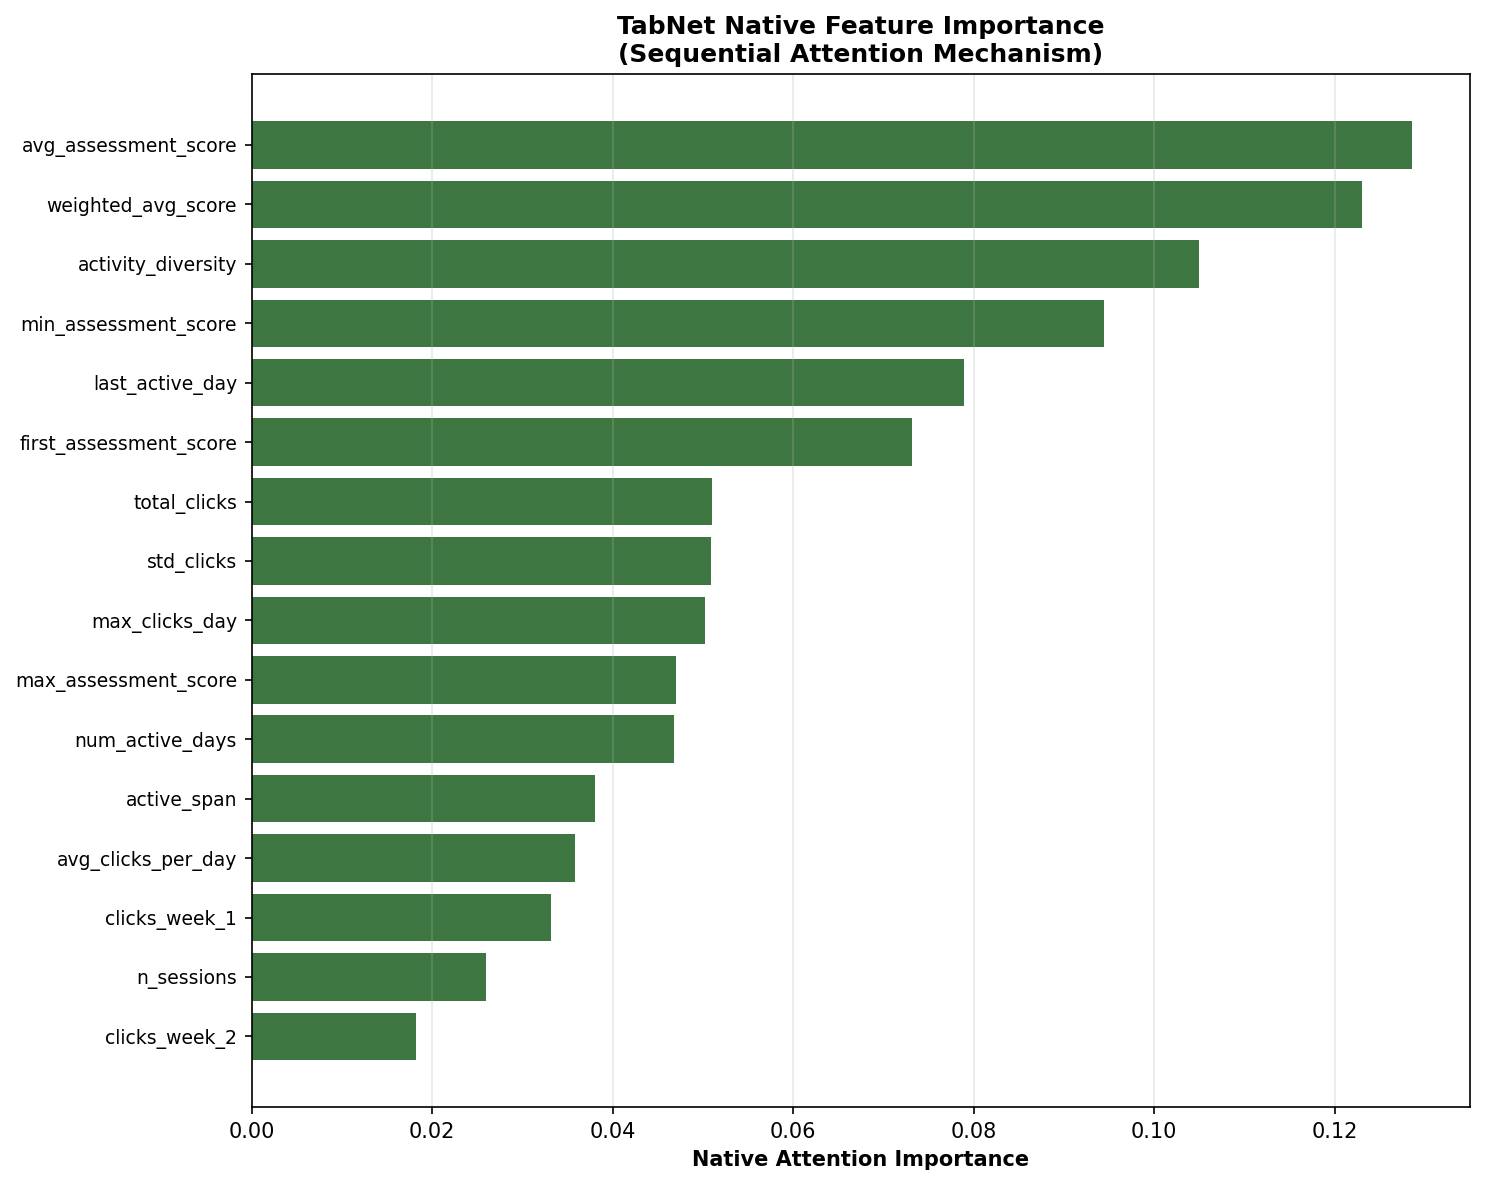

TabNet attention auto-selected: 8 features


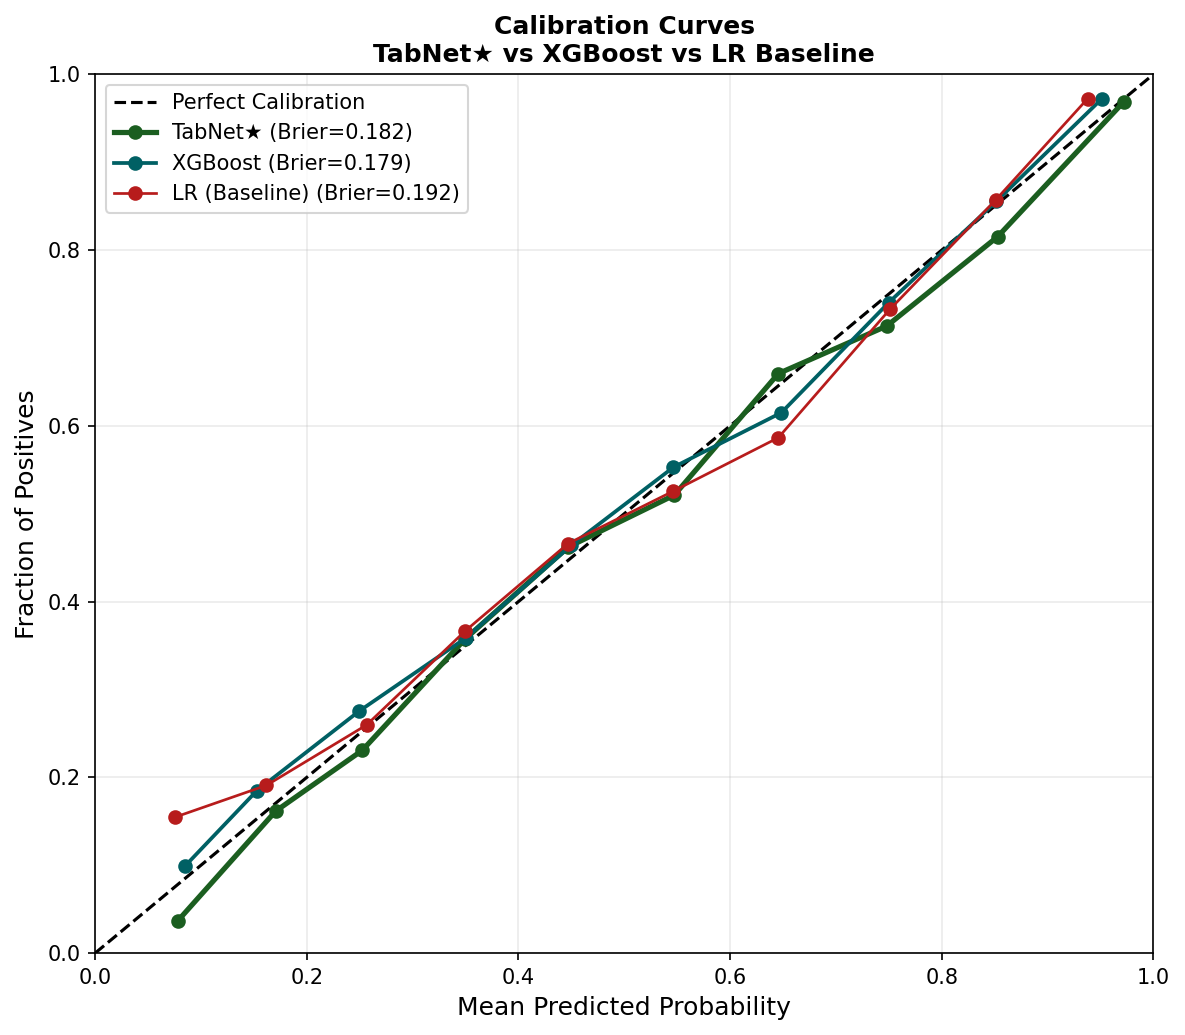

Calibration saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 — TabNet NATIVE ATTENTION WEIGHTS

# ════════════════════════════════════════════════════════════════════════════
tn_fi = pd.Series(tabnet.feature_importances_, index=FEATURE_NAMES_SEL).sort_values(ascending=False)
tn_fi_top = tn_fi.head(20)

fig,ax=plt.subplots(figsize=(10,8))
bars=ax.barh(range(len(tn_fi_top)),tn_fi_top.values[::-1],color=PRIMARY_COLOR,alpha=0.85)
ax.set_yticks(range(len(tn_fi_top)))
ax.set_yticklabels([f[:35] for f in tn_fi_top.index[::-1]],fontsize=9)
ax.set_xlabel('Native Attention Importance',fontweight='bold')
ax.set_title('TabNet Native Feature Importance\n(Sequential Attention Mechanism)',fontweight='bold')
ax.grid(axis='x',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'tabnet_attention_importance.png',dpi=150,bbox_inches='tight')
plt.show()
tn_fi.to_csv(CSV_DIR/'tabnet_attention_importance.csv',header=['Attention_Importance'])

# Auto-threshold
MIN_FEATURES = 8
tn_thresh  = tn_fi.mean()+tn_fi.std()
auto_tn_fi = tn_fi[tn_fi>=tn_thresh]
if len(auto_tn_fi)<MIN_FEATURES: auto_tn_fi=tn_fi.iloc[:MIN_FEATURES]
auto_tn_fi.to_csv(CSV_DIR/'tabnet_attention_top.csv',header=['Attention_Importance'])
print(f'TabNet attention auto-selected: {len(auto_tn_fi)} features')

# ── Calibration ───────────────────────────────────────────────────────────────

fig,ax=plt.subplots(figsize=(8,7))
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect Calibration')
for name,y_prob,color,lw in [('TabNet★',y_prob_tn,PRIMARY_COLOR,2.5),
                               ('XGBoost',y_prob_xgb_tn,'#006064',1.8),
                               ('LR (Baseline)',y_prob_lr,'#B71C1C',1.3)]:
    frac_pos,mean_pred=calibration_curve(y_test_arr,y_prob,n_bins=10)
    bs=brier_score_loss(y_test_arr,y_prob)
    ax.plot(mean_pred,frac_pos,marker='o',color=color,lw=lw,
            label=f'{name} (Brier={bs:.3f})')
ax.set_xlabel('Mean Predicted Probability',fontsize=12)
ax.set_ylabel('Fraction of Positives',fontsize=12)
ax.set_title('Calibration Curves\nTabNet★ vs XGBoost vs LR Baseline',fontweight='bold',fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.25); ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig(FIGURES_DIR/'calibration_TabNet.png',dpi=150,bbox_inches='tight'); plt.show()
print('Calibration saved.')


Computing SHAP (KernelExplainer) for TabNet …


  0%|          | 0/11260 [00:00<?, ?it/s]

TabNet SHAP: shape=(11260, 16)  E[f(x)]=0.5222
  XGBoost SHAP (TreeExplainer) ...
  XGBoost SHAP: shape=(11260, 16)  E[f(x)]=0.0012
  LR SHAP (KernelExplainer) ...


  0%|          | 0/11260 [00:00<?, ?it/s]

  LR SHAP: shape=(11260, 16)  E[f(x)]=0.4798


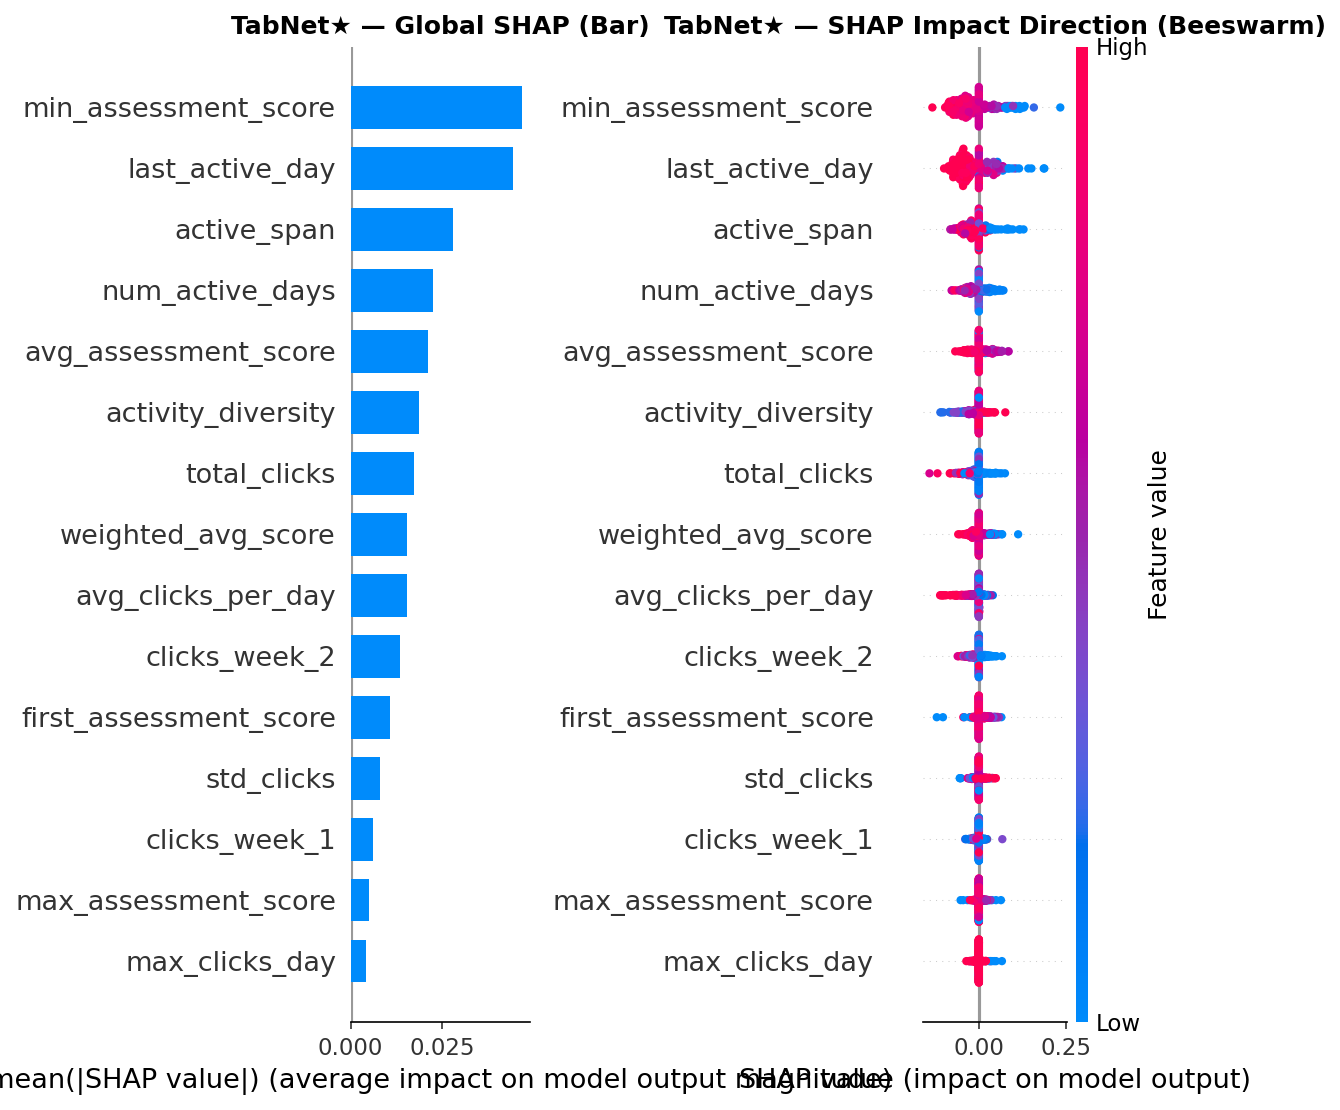

SHAP auto-selected: 8 features

Attention vs SHAP — Union: 10 | Both: 6


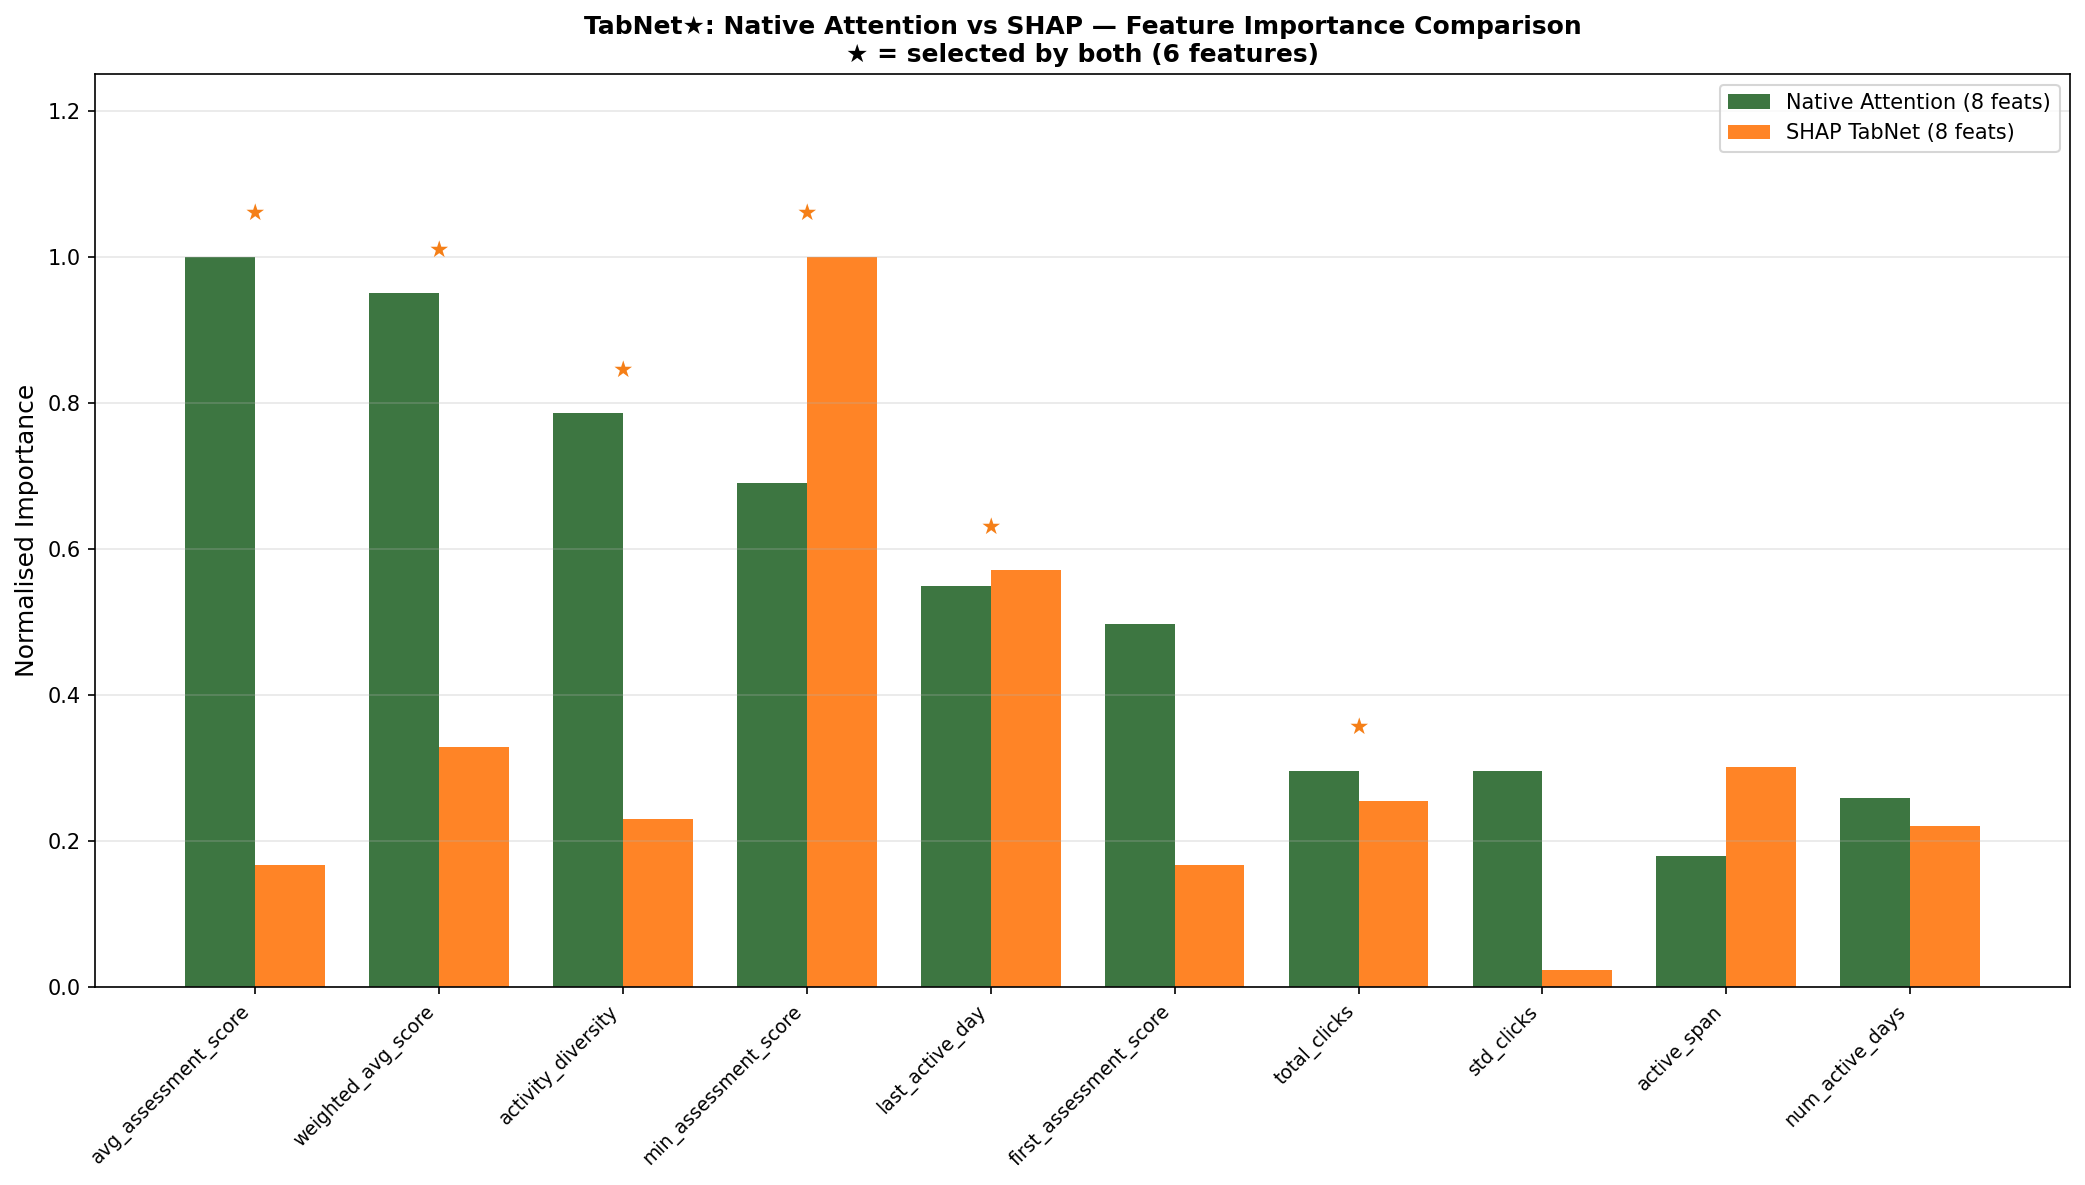

Attention vs SHAP comparison saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12 — SHAP ANALYSIS (KernelExplainer)
# ════════════════════════════════════════════════════════════════════════════
shap.initjs()

X_tr_p = X_train_np
X_te_p = X_test_np

def safe_kernel_shap(raw, n_features):
    arr=np.array(raw,dtype=float)
    if arr.ndim==3:   return arr[1]
    if arr.ndim==2:
        if arr.shape[1]==n_features: return arr
        if arr.shape[0]==n_features: return arr.T
    if arr.ndim==1 and arr.shape[0]==n_features: return arr.reshape(1,-1)
    raise ValueError(f'Unexpected shape: {arr.shape}')

print('Computing SHAP (KernelExplainer) for TabNet …')
bg_tn  = shap.sample(X_tr_p, 100, random_state=SEED)
se_tn  = shap.KernelExplainer(lambda x: tabnet.predict_proba(x.astype(np.float32))[:,1], bg_tn)

sv_raw = se_tn.shap_values(X_te_p, nsamples=100)
sv_tn  = safe_kernel_shap(sv_raw, len(FEATURE_NAMES_SEL))
ev_tn  = float(se_tn.expected_value)
print(f'TabNet SHAP: shape={sv_tn.shape}  E[f(x)]={ev_tn:.4f}')


# ── XGBoost — TreeExplainer (comparison model) ───────────────────────────

print('  XGBoost SHAP (TreeExplainer) ...')
xgb_clf_tn   = xgb_model.named_steps['clf']
X_te_xgb_tn  = xgb_model.named_steps['scl'].transform(
                xgb_model.named_steps['imp'].transform(X_test_sel))
X_tr_xgb_tn  = xgb_model.named_steps['scl'].transform(
                xgb_model.named_steps['imp'].transform(X_train_sel))
se_xgb_tn    = shap.TreeExplainer(xgb_clf_tn, feature_perturbation='tree_path_dependent')
# tree_path_dependent avoids SHAP's categorical-split limitation for XGBoost;
# only model_output='raw' (log-odds) is supported. Feature RANKING is unaffected.
sv_xgb_tn    = se_xgb_tn.shap_values(X_te_xgb_tn)
ev_xgb_tn    = float(np.ravel(se_xgb_tn.expected_value)[-1])
print(f'  XGBoost SHAP: shape={sv_xgb_tn.shape}  E[f(x)]={ev_xgb_tn:.4f}')

# ── LR — KernelExplainer (comparison model) ──────────────────────────────
print('  LR SHAP (KernelExplainer) ...')
X_te_lr_tn  = X_test_np
bg_lr_tn    = shap.sample(X_tr_p, 100, random_state=SEED)
se_lr_tn    = shap.KernelExplainer(
    lambda x: lr_baseline.predict_proba(x.astype(np.float32))[:,1], bg_lr_tn)
sv_lr_tn_raw = se_lr_tn.shap_values(X_te_lr_tn, nsamples=100)
sv_lr_tn     = safe_kernel_shap(sv_lr_tn_raw, len(FEATURE_NAMES_SEL))
ev_lr_tn     = float(se_lr_tn.expected_value)
print(f'  LR SHAP: shape={sv_lr_tn.shape}  E[f(x)]={ev_lr_tn:.4f}')

# Global plots
fig,(a1,a2)=plt.subplots(1,2,figsize=(18,8))
plt.sca(a1)
shap.summary_plot(sv_tn[:300],X_te_p[:300],feature_names=FEATURE_NAMES_SEL,plot_type='bar',max_display=15,show=False)
a1.set_title('TabNet★ — Global SHAP (Bar)',fontweight='bold')
plt.sca(a2)
shap.summary_plot(sv_tn[:300],X_te_p[:300],feature_names=FEATURE_NAMES_SEL,plot_type='dot',max_display=15,show=False)
a2.set_title('TabNet★ — SHAP Impact Direction (Beeswarm)',fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_global_TabNet.png',dpi=300,bbox_inches='tight'); plt.show()

# Auto-threshold
shap_rank_tn     = pd.Series(np.abs(sv_tn).mean(0),    index=FEATURE_NAMES_SEL).sort_values(ascending=False)
shap_rank_xgb_tn = pd.Series(np.abs(sv_xgb_tn).mean(0),index=FEATURE_NAMES_SEL).sort_values(ascending=False)
shap_rank_lr_tn  = pd.Series(np.abs(sv_lr_tn).mean(0), index=FEATURE_NAMES_SEL).sort_values(ascending=False)
tn_shap_thresh= shap_rank_tn.mean()+shap_rank_tn.std()
auto_shap_tn  = shap_rank_tn[shap_rank_tn>=tn_shap_thresh]
if len(auto_shap_tn)<MIN_FEATURES: auto_shap_tn=shap_rank_tn.iloc[:MIN_FEATURES]
auto_shap_tn.to_csv(CSV_DIR/'shap_top_TabNet.csv',header=['SHAP_Importance'])
print(f'SHAP auto-selected: {len(auto_shap_tn)} features')

# ── Native Attention vs SHAP comparison ──────────────────────────────────────

union_tn  = list(dict.fromkeys(list(auto_tn_fi.index)+list(auto_shap_tn.index)))
both_tn   = [f for f in union_tn if f in auto_tn_fi.index and f in auto_shap_tn.index]
print(f'\nAttention vs SHAP — Union: {len(union_tn)} | Both: {len(both_tn)}')

def norm_s(s): return (s-s.min())/(s.max()-s.min()+1e-9)
fig,ax=plt.subplots(figsize=(max(14,len(union_tn)),8))
x=np.arange(len(union_tn)); w=0.38
attn_vals=norm_s(tn_fi).reindex(union_tn).fillna(0).tolist()
shap_vals=norm_s(shap_rank_tn).reindex(union_tn).fillna(0).tolist()
ax.bar(x-w/2,attn_vals,w,color=PRIMARY_COLOR,alpha=0.85,label=f'Native Attention ({len(auto_tn_fi)} feats)')
ax.bar(x+w/2,shap_vals,w,color='#FF6F00',alpha=0.85,label=f'SHAP TabNet ({len(auto_shap_tn)} feats)')
for j,f in enumerate(union_tn):
    if f in both_tn:
        ax.text(x[j],max(attn_vals[j],shap_vals[j])+0.05,'★',ha='center',fontsize=11,color='#F57F17',fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f[:22] for f in union_tn],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised Importance',fontsize=12); ax.set_ylim(0,1.25); ax.grid(axis='y',alpha=0.3)
ax.set_title(f'TabNet★: Native Attention vs SHAP — Feature Importance Comparison\n★ = selected by both ({len(both_tn)} features)',
             fontsize=12,fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig(FIGURES_DIR/'attention_vs_shap_TabNet.png',dpi=150,bbox_inches='tight'); plt.show()
print('Attention vs SHAP comparison saved.')


TabNet — TP=3731  TN=4325  FP=1132  FN=2072
Cases: 10
Generating waterfall plots …


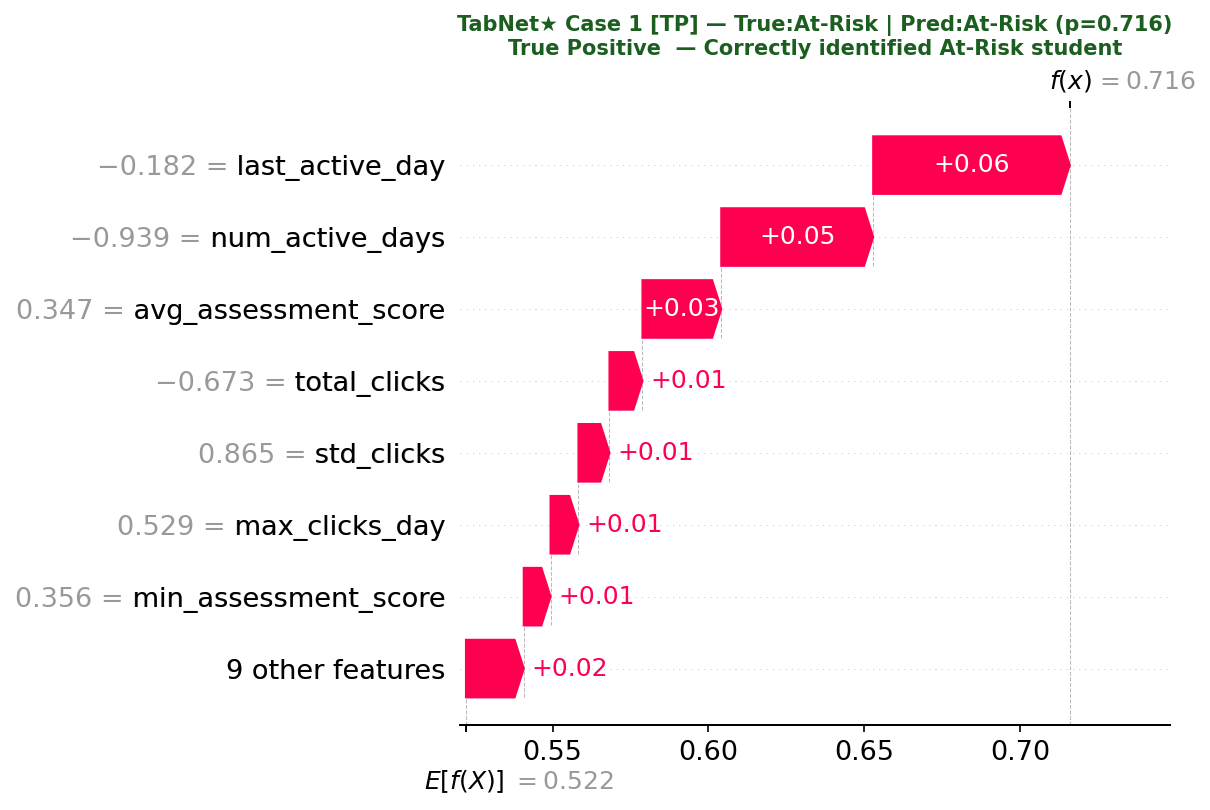

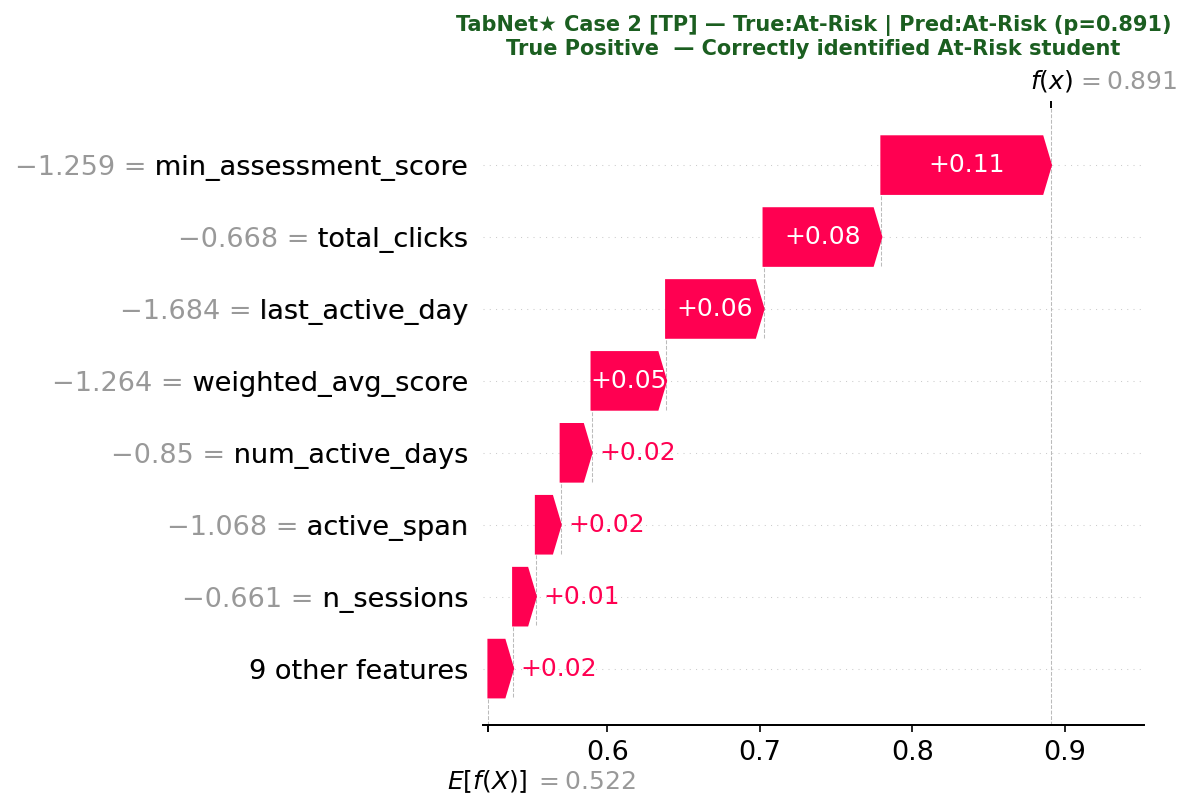

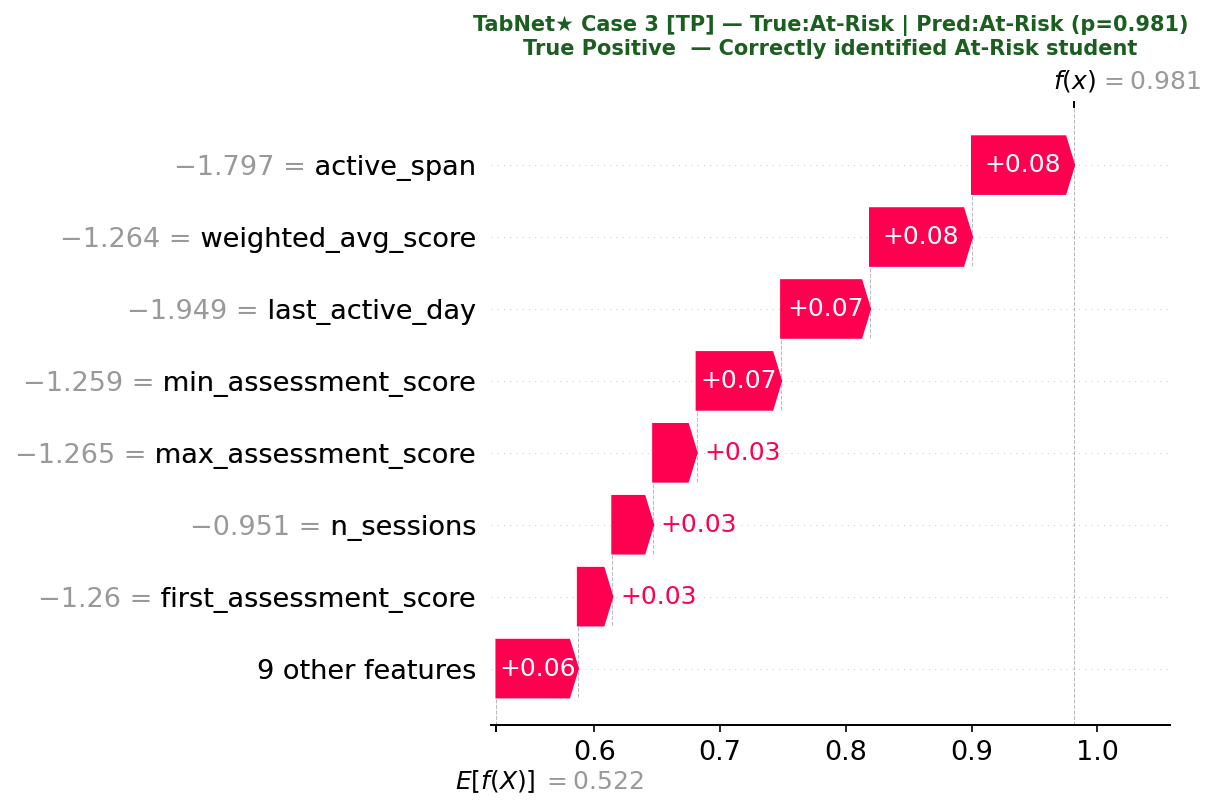

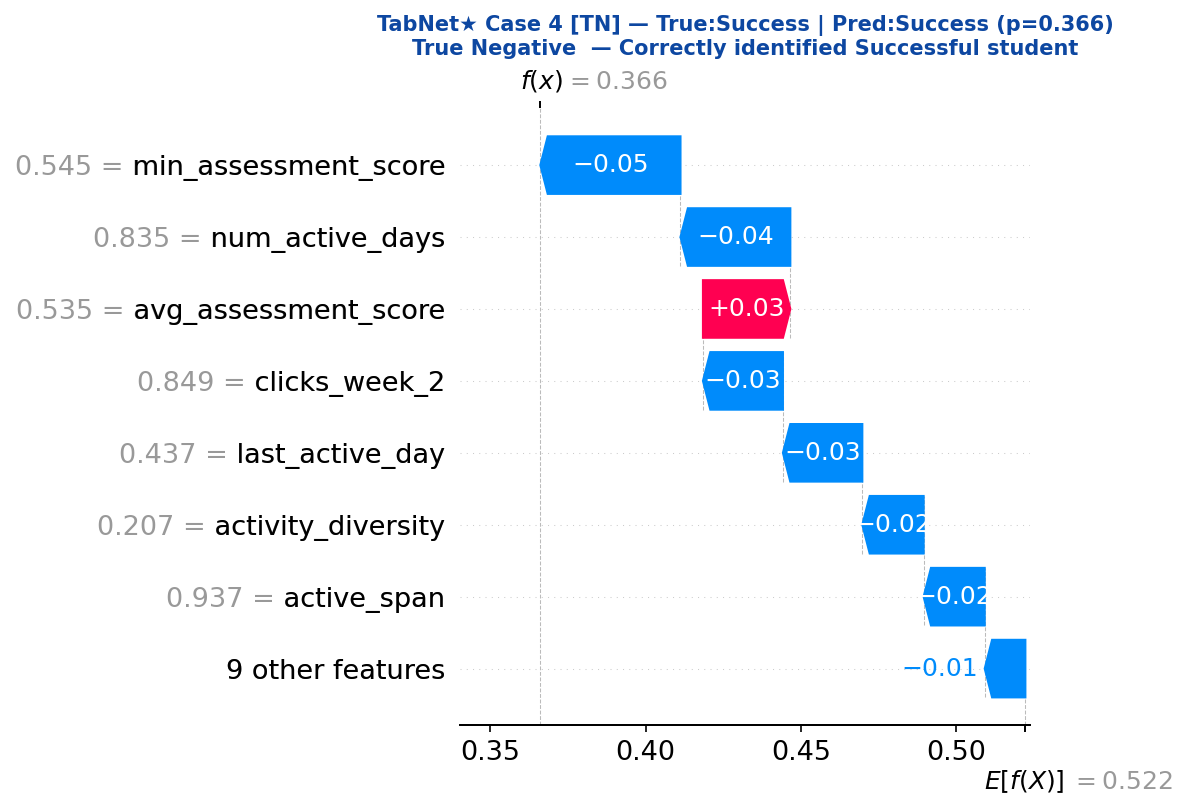

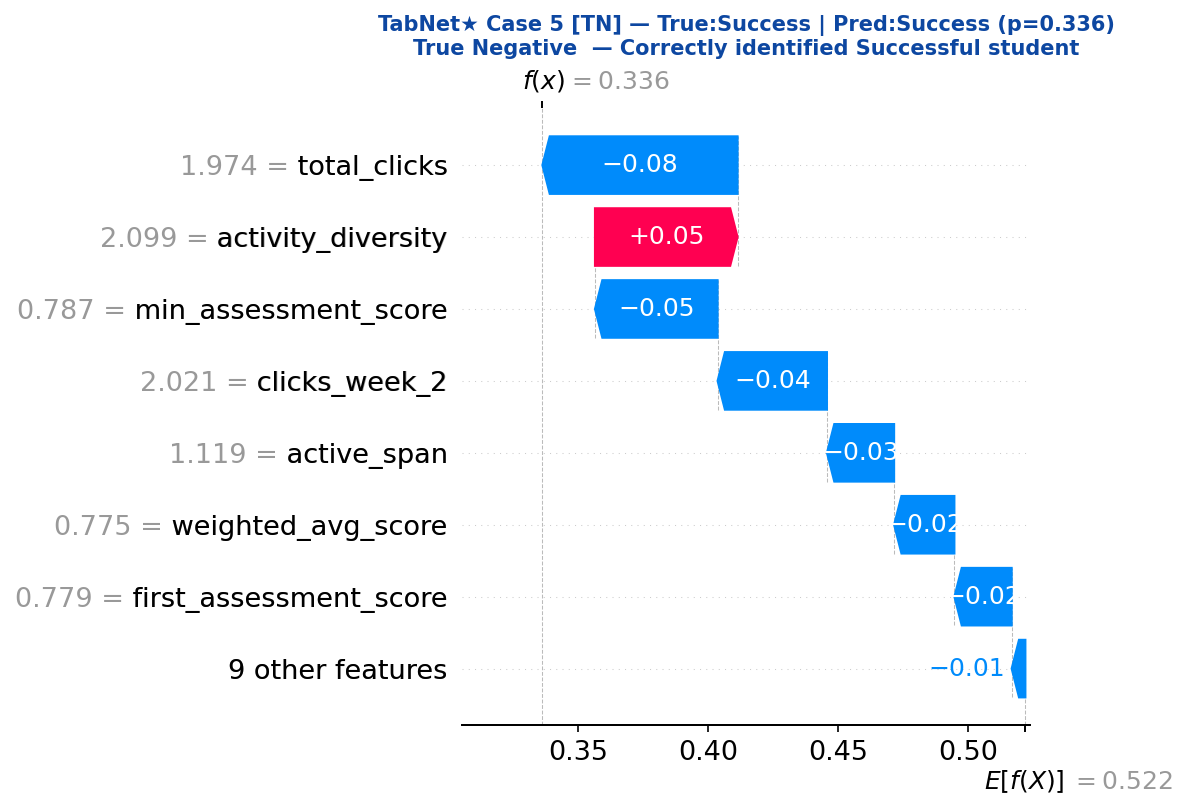

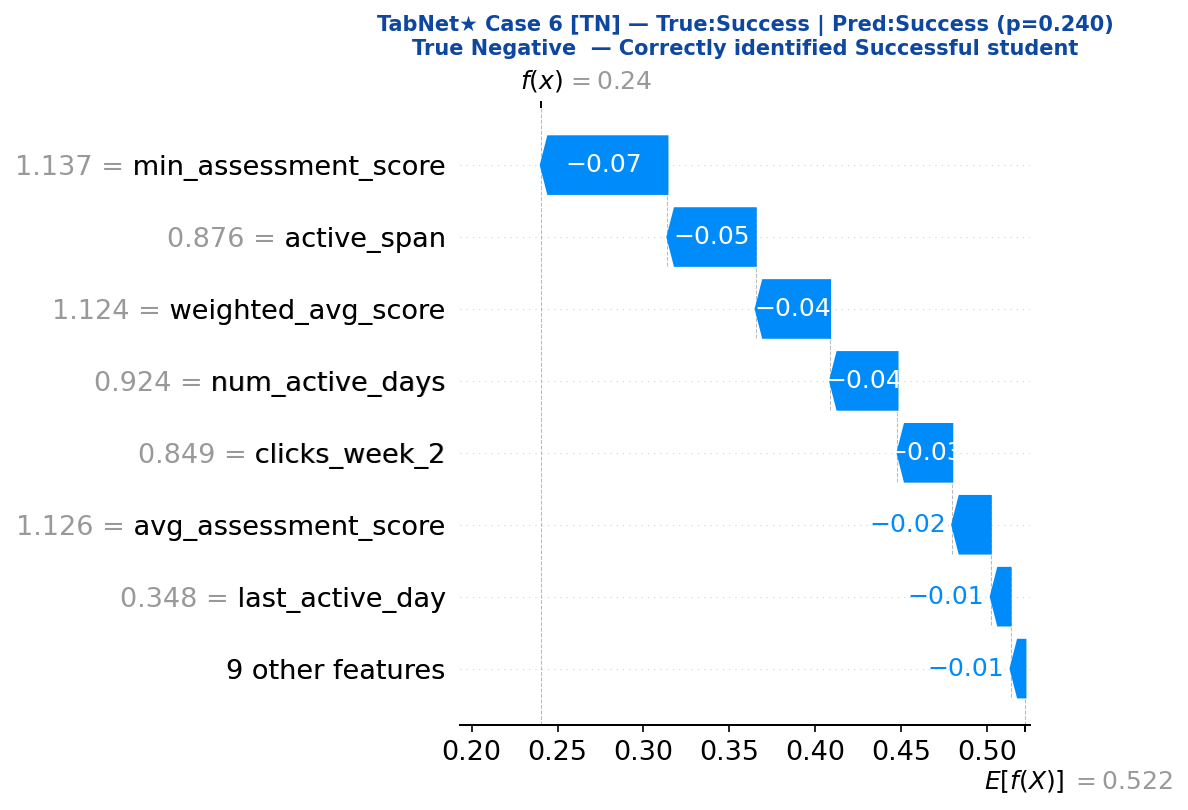

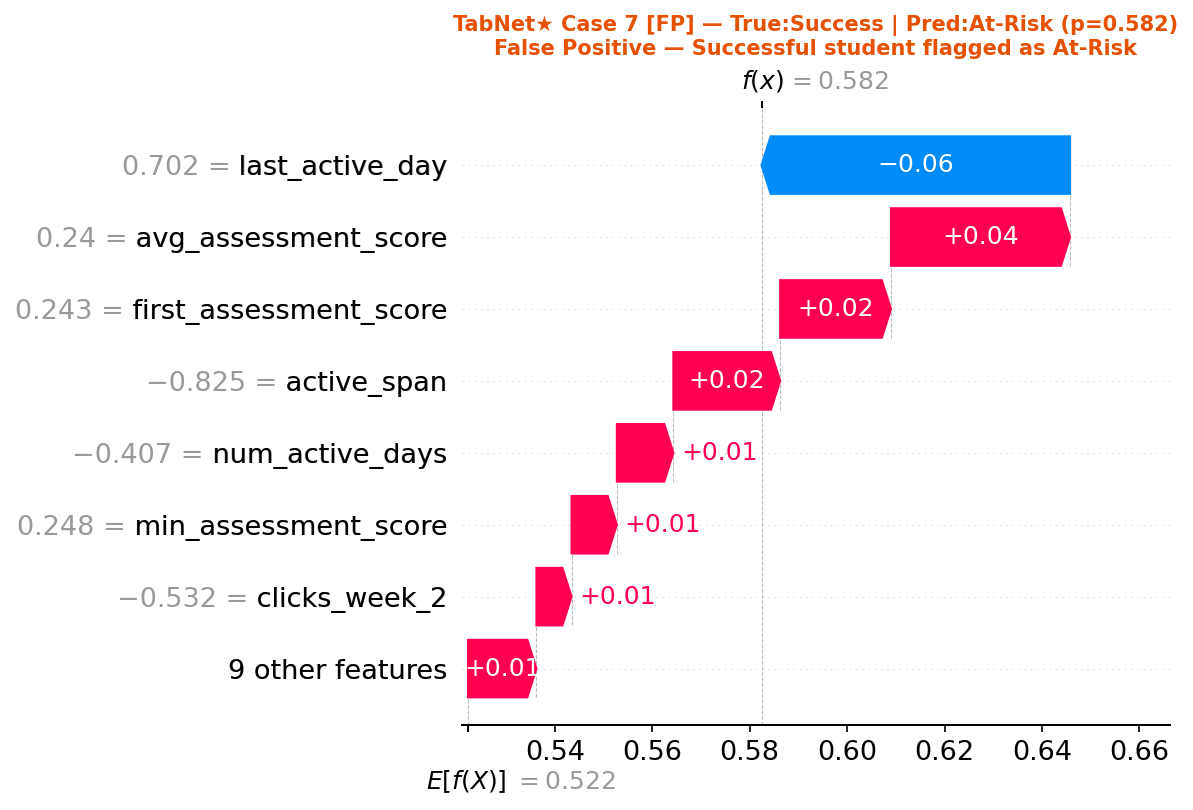

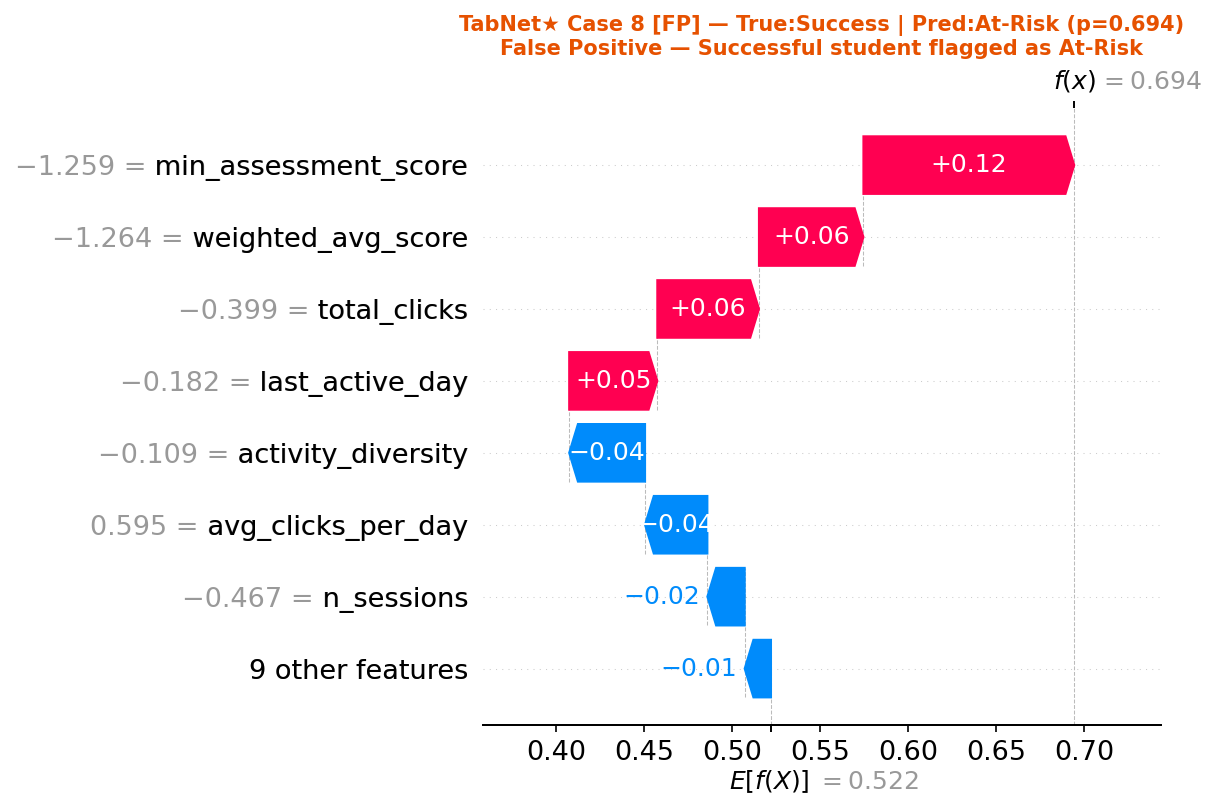

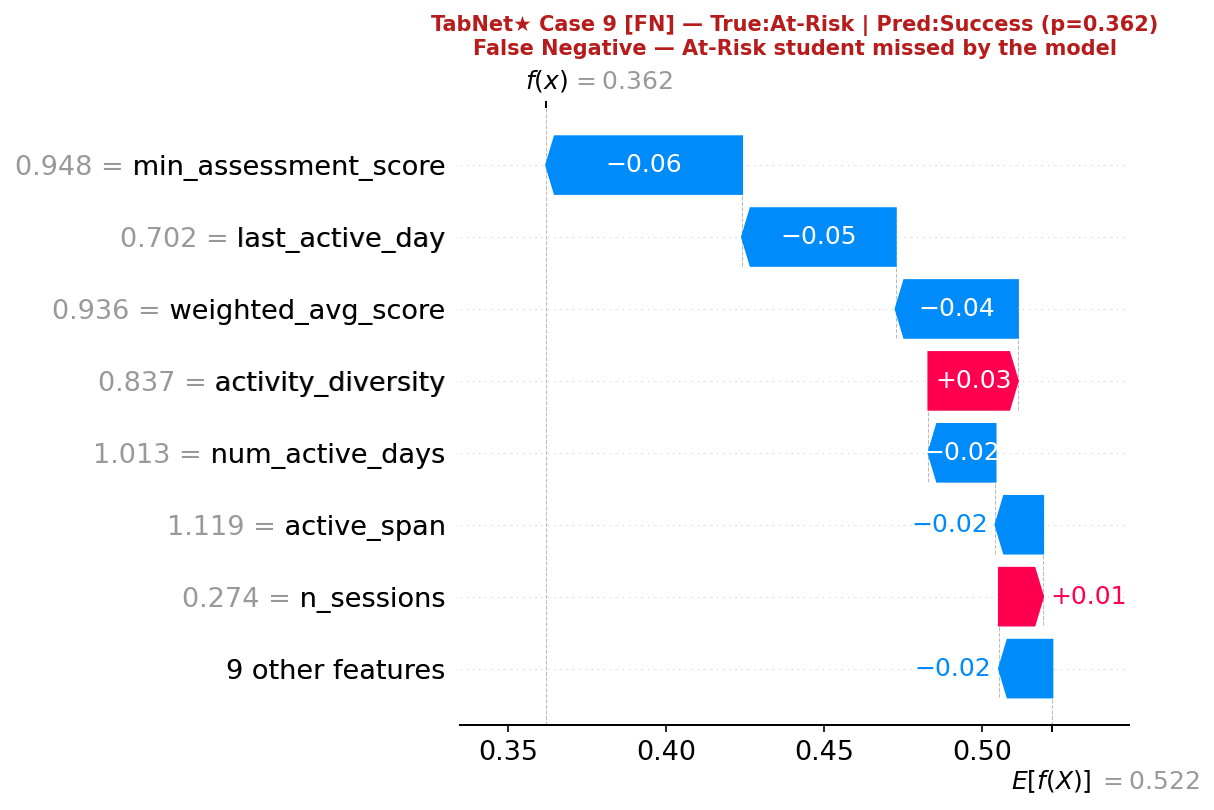

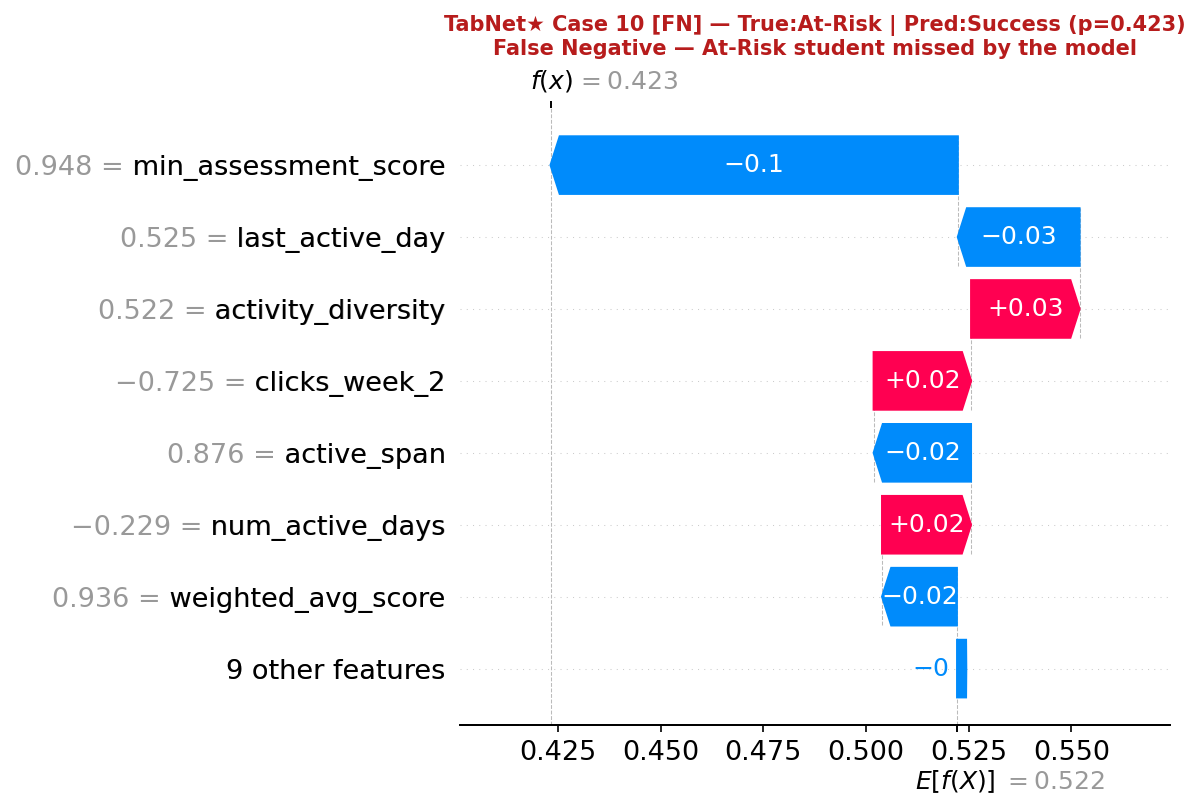

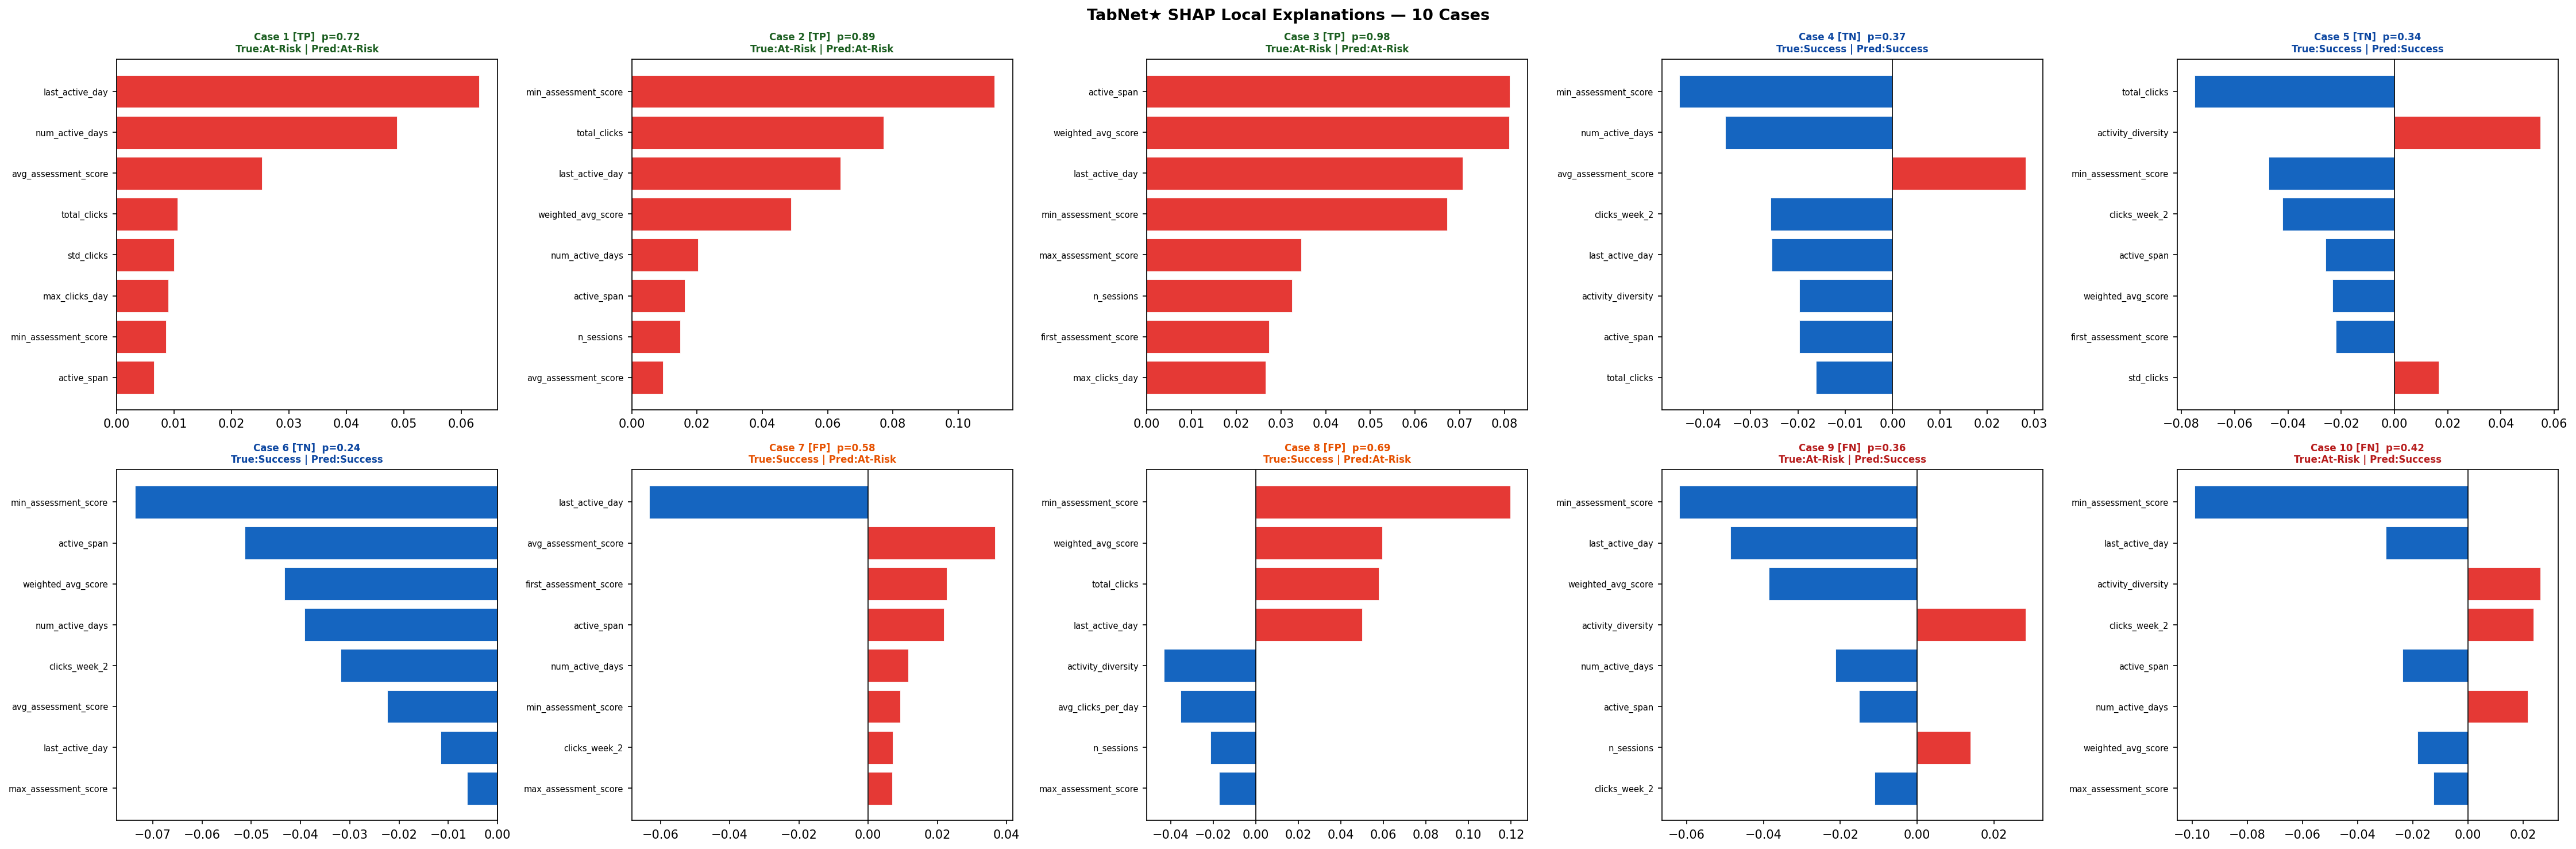

SHAP local done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 13 — SHAP LOCAL EXPLANATIONS (10 cases: TP/TN/FP/FN)
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(SEED)
# Apply DEFAULT threshold (0.50) for case selection (TP/TN/FP/FN)
# Using 0.5 instead of Youden's J to avoid missing at-risk students (conservative EWS policy)

y_pred_tn_opt = (y_prob_tn >= 0.5).astype(int)  # Default threshold (0.5) — conservative for EWS
tp_idx=np.where((y_test_arr==1)&(y_pred_tn_opt==1))[0]
tn_idx=np.where((y_test_arr==0)&(y_pred_tn_opt==0))[0]
fp_idx=np.where((y_test_arr==0)&(y_pred_tn_opt==1))[0]
fn_idx=np.where((y_test_arr==1)&(y_pred_tn_opt==0))[0]
print(f'TabNet — TP={len(tp_idx)}  TN={len(tn_idx)}  FP={len(fp_idx)}  FN={len(fn_idx)}')

def stratified_pick(idx_arr,n,probs,seed_offset=0):
    np.random.seed(SEED+seed_offset)
    if len(idx_arr)==0: return []
    if len(idx_arr)<=n: return list(idx_arr)
    order=np.argsort(probs[idx_arr]); bands=np.array_split(order,n)
    return [idx_arr[np.random.choice(b)] for b in bands]

picked_tp=stratified_pick(tp_idx,3,y_prob_tn,0)
picked_tn=stratified_pick(tn_idx,3,1-y_prob_tn,1)
picked_fp=stratified_pick(fp_idx,2,y_prob_tn,2)
picked_fn=stratified_pick(fn_idx,2,y_prob_tn,3)
local_idx=picked_tp+picked_tn+picked_fp+picked_fn
case_types=(['TP']*len(picked_tp)+['TN']*len(picked_tn)+
             ['FP']*len(picked_fp)+['FN']*len(picked_fn))
print(f'Cases: {len(local_idx)}')

type_color={'TP':'#1B5E20','TN':'#0D47A1','FP':'#E65100','FN':'#B71C1C'}
type_label={'TP':'True Positive  — Correctly identified At-Risk student',
            'TN':'True Negative  — Correctly identified Successful student',
            'FP':'False Positive — Successful student flagged as At-Risk',
            'FN':'False Negative — At-Risk student missed by the model'}


shap_exp_tn=shap.Explanation(
    values=sv_tn,
    base_values=np.full(len(sv_tn),ev_tn),
    data=X_te_p, feature_names=FEATURE_NAMES_SEL)

print('Generating waterfall plots …')
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    tl='At-Risk' if y_test_arr[idx]==1 else 'Success'
    pl='At-Risk' if y_pred_tn_opt[idx]==1 else 'Success'
    plt.figure(figsize=(11,6))
    shap.plots.waterfall(shap_exp_tn[idx],max_display=8,show=False)
    plt.title(f'TabNet★ Case {i+1} [{ctype}] — True:{tl} | Pred:{pl} (p={y_prob_tn[idx]:.3f})\n{type_label[ctype]}',
              fontsize=10,fontweight='bold',color=type_color[ctype])
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'shap_local_tn_case_{i+1}_{ctype}.png',dpi=300,bbox_inches='tight')
    plt.show(); plt.close()

fig,axes=plt.subplots(2,5,figsize=(30,10)); axes=axes.flatten()
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    sv_i=sv_tn[idx]
    top8=np.argsort(np.abs(sv_i))[-8:]
    axes[i].barh([FEATURE_NAMES_SEL[j][:22] for j in top8],[sv_i[j] for j in top8],
                 color=['#E53935' if v>0 else '#1565C0' for v in [sv_i[j] for j in top8]],
                 edgecolor='white',linewidth=0.4)
    axes[i].axvline(0,color='black',lw=0.8)
    axes[i].set_title(f'Case {i+1} [{ctype}]  p={y_prob_tn[idx]:.2f}\n'
                      f'True:{"At-Risk" if y_test_arr[idx]==1 else "Success"} | '
                      f'Pred:{"At-Risk" if y_pred_tn_opt[idx]==1 else "Success"}',
                      fontsize=8,fontweight='bold',color=type_color[ctype])
    axes[i].tick_params(axis='y',labelsize=7)
plt.suptitle('TabNet★ SHAP Local Explanations — 10 Cases',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_local_TabNet_10cases.png',dpi=150,bbox_inches='tight'); plt.show()
print('SHAP local done.')


SHAP Auto-Selected:
  TabNet★=8  XGBoost=8  LR=8

SHAP Consensus (≥2/3 models): 7 features
SHAP Union (all selected)    : 13 features


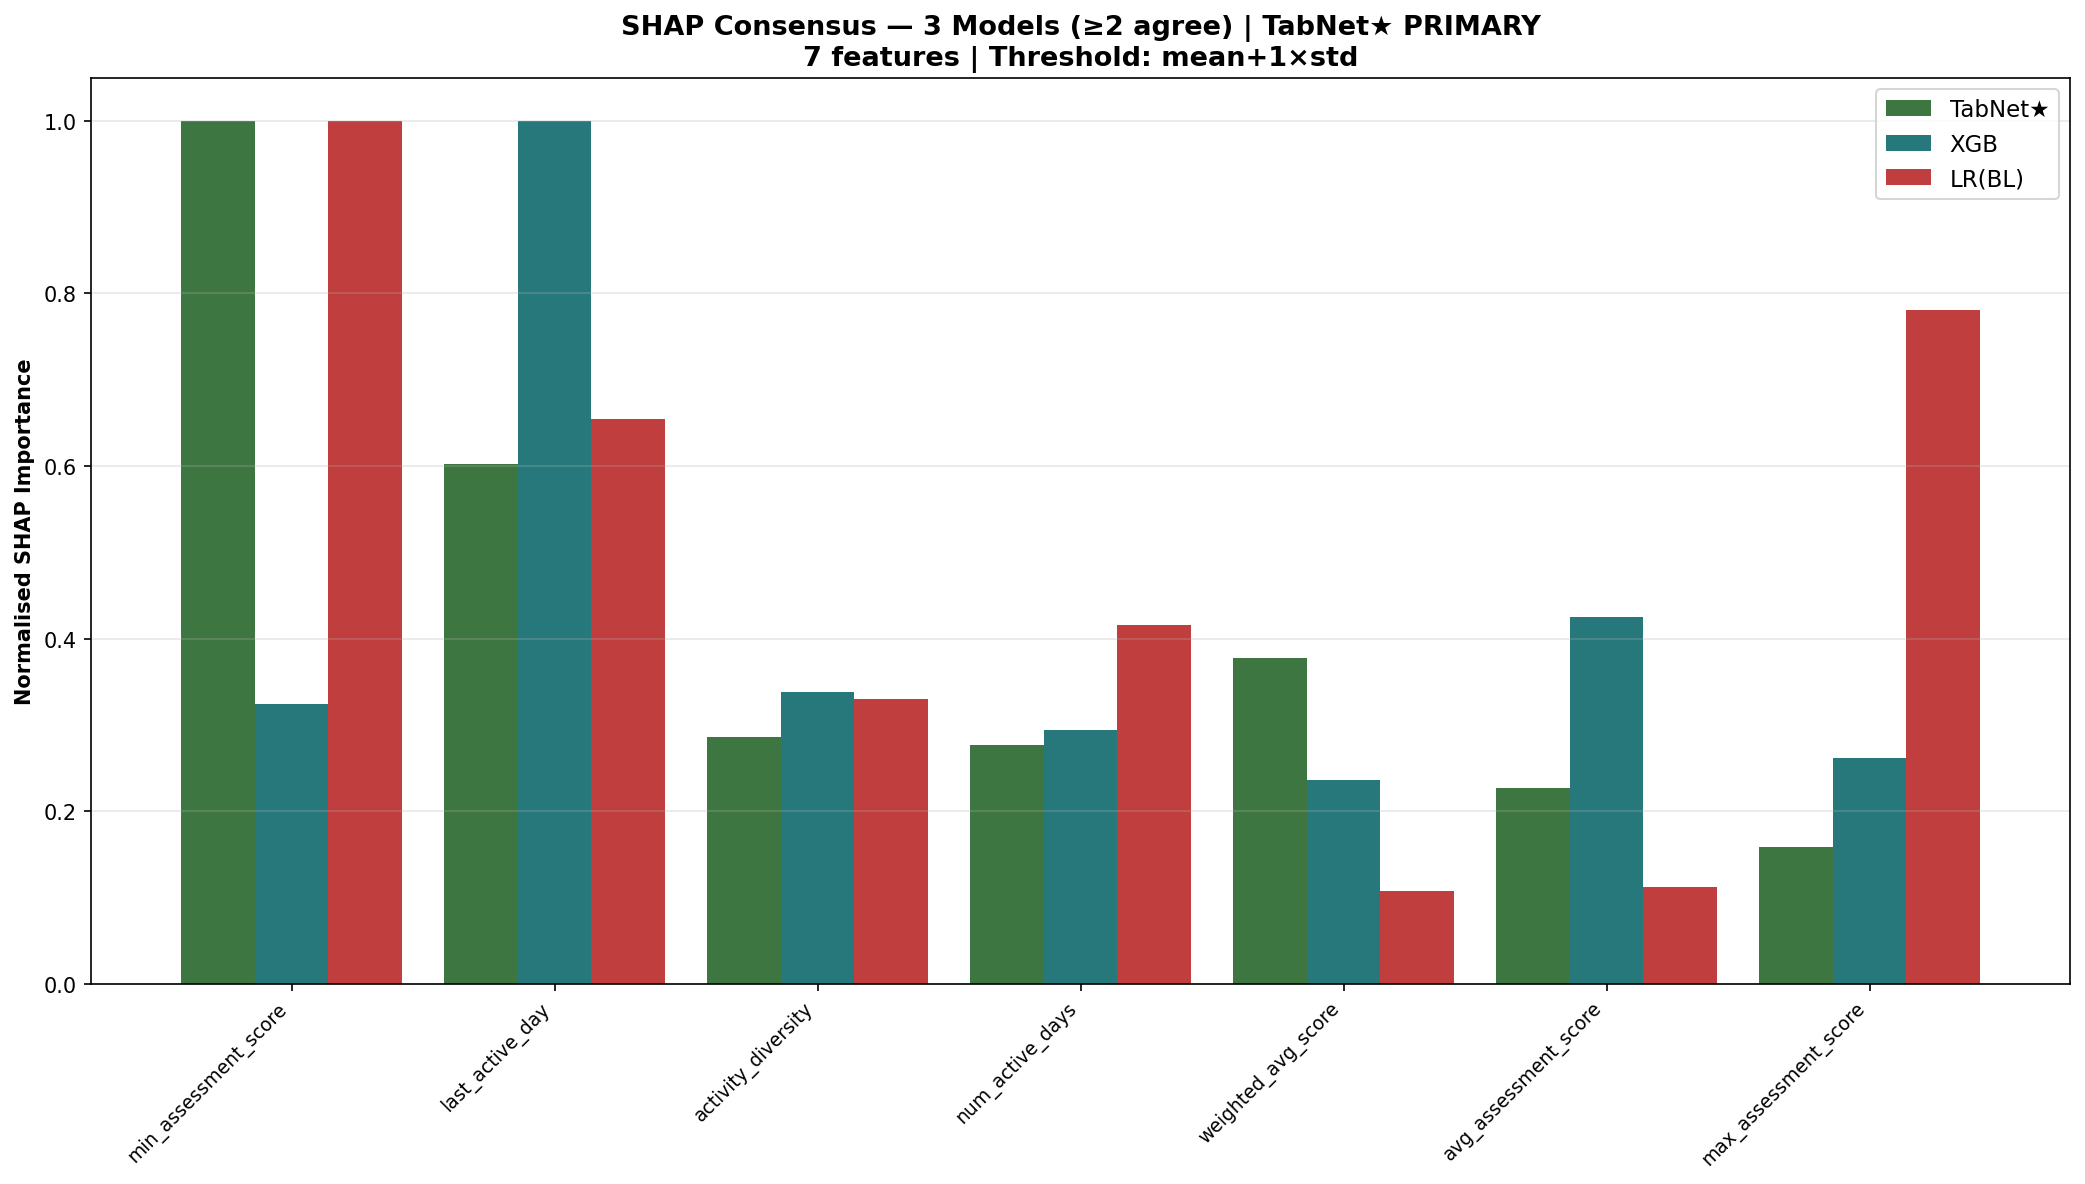

SHAP Consensus plot saved.


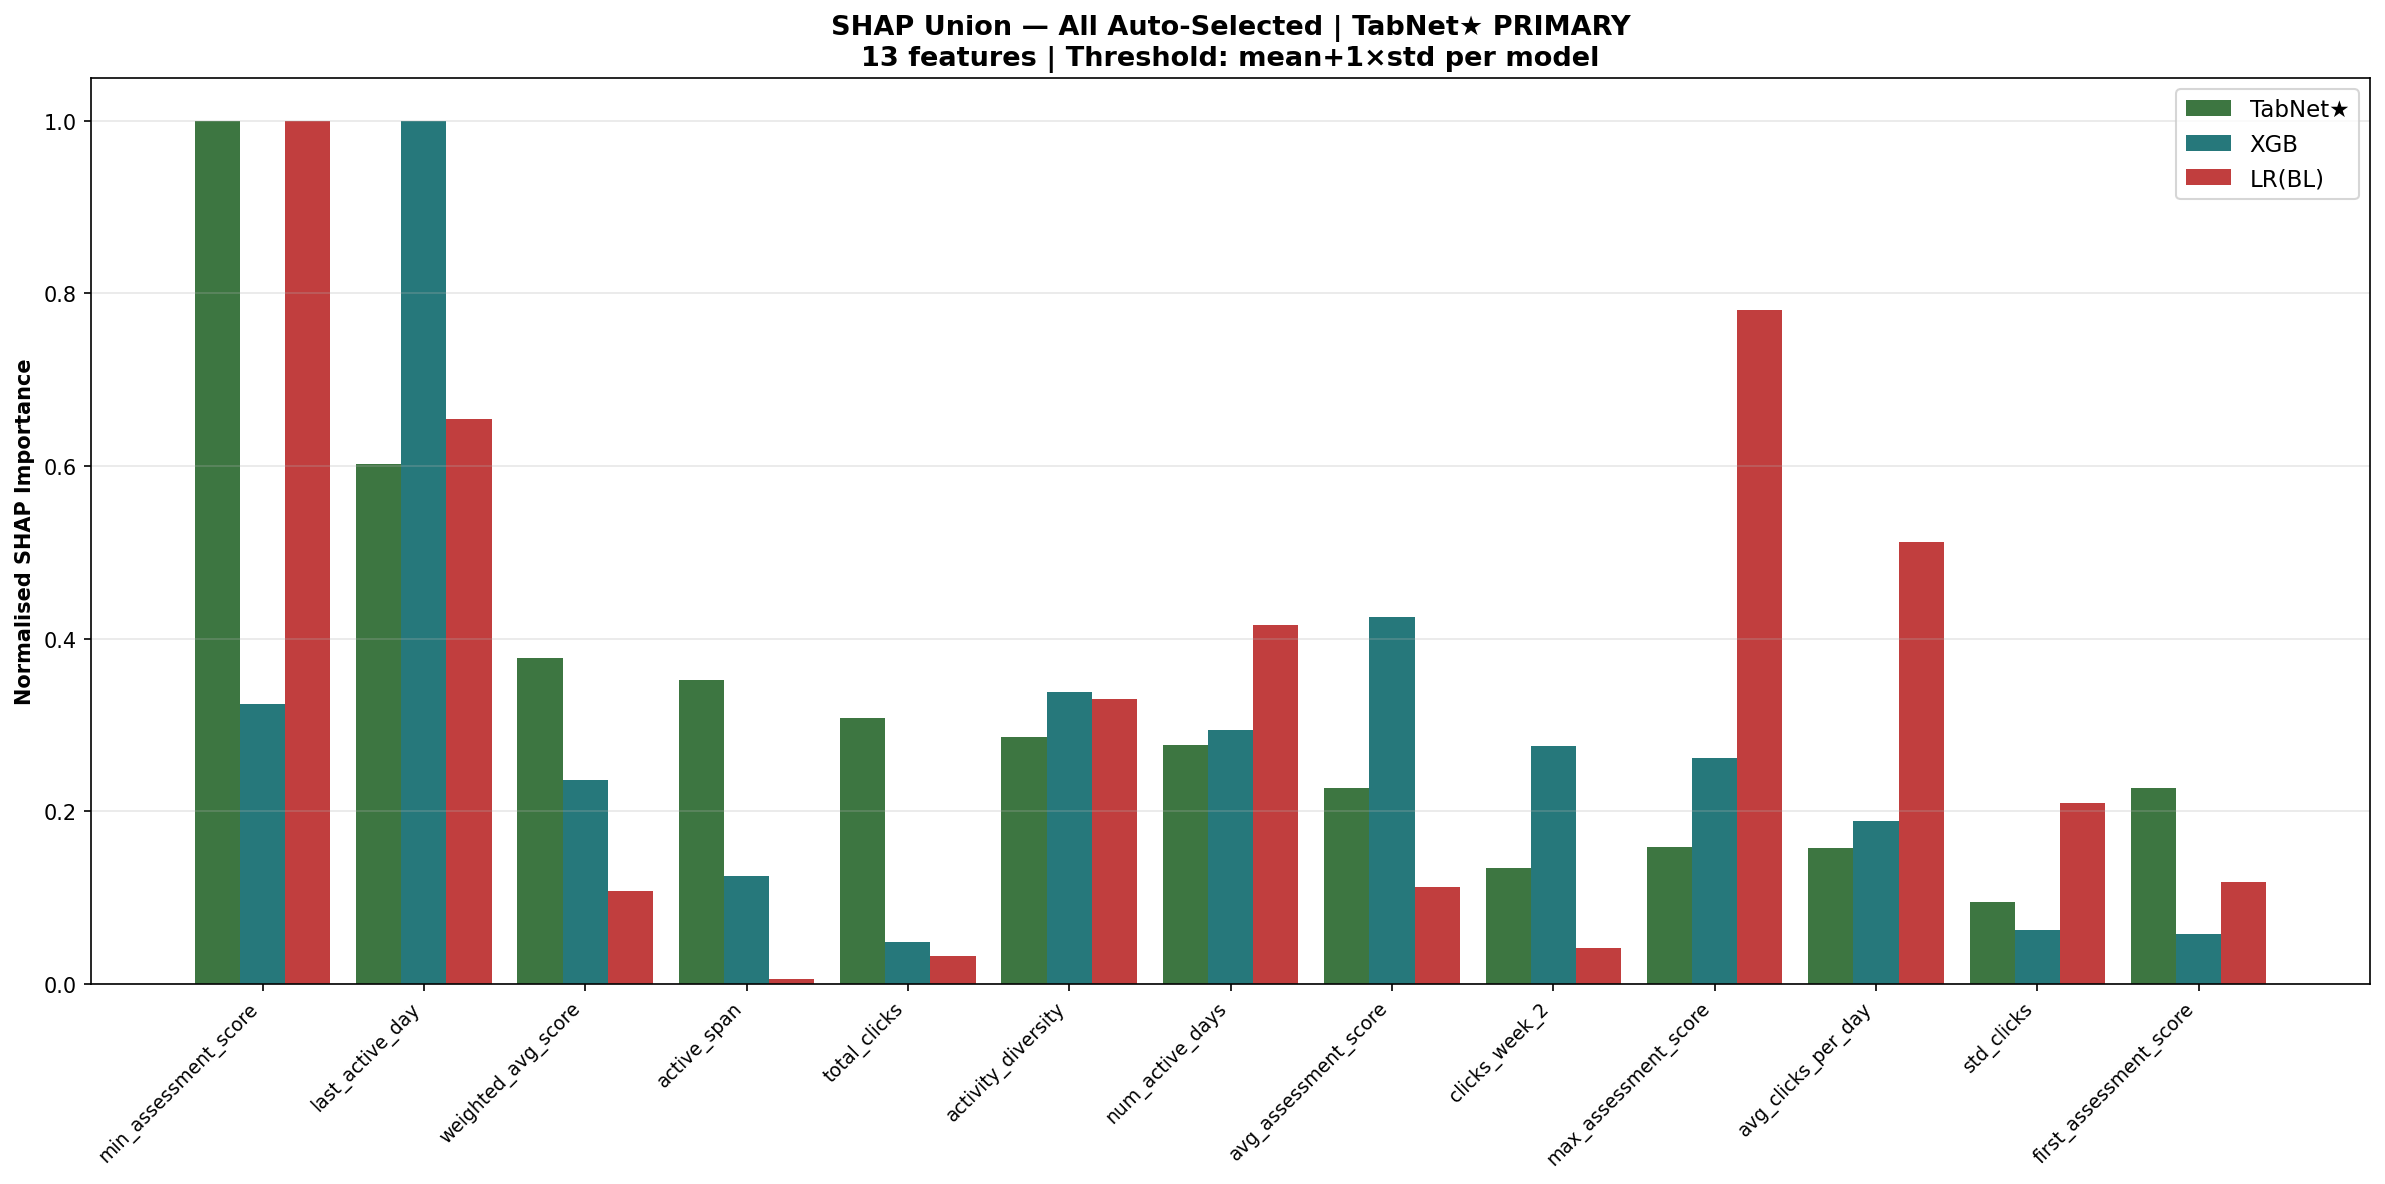

SHAP Union plot saved.


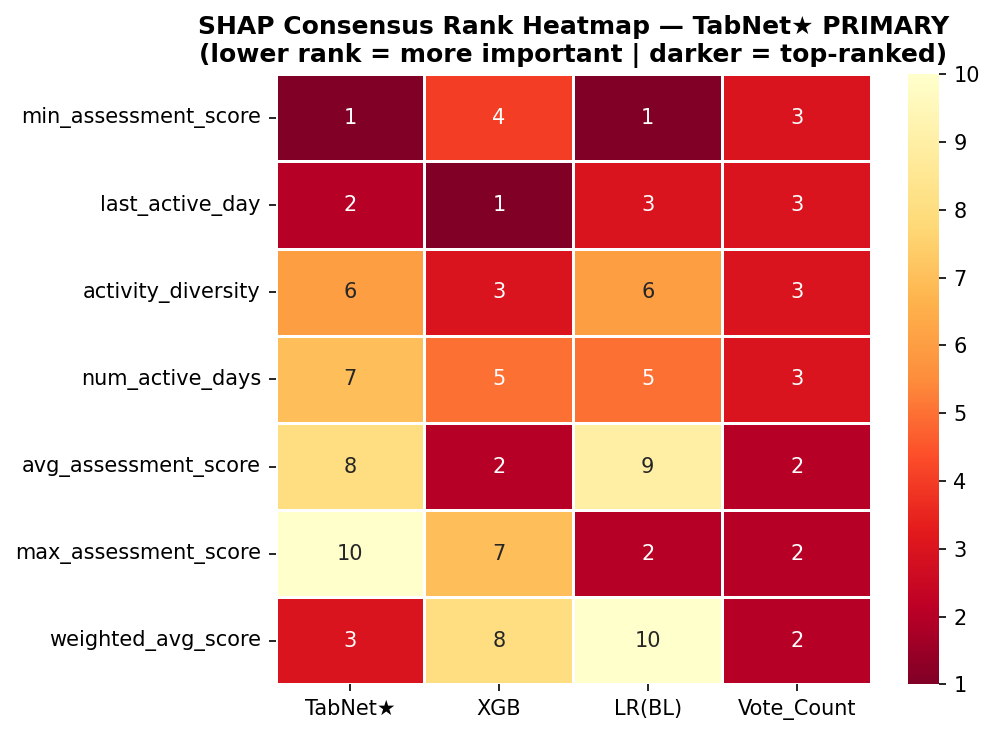

Heatmap saved.

SHAP Rankings complete — Consensus:7 | Union:13


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SHAP AUTO-SELECTED RANKINGS + CONSENSUS (TabNet★, XGBoost, LR)
# ════════════════════════════════════════════════════════════════════════════
from collections import Counter as _SCtr2

def _auto_shap_tn(s, min_f=MIN_FEATURES):
    sel = s[s >= s.mean()+s.std()]
    return sel if len(sel) >= min_f else s.iloc[:min_f]

# ── Auto-select per model ─────────────────────────────────────────────────
auto_shap_tn_r   = _auto_shap_tn(shap_rank_tn)
auto_shap_xgb_r  = _auto_shap_tn(shap_rank_xgb_tn)
auto_shap_lr_r   = _auto_shap_tn(shap_rank_lr_tn)

print(f'SHAP Auto-Selected:')
print(f'  TabNet★={len(auto_shap_tn_r)}  XGBoost={len(auto_shap_xgb_r)}  LR={len(auto_shap_lr_r)}')

for nm, s in [('tabnet',auto_shap_tn_r),('xgb',auto_shap_xgb_r),('lr',auto_shap_lr_r)]:
    s.to_csv(CSV_DIR/f'shap_top_{nm}_tn.csv', header=['SHAP_Importance'])

# ── Consensus ≥2 of 3 models ──────────────────────────────────────────────
all_sf = (list(auto_shap_tn_r.index)+list(auto_shap_xgb_r.index)+
          list(auto_shap_lr_r.index))
sv_cnt2 = _SCtr2(all_sf)
shap_consensus_tn = [f for f,c in sorted(sv_cnt2.items(),key=lambda x:-x[1]) if c>=2]
shap_union_tn     = list(dict.fromkeys(all_sf))

print(f'\nSHAP Consensus (≥2/3 models): {len(shap_consensus_tn)} features')
print(f'SHAP Union (all selected)    : {len(shap_union_tn)} features')

# ── model_ranks ───────────────────────────────────────────────────────────
shap_ranks_tn3 = [
    (shap_rank_tn,    'TabNet★', PRIMARY_COLOR),
    (shap_rank_xgb_tn,'XGB',    '#006064'),
    (shap_rank_lr_tn, 'LR(BL)', '#B71C1C'),
]
bw = 0.28

# ── Plot 1: Consensus ─────────────────────────────────────────────────────
if shap_consensus_tn:
    fig, ax = plt.subplots(figsize=(max(14,len(shap_consensus_tn)),8))
    x = np.arange(len(shap_consensus_tn))
    for ii,(rank,lb,col) in enumerate(shap_ranks_tn3):
        ax.bar(x+(ii-1)*bw,[rank.get(f,0)/(rank.max()+1e-9) for f in shap_consensus_tn],
               bw,label=lb,color=col,alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:22] for f in shap_consensus_tn],rotation=45,ha='right',fontsize=9)
    ax.set_ylabel('Normalised SHAP Importance',fontweight='bold')
    ax.set_title(f'SHAP Consensus — 3 Models (≥2 agree) | TabNet★ PRIMARY\n'
                 f'{len(shap_consensus_tn)} features | Threshold: mean+1×std',
                 fontsize=13,fontweight='bold')
    ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'shap_consensus_TabNet.png',dpi=150,bbox_inches='tight')
    plt.show(); print('SHAP Consensus plot saved.')

# ── Plot 2: Union ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16,len(shap_union_tn)),8))
x = np.arange(len(shap_union_tn))
for ii,(rank,lb,col) in enumerate(shap_ranks_tn3):
    ax.bar(x+(ii-1)*bw,[rank.get(f,0)/(rank.max()+1e-9) for f in shap_union_tn],
           bw,label=lb,color=col,alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f[:22] for f in shap_union_tn],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised SHAP Importance',fontweight='bold')
ax.set_title(f'SHAP Union — All Auto-Selected | TabNet★ PRIMARY\n'
             f'{len(shap_union_tn)} features | Threshold: mean+1×std per model',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'shap_union_TabNet.png',dpi=150,bbox_inches='tight')
plt.show(); print('SHAP Union plot saved.')

# ── Heatmap ───────────────────────────────────────────────────────────────
if shap_consensus_tn:
    rtbl_stn = pd.DataFrame({lb: s.rank(ascending=False).astype(int)
                              for s,lb,_ in shap_ranks_tn3},
                             index=FEATURE_NAMES_SEL).loc[shap_consensus_tn]
    rtbl_stn['Avg_Rank']   = rtbl_stn.mean(axis=1)
    rtbl_stn['Vote_Count'] = [sv_cnt2[f] for f in shap_consensus_tn]
    rtbl_stn = rtbl_stn.sort_values('Avg_Rank')
    rtbl_stn.to_csv(CSV_DIR/'shap_consensus_ranking_TabNet.csv')

    fig,ax = plt.subplots(figsize=(7,max(5,len(shap_consensus_tn)*0.5)))
    sns.heatmap(rtbl_stn[['TabNet★','XGB','LR(BL)','Vote_Count']],
                annot=True,fmt='.0f',cmap='YlOrRd_r',linewidths=0.5,ax=ax)
    ax.set_title('SHAP Consensus Rank Heatmap — TabNet★ PRIMARY\n'
                 '(lower rank = more important | darker = top-ranked)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'shap_rank_heatmap_TabNet.png',dpi=150,bbox_inches='tight')
    plt.show(); print('Heatmap saved.')

print(f'\nSHAP Rankings complete — Consensus:{len(shap_consensus_tn)} | Union:{len(shap_union_tn)}')


10 LIME explanations: 3.8s
Generating LIME local explanation plots (native LIME style) …


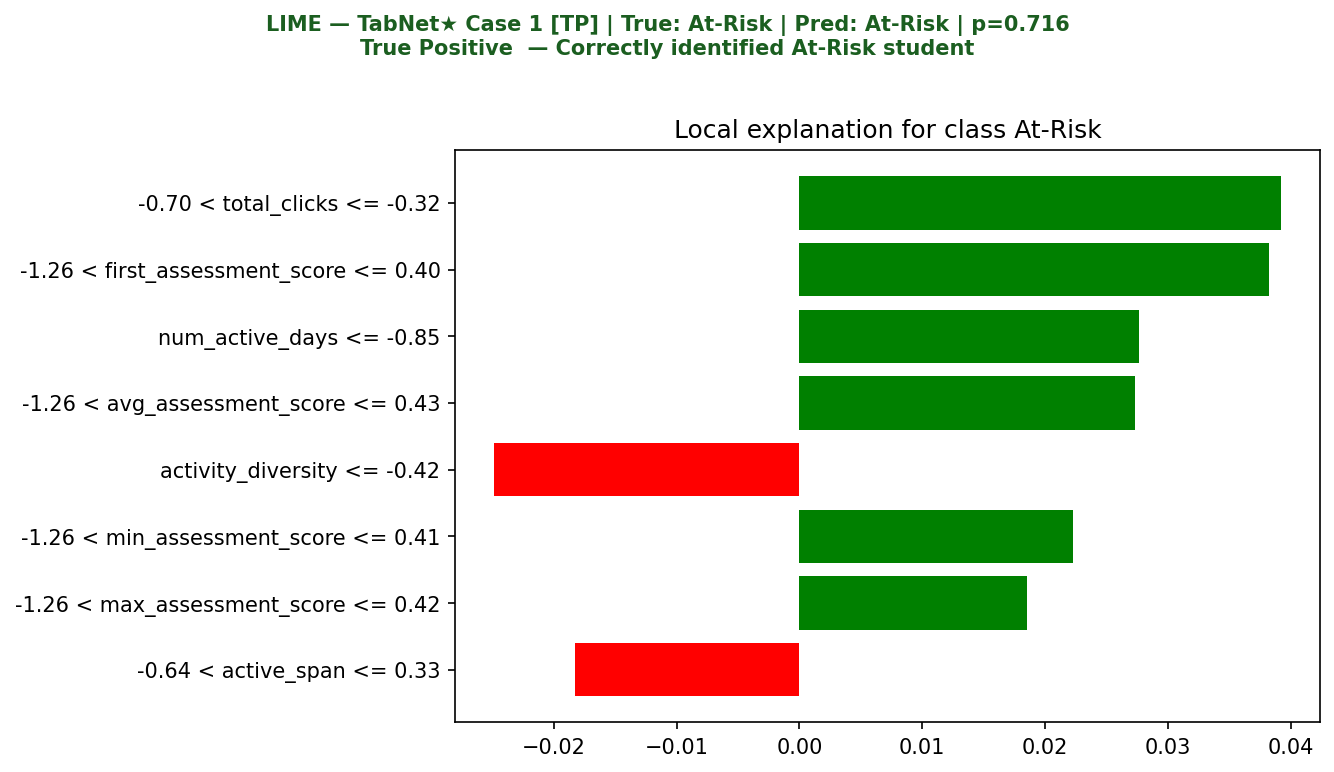

  Case 1 [TP] saved.


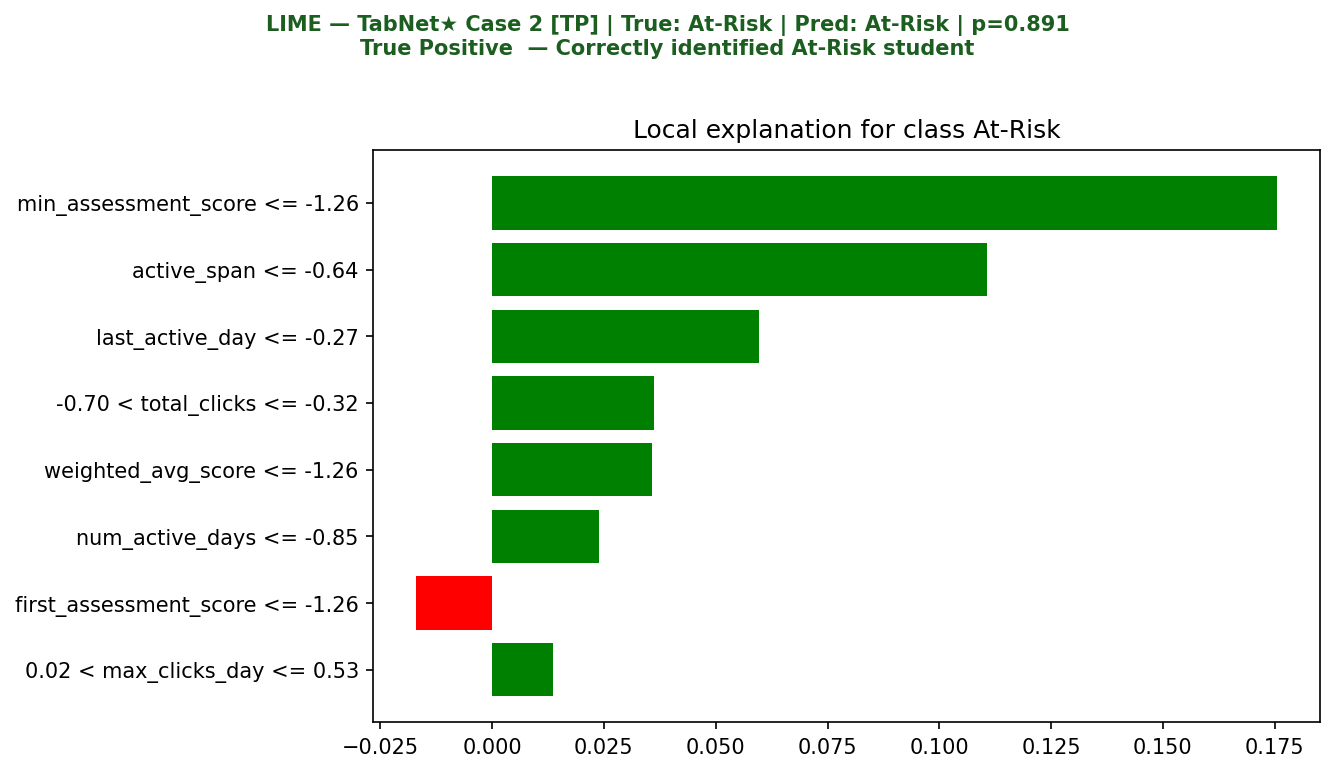

  Case 2 [TP] saved.


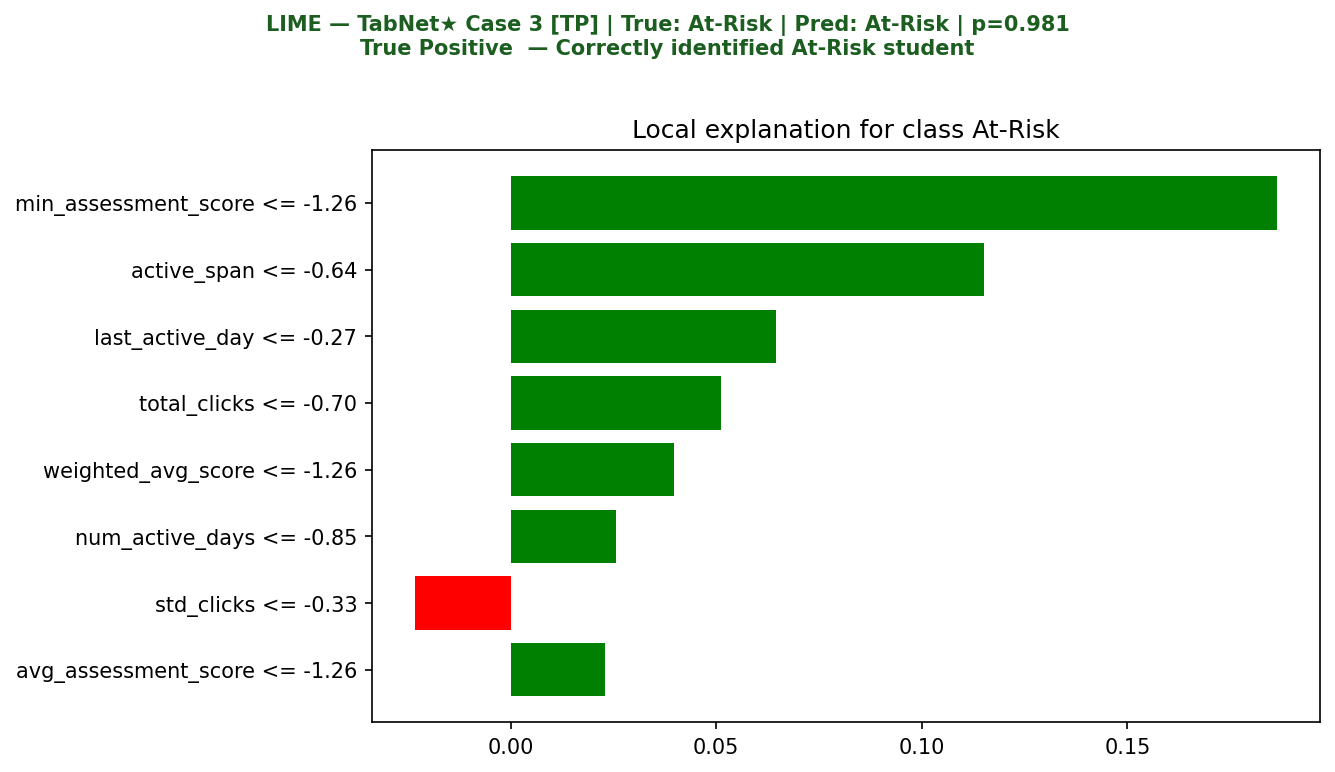

  Case 3 [TP] saved.


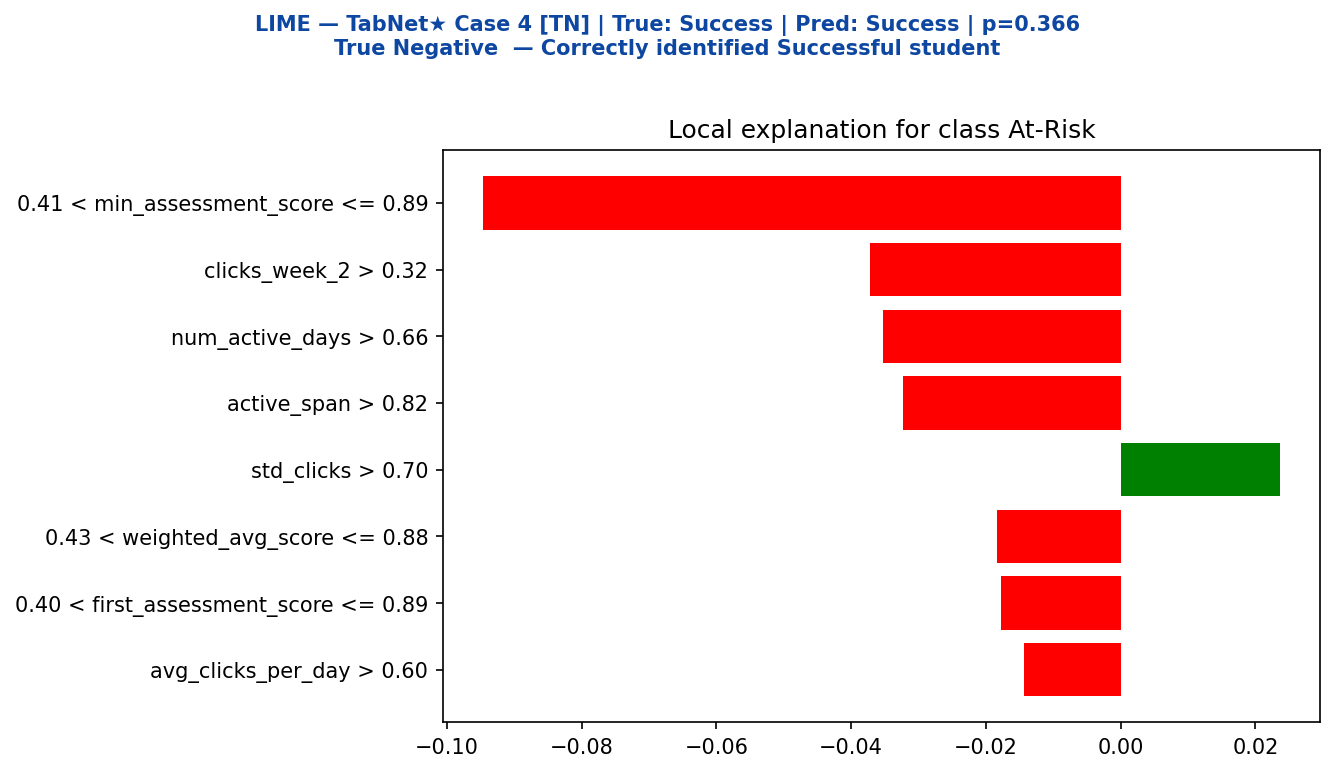

  Case 4 [TN] saved.


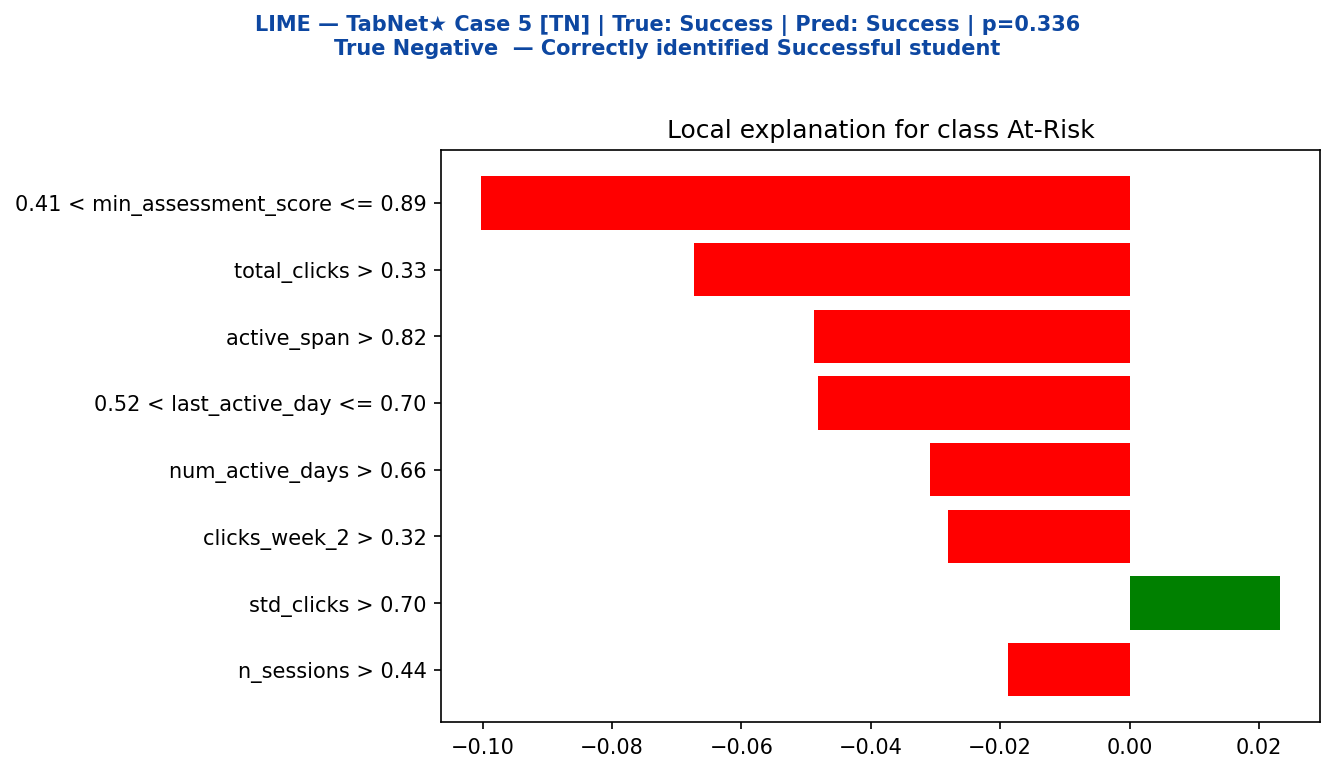

  Case 5 [TN] saved.


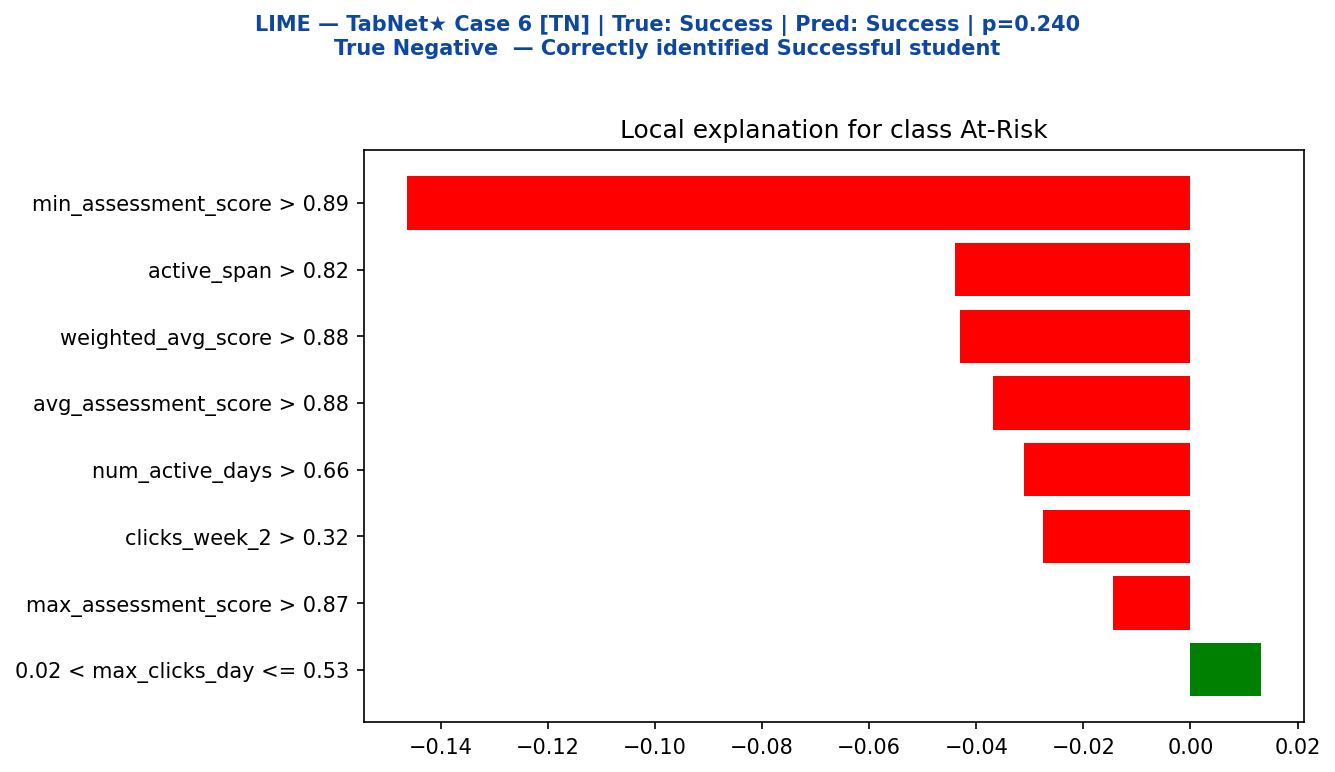

  Case 6 [TN] saved.


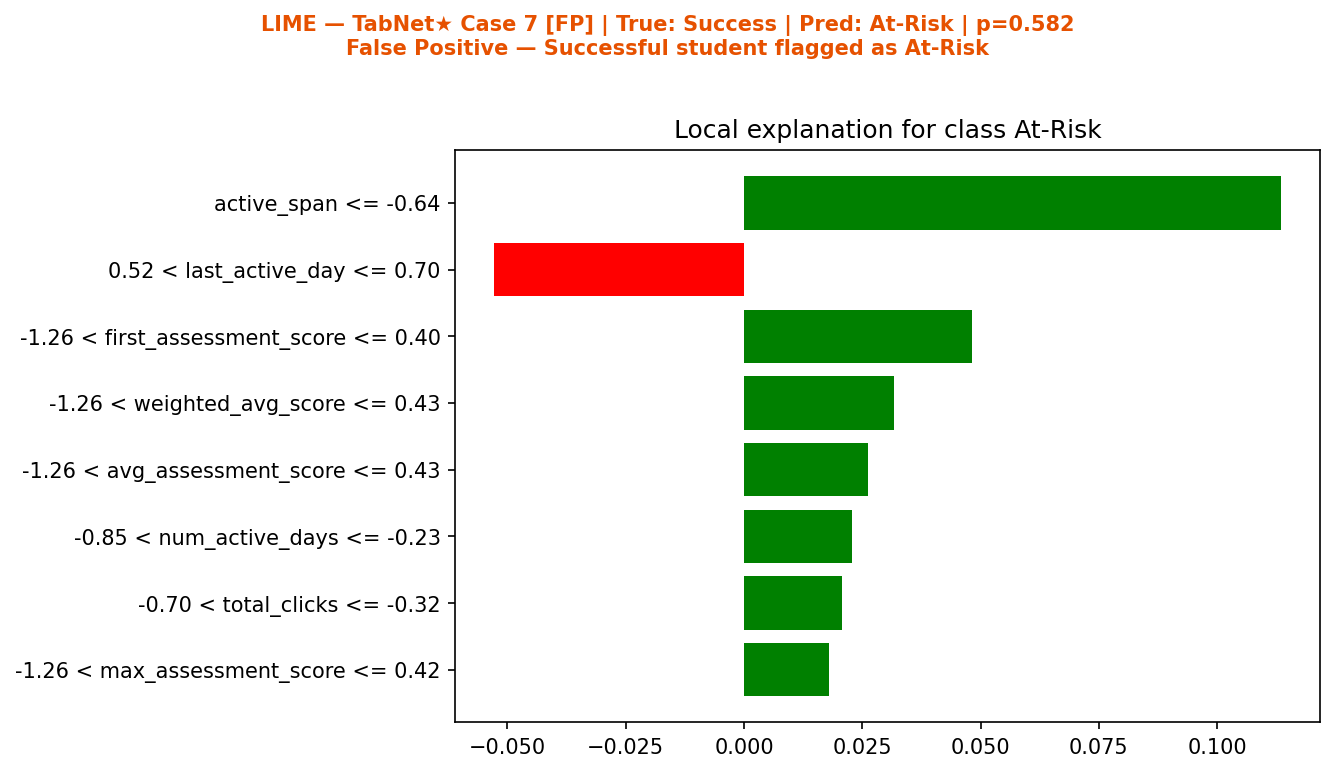

  Case 7 [FP] saved.


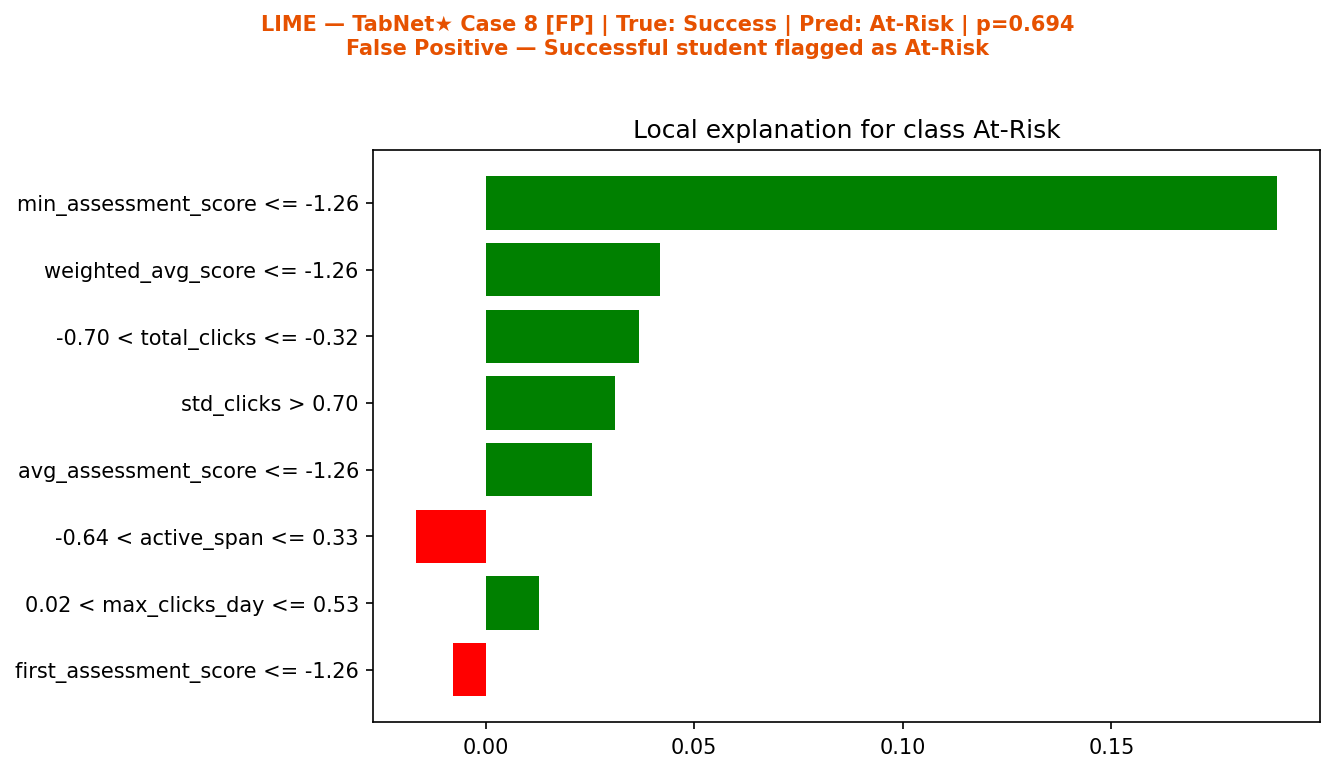

  Case 8 [FP] saved.


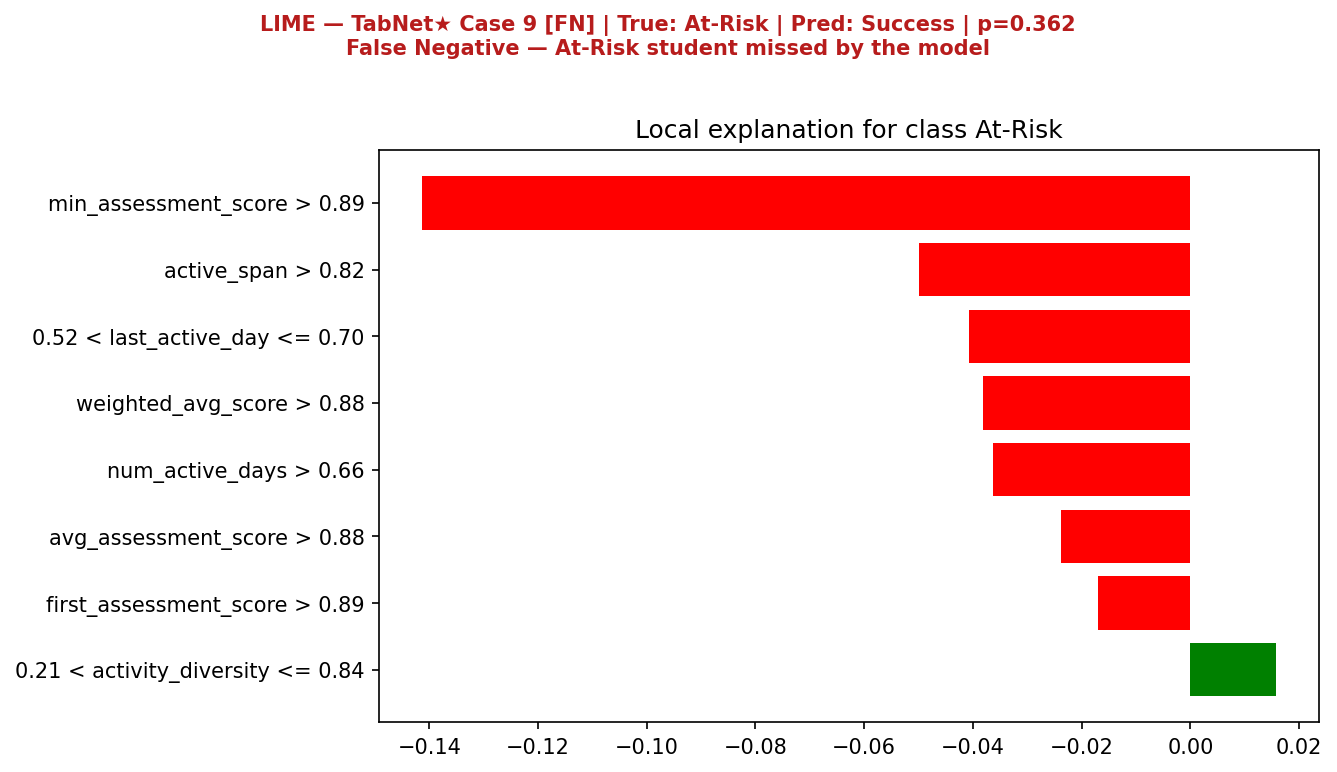

  Case 9 [FN] saved.


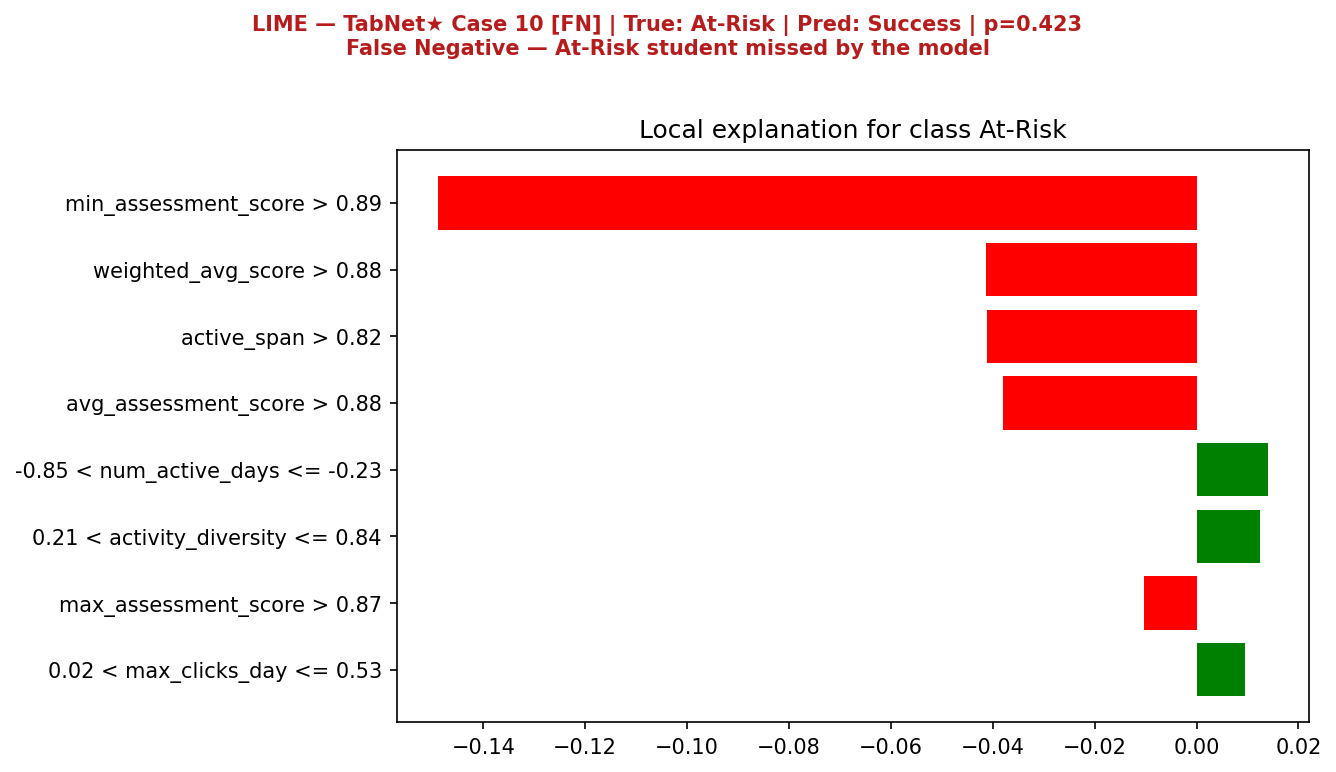

  Case 10 [FN] saved.


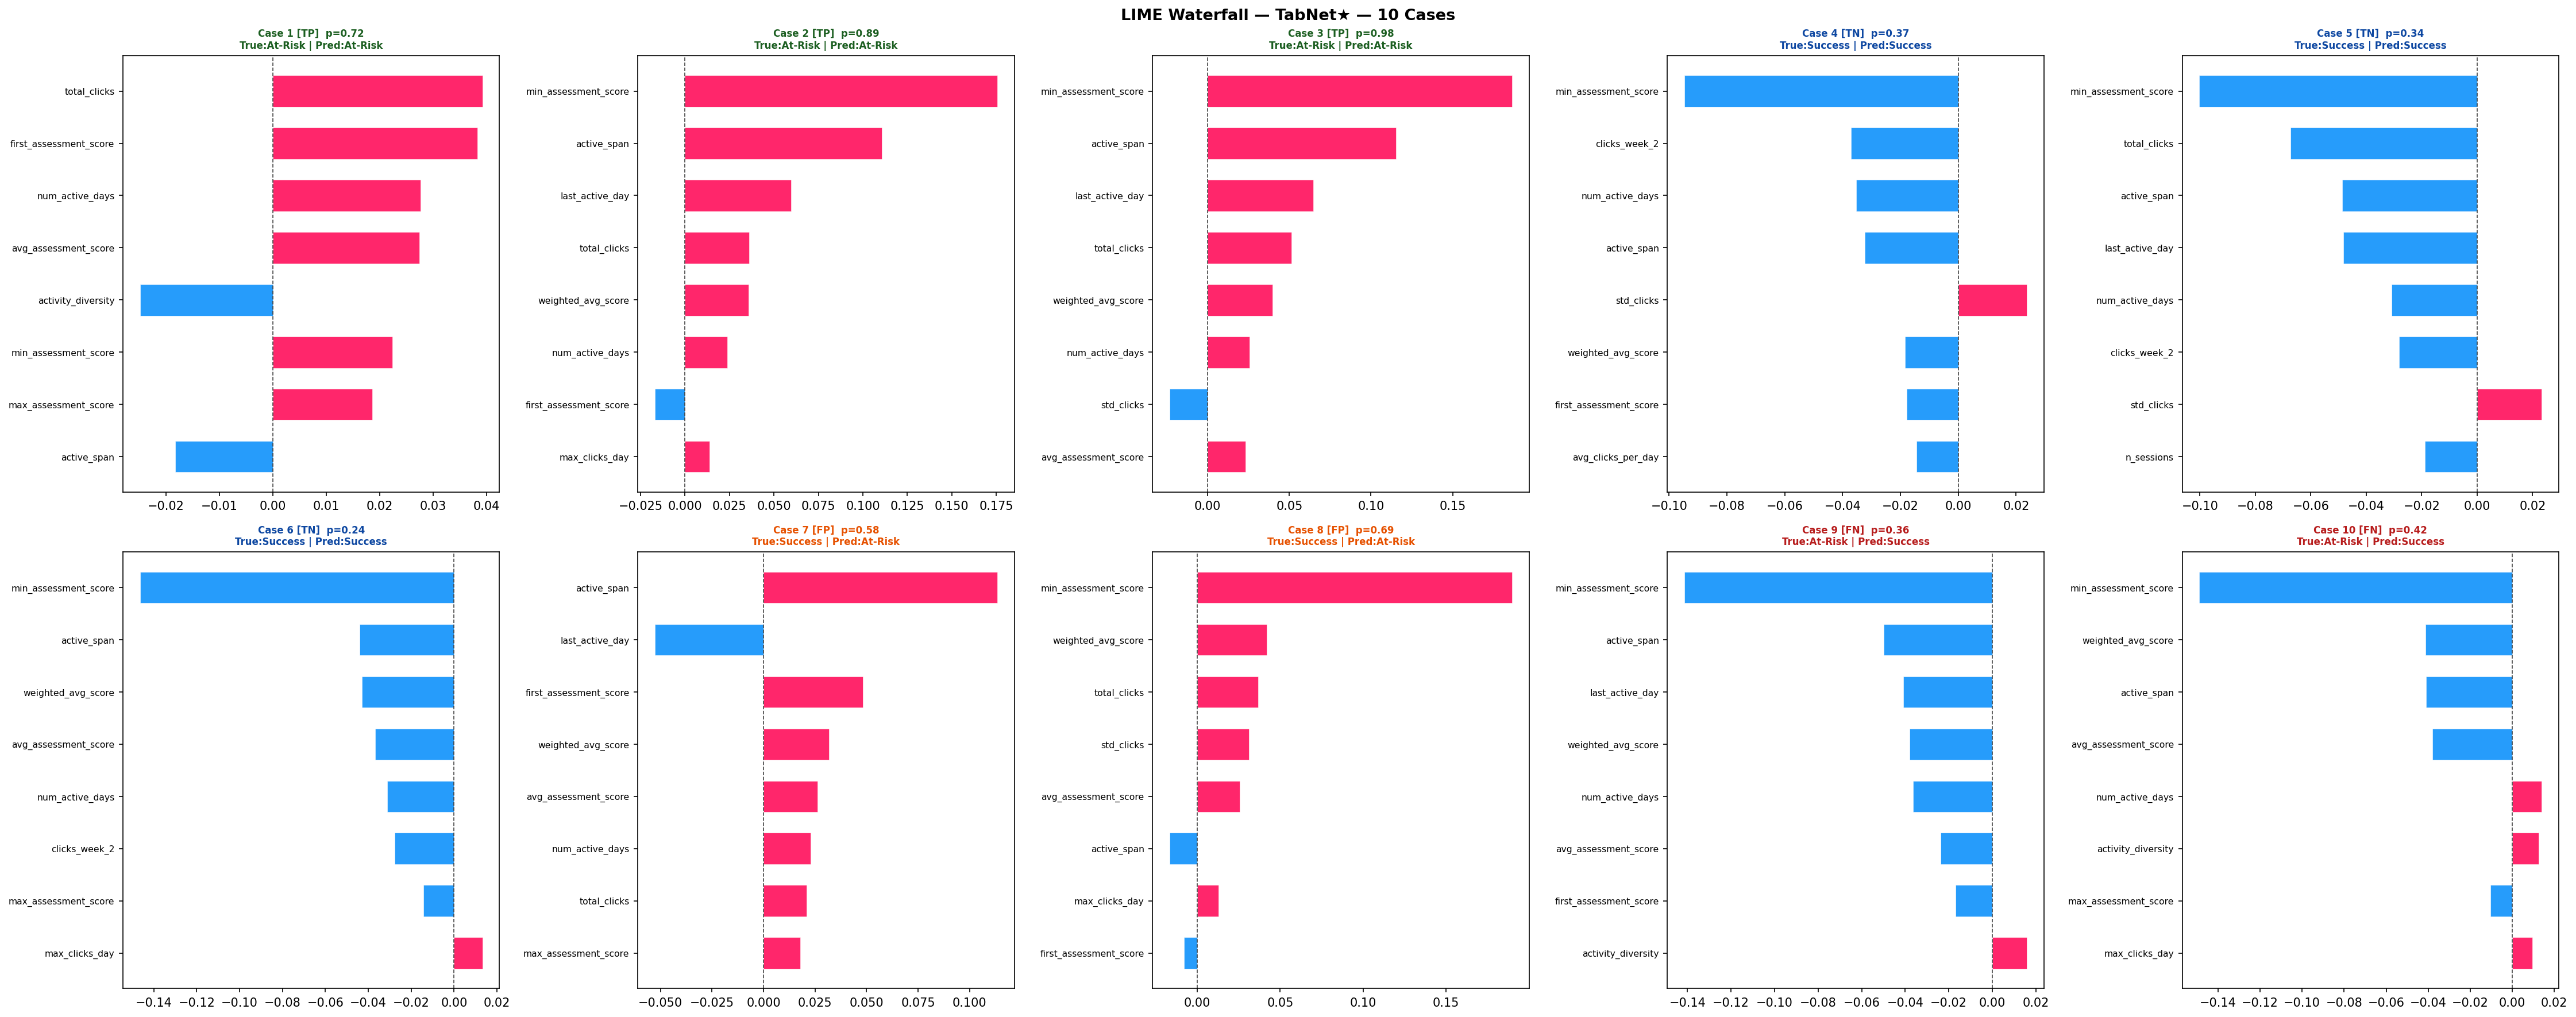


Global LIME (stratified n=300, 5000 perturbations) …
LIME auto-selected: 8 features  |  LIME analysis done.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 14 — LIME ANALYSIS

# ════════════════════════════════════════════════════════════════════════════
lime_exp_tn=lime_tabular.LimeTabularExplainer(
    X_tr_p,feature_names=FEATURE_NAMES_SEL,
    class_names=['Success','At-Risk'],mode='classification',random_state=SEED)

def lime_fn_tn(x): return tabnet.predict_proba(x.astype(np.float32))

LIME_POS='#FF0051'; LIME_NEG='#008BFB'

X_test_orig=pd.DataFrame(
    scl_global.inverse_transform(imp_global.transform(
        X_test_sel.reset_index(drop=True) if hasattr(X_test_sel,'reset_index') else X_test_sel)),
    columns=FEATURE_NAMES_SEL)

lime_base_prob=float(tabnet.predict_proba(X_te_p)[:,1].mean())

def _fmt_val(val): return f'{float(val):.3g}' if val is not None else ''
def _match_feature(feat_str,feature_names):
    for fn in feature_names:
        if fn in feat_str: return fn
    return feat_str[:30]

t0=time.time()
lime_exps=[]
for idx,ctype in zip(local_idx,case_types):
    si=min(idx,len(X_te_p)-1)
    e=lime_exp_tn.explain_instance(X_te_p[si],lime_fn_tn,
        num_features=len(auto_shap_tn),num_samples=LIME_PERTURB_SAMPLES,labels=(1,))
    lime_exps.append(e)
print(f'10 LIME explanations: {time.time()-t0:.1f}s')

# ── Native LIME Style Plots ───────────────────────────────────────────────

print('Generating LIME local explanation plots (native LIME style) …')
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    exp = lime_exps[i]
    tl  = 'At-Risk' if y_test_arr[idx]==1 else 'Success'
    pl  = 'At-Risk' if y_pred_tn_opt[idx]==1 else 'Success'
    pp  = float(y_prob_tn[idx])

    fig = exp.as_pyplot_figure(label=1)
    fig.set_size_inches(9, 5)
    fig.suptitle(
        f'LIME — TabNet★ Case {i+1} [{ctype}] | True: {tl} | Pred: {pl} | p={pp:.3f}\n'
        f'{type_label[ctype]}',
        fontsize=10, fontweight='bold',
        color=type_color[ctype], y=1.02
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/f'lime_local_tn_case_{i+1}_{ctype}.png',dpi=300,bbox_inches='tight')
    plt.show(); plt.close()
    print(f'  Case {i+1} [{ctype}] saved.')

# Summary grid
fig,axes=plt.subplots(2,5,figsize=(30,12)); axes=axes.flatten()
for i,(idx,ctype) in enumerate(zip(local_idx,case_types)):
    exp=lime_exps[i]
    rows=sorted([(_match_feature(fs,FEATURE_NAMES_SEL),w) for fs,w in exp.as_list(label=1)],
                key=lambda r:abs(r[1]),reverse=True)
    shown=rows[:8]; nms=[r[0][:24] for r in reversed(shown)]; vals=[r[1] for r in reversed(shown)]
    axes[i].barh(range(len(nms)),vals,color=[LIME_POS if v>=0 else LIME_NEG for v in vals],
                 alpha=0.85,edgecolor='white',linewidth=0.3,height=0.6)
    axes[i].axvline(0,color='#444',lw=0.8,linestyle='--')
    axes[i].set_yticks(range(len(nms))); axes[i].set_yticklabels(nms,fontsize=7.5)
    axes[i].set_title(f'Case {i+1} [{ctype}]  p={y_prob_tn[idx]:.2f}\n'
                      f'True:{"At-Risk" if y_test_arr[idx]==1 else "Success"} | '
                      f'Pred:{"At-Risk" if y_pred_tn_opt[idx]==1 else "Success"}',
                      fontsize=8,fontweight='bold',color=type_color[ctype])
plt.suptitle('LIME Waterfall — TabNet★ — 10 Cases',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(FIGURES_DIR/'lime_local_TabNet_10cases.png',dpi=150,bbox_inches='tight'); plt.show()

# Global LIME — stratified sample, LIME-default perturbations
print(f'\nGlobal LIME (stratified n={LIME_GLOBAL_N}, {LIME_PERTURB_SAMPLES} perturbations) …')
lime_weights_g={f:[] for f in FEATURE_NAMES_SEL}
np.random.seed(SEED)
for idx2 in stratified_sample_indices(y_test_arr, LIME_GLOBAL_N, SEED):
    e=lime_exp_tn.explain_instance(X_te_p[idx2],lime_fn_tn,
        num_features=len(auto_shap_tn),num_samples=LIME_PERTURB_SAMPLES,labels=(1,))
    for fs,w in e.as_list(label=1):
        fn=_match_feature(fs,FEATURE_NAMES_SEL)
        if fn in lime_weights_g: lime_weights_g[fn].append(abs(w))
lime_global_tn=pd.Series({k:np.mean(v) if v else 0.0 for k,v in lime_weights_g.items()}).sort_values(ascending=False)
lime_thresh=lime_global_tn.mean()+lime_global_tn.std()
auto_lime_tn=lime_global_tn[lime_global_tn>=lime_thresh]
if len(auto_lime_tn)<MIN_FEATURES: auto_lime_tn=lime_global_tn.iloc[:MIN_FEATURES]
auto_lime_tn.to_csv(CSV_DIR/'lime_top_TabNet.csv',header=['LIME_Importance'])
print(f'LIME auto-selected: {len(auto_lime_tn)} features  |  LIME analysis done.')


Computing global LIME — TabNet★, XGBoost, LR (200 samples each) …
Done.
LIME Auto-Selected: TabNet★=8 XGB=8 LR=8

LIME Consensus (≥2/3 paradigms): 7 features
LIME Union                : 15 features

LIME Consensus Ranking Table:
                      TabNet★  XGB  LR(BL)  Vote_Count  Avg_Rank
last_active_day             3    5       2           3    3.3333
num_active_days             8    1       5           3    4.6667
min_assessment_score        1   15       1           2    5.6667
std_clicks                 12    3       6           2    7.0000
total_clicks                4   10       8           2    7.3333
avg_clicks_per_day         15    4       4           2    7.6667
weighted_avg_score          5    8      14           2    9.0000


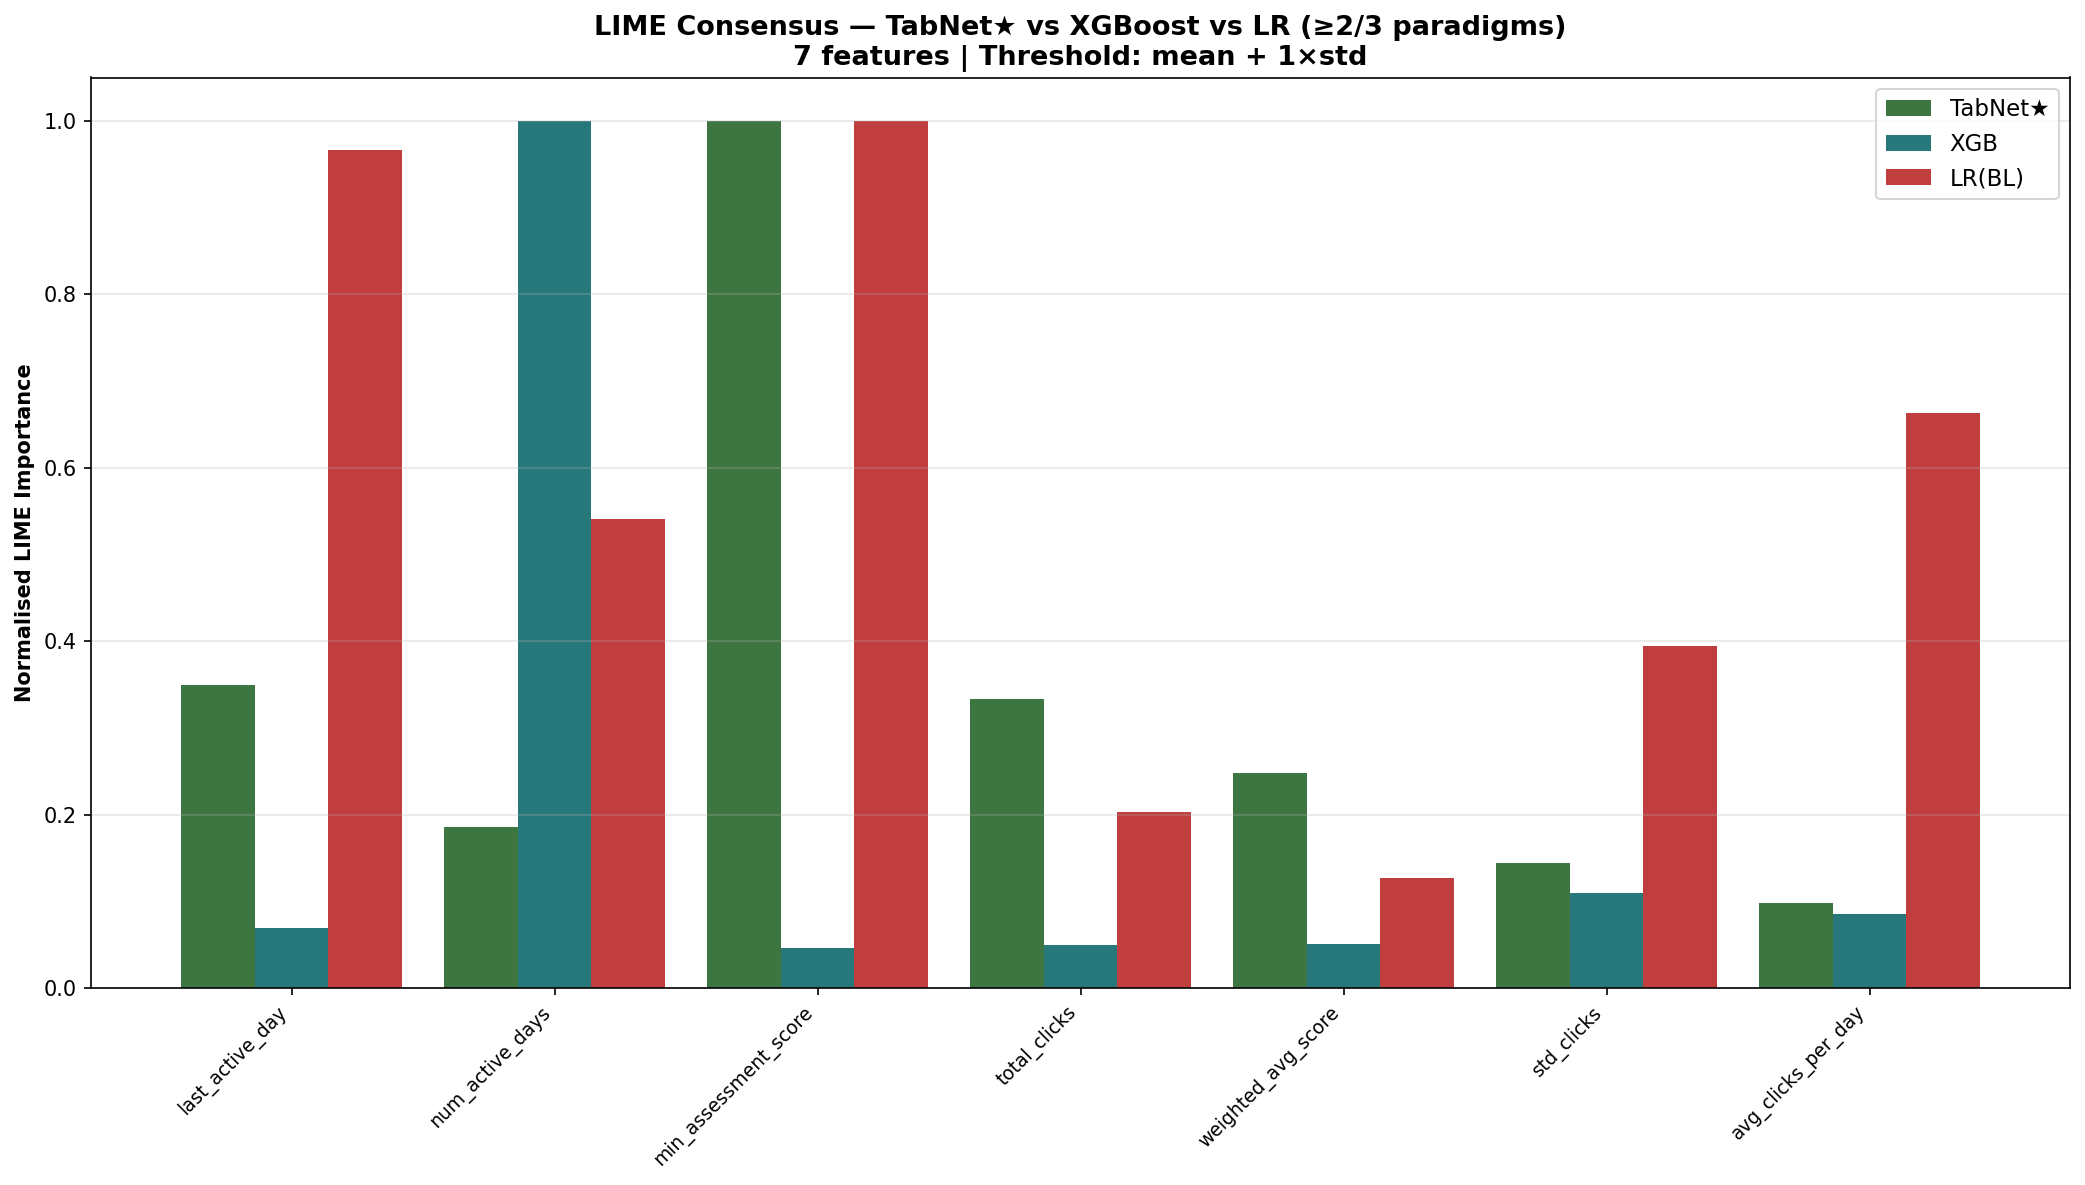

LIME Consensus plot saved.


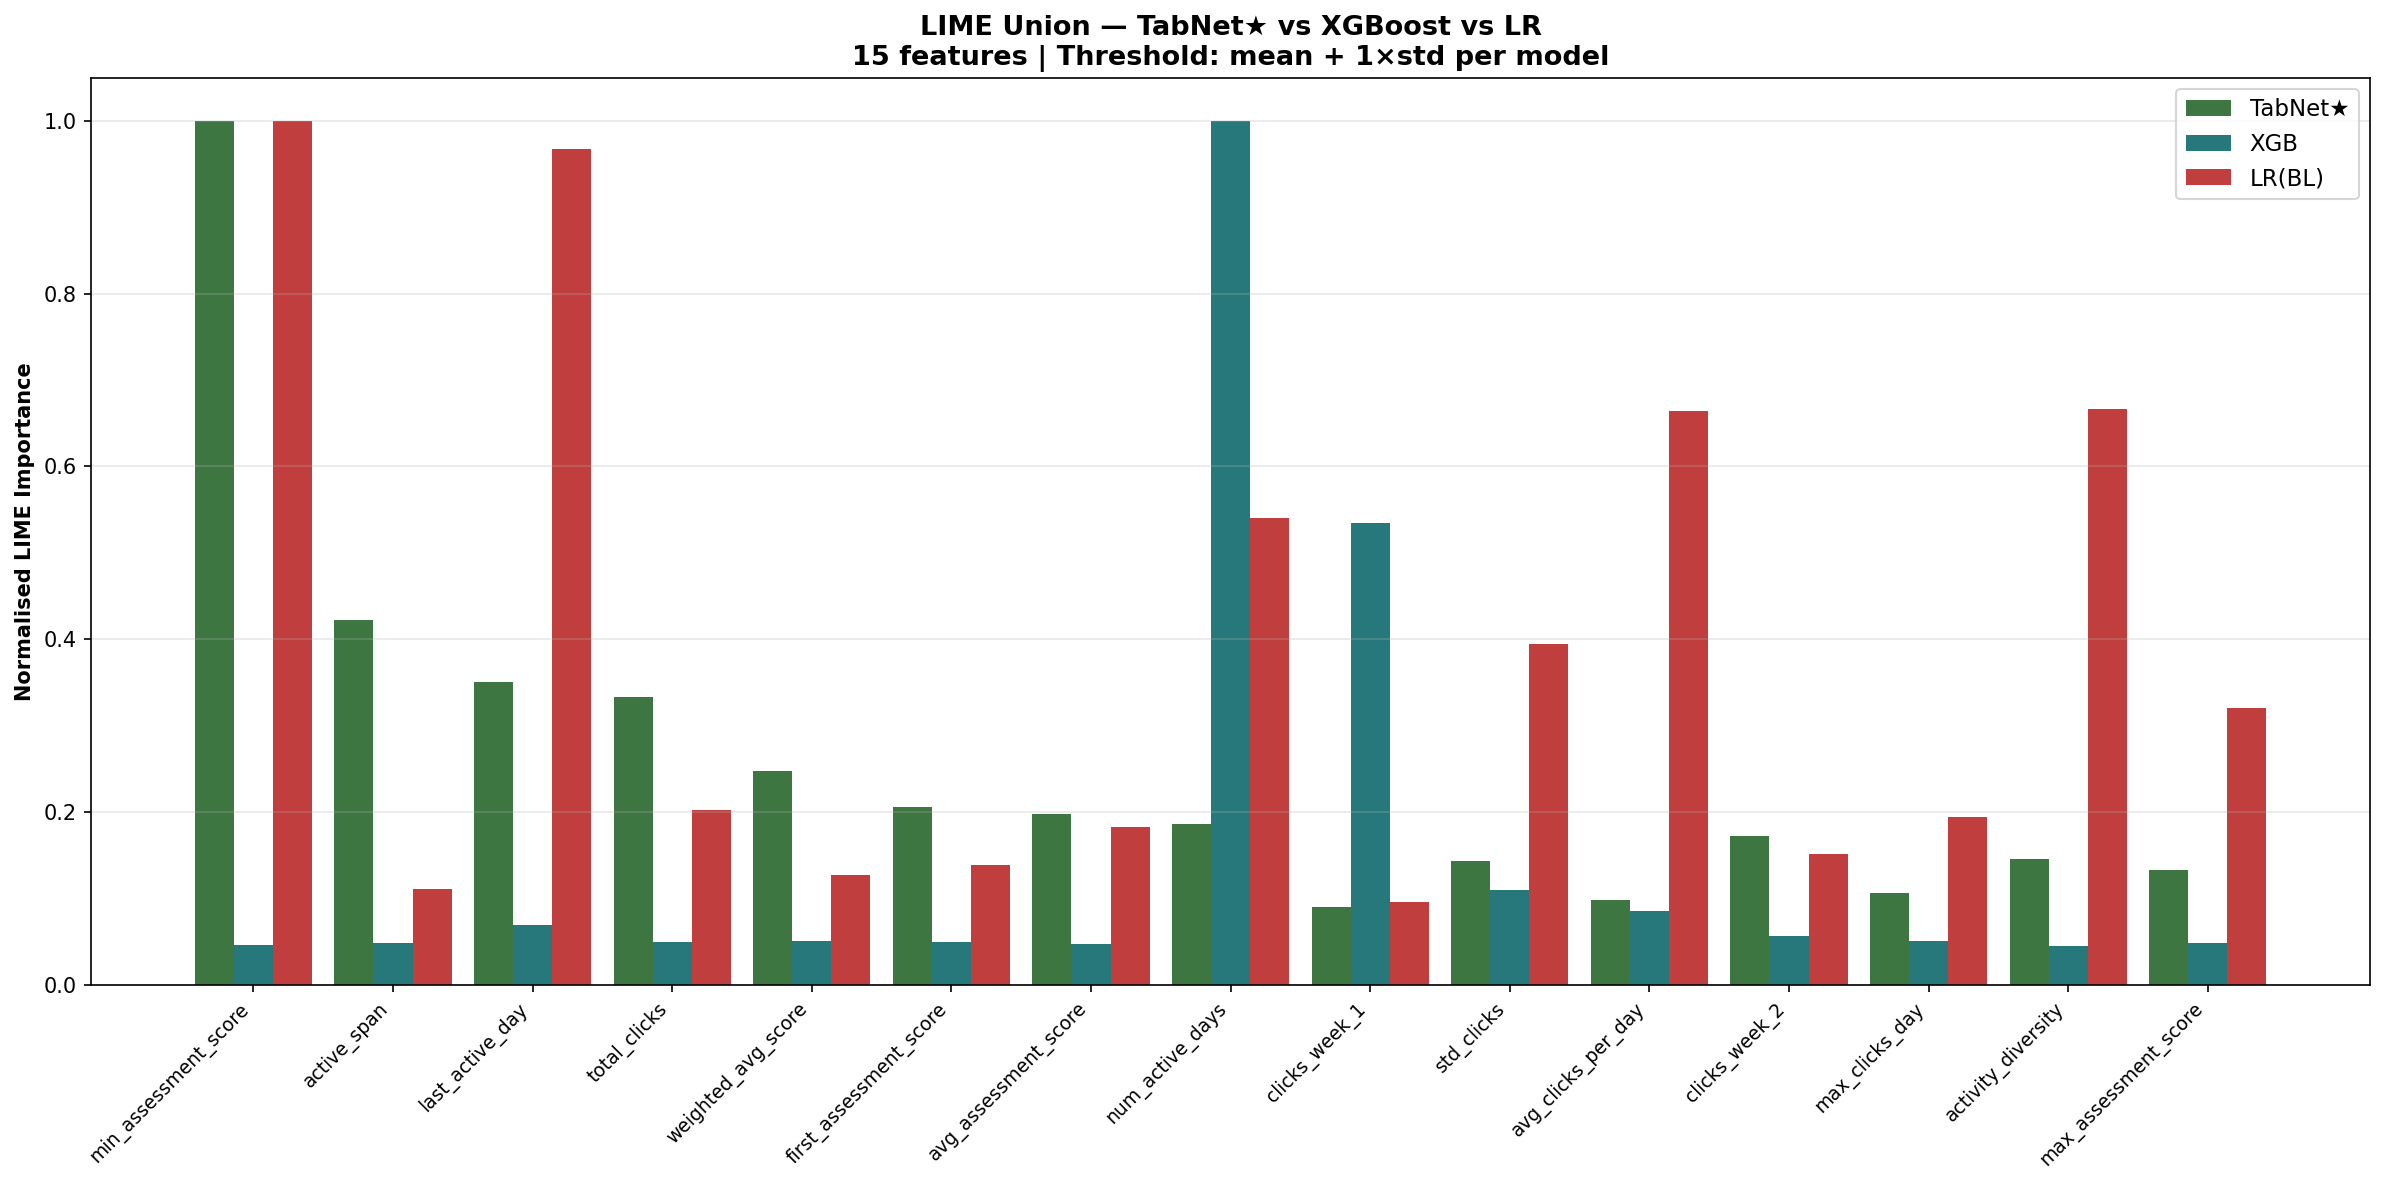

LIME Union plot saved.


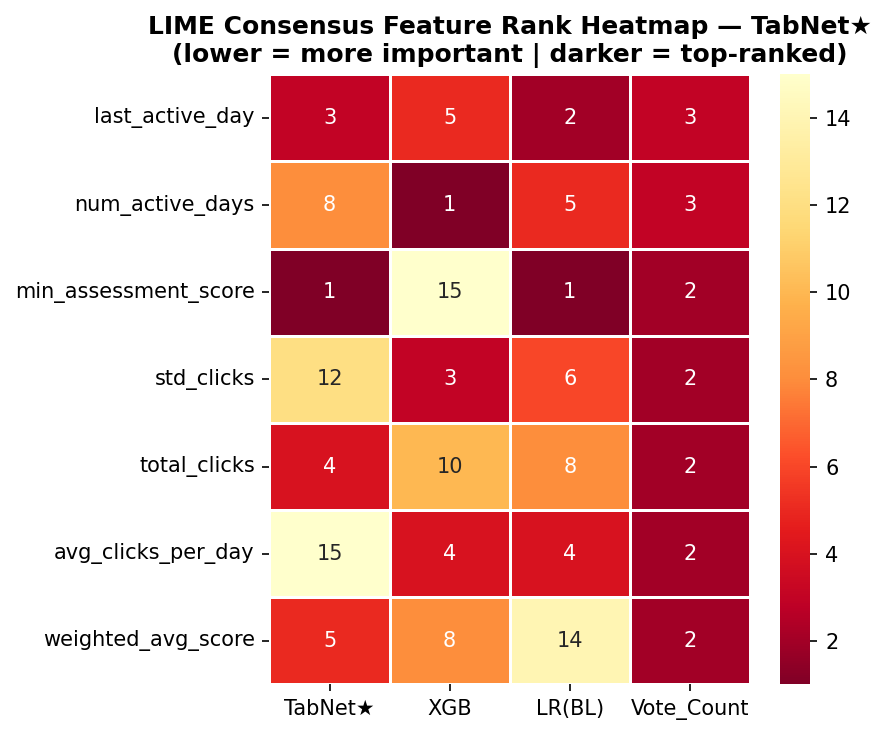


LIME Rankings done — Consensus: 7 | Union: 15


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# LIME AUTO-SELECTED RANKINGS + CONSENSUS (TabNet★ vs XGBoost vs LR)
# ════════════════════════════════════════════════════════════════════════════

def compute_lime_global_tn(predict_fn, X_eval, y_eval=None,
                            n_samples=LIME_GLOBAL_N, n_features=8,
                            n_lime_samples=LIME_PERTURB_SAMPLES, seed=42):
    """Aggregate LIME importances over n_samples instances."""
    np.random.seed(seed)
    le = lime_tabular.LimeTabularExplainer(
        X_tr_p, feature_names=FEATURE_NAMES_SEL,
        class_names=['Success','At-Risk'],
        mode='classification', random_state=seed)
    weights = {f: [] for f in FEATURE_NAMES_SEL}
    if n_samples is None or n_samples >= len(X_eval):
        _eval_idx = np.arange(len(X_eval))
    elif y_eval is not None:
        _eval_idx = stratified_sample_indices(y_eval, n_samples, seed)
    else:
        _eval_idx = np.random.choice(len(X_eval), n_samples, replace=False)
    for idx2 in _eval_idx:
        e = le.explain_instance(
            X_eval[idx2], predict_fn,
            num_features=n_features,
            num_samples=n_lime_samples, labels=(1,))
        for fs, w in e.as_list(label=1):
            fn = _match_feature(fs, FEATURE_NAMES_SEL)
            if fn in weights:
                weights[fn].append(abs(w))
    return pd.Series(
        {k: np.mean(v) if v else 0.0 for k, v in weights.items()}
    ).sort_values(ascending=False)

def auto_select_lime_tn(lime_series, min_feat=MIN_FEATURES):
    thresh = lime_series.mean() + lime_series.std()
    sel    = lime_series[lime_series >= thresh]
    return sel if len(sel) >= min_feat else lime_series.iloc[:min_feat]

# ── Compute global LIME for LR baseline ──────────────────────────────────
print('Computing global LIME — TabNet★, XGBoost, LR (200 samples each) …')

lime_global_tn_m  = lime_global_tn

lime_global_xgb_tn = compute_lime_global_tn(
    lambda x: xgb_model.predict_proba(
        pd.DataFrame(x, columns=FEATURE_NAMES_SEL)),
    X_te_p, y_test_arr, seed=SEED)


lime_global_lr_tn = compute_lime_global_tn(
    lambda x: lr_baseline.predict_proba(x.astype(np.float32)),
    X_te_p, y_test_arr, seed=SEED)

print('Done.')

# ── Auto-select per model ─────────────────────────────────────────────────
auto_lime_tn_m   = auto_select_lime_tn(lime_global_tn_m)
auto_lime_xgb_tn = auto_select_lime_tn(lime_global_xgb_tn)
auto_lime_lr_tn  = auto_select_lime_tn(lime_global_lr_tn)

print(f'LIME Auto-Selected: TabNet★={len(auto_lime_tn_m)} XGB={len(auto_lime_xgb_tn)} LR={len(auto_lime_lr_tn)}')

auto_lime_tn_m.to_csv(CSV_DIR  / 'lime_top_tabnet.csv',      header=['LIME_Importance'])
auto_lime_xgb_tn.to_csv(CSV_DIR/ 'lime_top_xgb_tabnet.csv',  header=['LIME_Importance'])
auto_lime_lr_tn.to_csv(CSV_DIR  / 'lime_top_lr_tabnet.csv',  header=['LIME_Importance'])

# ── Consensus ≥2 models  ───────────────
# ≥2 of 3 models agree — cross-paradigm consensus
all_lime_feats = (list(auto_lime_tn_m.index) + list(auto_lime_xgb_tn.index) +
                  list(auto_lime_lr_tn.index))
lime_vote      = Counter(all_lime_feats)
lime_consensus = [f for f, c in sorted(lime_vote.items(),
                  key=lambda x: -x[1]) if c >= 2]  # >=2 of 3 paradigms
lime_union     = list(dict.fromkeys(all_lime_feats))

print(f'\nLIME Consensus (≥2/3 paradigms): {len(lime_consensus)} features')
print(f'LIME Union                : {len(lime_union)} features')

# ── Ranking table ─────────────────────────────────────────────────────────
lime_model_ranks_tn = [
    (lime_global_tn_m,   'TabNet★', '#1B5E20'),
    (lime_global_xgb_tn, 'XGB',     '#006064'),
    (lime_global_lr_tn,  'LR(BL)',  '#B71C1C'),
]
w_bar = 0.28

if lime_consensus:
    rank_table_lime_tn = pd.DataFrame({
        label: series.rank(ascending=False).astype(int)
        for series, label, _ in lime_model_ranks_tn
    }, index=FEATURE_NAMES_SEL).loc[lime_consensus]
    rank_table_lime_tn['Avg_Rank']   = rank_table_lime_tn.mean(axis=1)
    rank_table_lime_tn['Vote_Count'] = [lime_vote[f] for f in lime_consensus]
    rank_table_lime_tn = rank_table_lime_tn.sort_values('Avg_Rank')
    rank_table_lime_tn.to_csv(CSV_DIR / 'lime_consensus_ranking.csv')
    print('\nLIME Consensus Ranking Table:')
    print(rank_table_lime_tn[['TabNet★','XGB','LR(BL)','Vote_Count','Avg_Rank']].to_string())


lime_union_tn = lime_union

# ── Plot 1: Consensus ─────────────────────────────────────────────────────
if lime_consensus:
    fig, ax = plt.subplots(figsize=(max(14, len(lime_consensus)), 8))
    x = np.arange(len(lime_consensus))
    for ii, (rank, label, color) in enumerate(lime_model_ranks_tn):
        vals = [rank.get(f, 0) / (rank.max() + 1e-9) for f in lime_consensus]
        ax.bar(x + (ii - 1) * w_bar, vals, w_bar, label=label, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:22] for f in lime_consensus], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Normalised LIME Importance', fontweight='bold')
    ax.set_title(f'LIME Consensus — TabNet★ vs XGBoost vs LR (≥2/3 paradigms)\n'
                 f'{len(lime_consensus)} features | Threshold: mean + 1×std',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'lime_consensus_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('LIME Consensus plot saved.')

# ── Plot 2: Union ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16, len(lime_union)), 8))
x = np.arange(len(lime_union))
for ii, (rank, label, color) in enumerate(lime_model_ranks_tn):
    vals = [rank.get(f, 0) / (rank.max() + 1e-9) for f in lime_union]
    ax.bar(x + (ii - 1) * w_bar, vals, w_bar, label=label, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f[:22] for f in lime_union], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalised LIME Importance', fontweight='bold')
ax.set_title(f'LIME Union — TabNet★ vs XGBoost vs LR\n'
             f'{len(lime_union)} features | Threshold: mean + 1×std per model',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lime_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('LIME Union plot saved.')

# ── Heatmap ───────────────────────────────────────────────────────────────
if lime_consensus:
    fig, ax = plt.subplots(figsize=(6, max(5, len(lime_consensus) * 0.5)))
    sns.heatmap(
        rank_table_lime_tn.sort_values('Avg_Rank')[['TabNet★','XGB','LR(BL)','Vote_Count']],
        annot=True, fmt='.0f', cmap='YlOrRd_r', linewidths=0.5, ax=ax)
    ax.set_title('LIME Consensus Feature Rank Heatmap — TabNet★\n'
                 '(lower = more important | darker = top-ranked)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'lime_rank_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'\nLIME Rankings done — Consensus: {len(lime_consensus)} | Union: {len(lime_union)}')


Kendall's τ = 0.5000  p = 0.0752
Not statistically significant (p=0.075)
  → SHAP and LIME capture different perspectives; both are warranted.


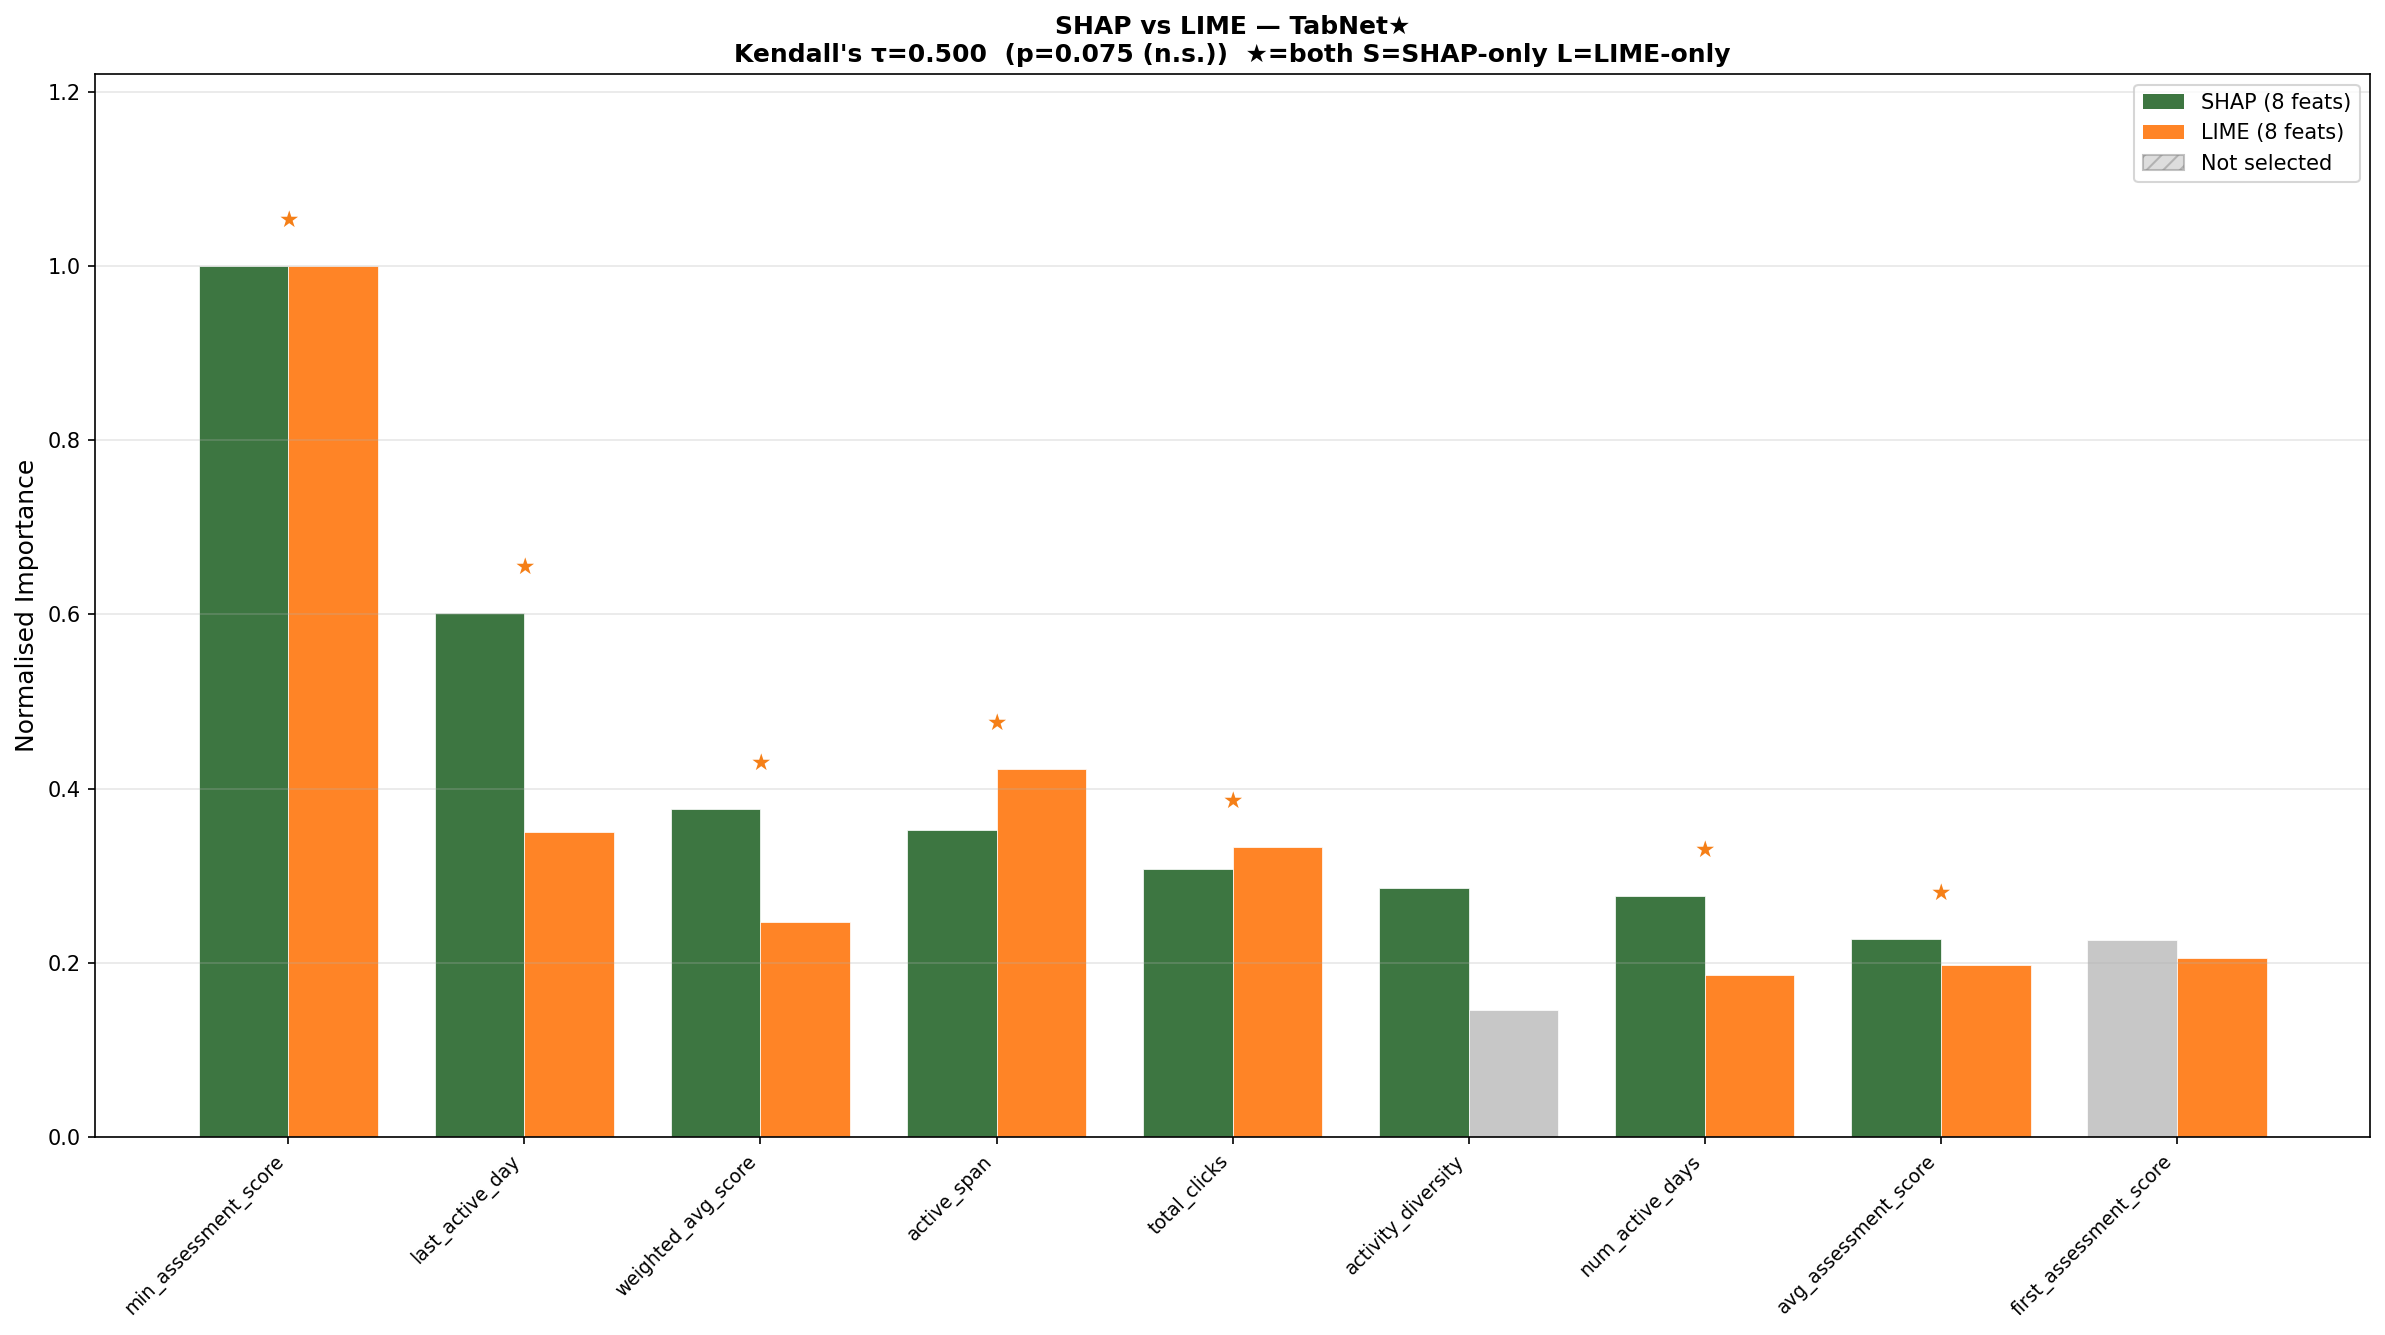

Comparison saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 15 — SHAP vs LIME COMPARISON + Kendall's τ
# ════════════════════════════════════════════════════════════════════════════
union_sl    =list(dict.fromkeys(list(auto_shap_tn.index)+list(auto_lime_tn.index)))
inter_sl    =[f for f in union_sl if f in auto_shap_tn.index and f in auto_lime_tn.index]
shap_only_sl=[f for f in union_sl if f in auto_shap_tn.index and f not in auto_lime_tn.index]
lime_only_sl=[f for f in union_sl if f in auto_lime_tn.index and f not in auto_shap_tn.index]

sr2={f:i+1 for i,f in enumerate(shap_rank_tn.index)}
lr3={f:i+1 for i,f in enumerate(lime_global_tn.index)}
tau,pv=kendalltau([sr2[f] for f in union_sl],[lr3[f] for f in union_sl])
if pv<0.05:
    strength="strong" if abs(tau)>0.6 else "moderate" if abs(tau)>0.3 else "weak"
    sig_note=f"Statistically significant (p={pv:.3f}) — {strength} rank agreement"
else:
    sig_note=(f"Not statistically significant (p={pv:.3f})\n"
              "  → SHAP and LIME capture different perspectives; both are warranted.")
print(f"Kendall's τ = {tau:.4f}  p = {pv:.4f}\n{sig_note}")

from matplotlib.patches import Patch
SHAP_C=PRIMARY_COLOR; LIME_C='#FF6F00'; GREY_C='#BDBDBD'
sv_p2=(shap_rank_tn.reindex(union_sl).fillna(0)/(shap_rank_tn[union_sl].max() or 1)).tolist()
lv_p2=(lime_global_tn.reindex(union_sl).fillna(0)/(lime_global_tn[union_sl].max() or 1)).tolist()

fig,ax=plt.subplots(figsize=(max(16,len(union_sl)),9))
x=np.arange(len(union_sl)); w=0.38
for j,f in enumerate(union_sl):
    cat=('both' if f in inter_sl else 'shap_only' if f in shap_only_sl else 'lime_only')
    sc=SHAP_C if cat in ('both','shap_only') else GREY_C
    lc=LIME_C if cat in ('both','lime_only') else GREY_C
    ax.bar(x[j]-w/2,sv_p2[j],w,color=sc,alpha=0.85,edgecolor='white',linewidth=0.4)
    ax.bar(x[j]+w/2,lv_p2[j],w,color=lc,alpha=0.85,edgecolor='white',linewidth=0.4)
    if cat=='both': ax.text(x[j],max(sv_p2[j],lv_p2[j])+0.045,'★',ha='center',fontsize=11,color='#F57F17',fontweight='bold')
ax.legend(handles=[Patch(facecolor=SHAP_C,alpha=0.85,label=f'SHAP ({len(auto_shap_tn)} feats)'),
                   Patch(facecolor=LIME_C,alpha=0.85,label=f'LIME ({len(auto_lime_tn)} feats)'),
                   Patch(facecolor=GREY_C,alpha=0.5,hatch='///',edgecolor='#888',label='Not selected')],
          fontsize=10,loc='upper right')
ax.set_xticks(x); ax.set_xticklabels([f[:25] for f in union_sl],rotation=45,ha='right',fontsize=9)
ax.set_ylabel('Normalised Importance',fontsize=12); ax.set_ylim(0,1.22); ax.grid(axis='y',alpha=0.3)
sig_str=f"p<0.05 ✓" if pv<0.05 else f"p={pv:.3f} (n.s.)"
ax.set_title(f"SHAP vs LIME — TabNet★\nKendall's τ={tau:.3f}  ({sig_str})  ★=both S=SHAP-only L=LIME-only",
             fontsize=12,fontweight='bold')
plt.tight_layout(); plt.savefig(FIGURES_DIR/'shap_lime_comparison_TabNet.png',dpi=150,bbox_inches='tight'); plt.show()
pd.DataFrame({'Feature':union_sl,
    'Selected_By':['Both' if f in inter_sl else 'SHAP only' if f in shap_only_sl else 'LIME only' for f in union_sl],
    'SHAP_norm':sv_p2,'LIME_norm':lv_p2,'SHAP_rank':[sr2[f] for f in union_sl],'LIME_rank':[lr3[f] for f in union_sl]
}).to_csv(CSV_DIR/'shap_lime_comparison_TabNet.csv',index=False)
print('Comparison saved.')


### ⚠️ Runtime notice — bootstrap stability cell

This cell now retrains TabNet **under the same regime as the main model**
(`max_epochs=200`, `patience=20`, balanced sample weights) and uses
`KernelExplainer` with `bg=100, nsamples=100`, matching the global SHAP
analysis. This is the methodologically correct configuration: it ensures the
measured instability reflects the architecture rather than under-training,
an untreated class imbalance, or a coarser SHAP approximation.

**It is also substantially slower than the previous version.** Expect several
hours on GPU. Run it once, then record the resulting median CV% values.

If you must reduce the cost, change `BOOT_TN_EPOCHS` / `BOOT_SHAP_NSAMPLES`
at the top of the cell — but if you do, **state the reduced values in
Section 4.8.1 of the thesis**, because they are no longer identical to the
main model and the comparison with XGBoost becomes conditional on that.


  [F1] Fixed points (threshold 0.50): TP=8, TN=8, FP=7, FN=7  | total=30
  [F1] REPORT THESE COUNTS IN SECTIONS 3.6.3 AND 4.8.1
Bootstrap Stability — TabNet★ PRIMARY (TabNet retrained each iteration)
  100 iterations  x  30 fixed points
  SHAP : KernelExplainer  (bg=100, nsamples=100)
  LIME : 8 features, 1000 perturbations/point
  TabNet: max_epochs=200, patience=20, balanced sample weights  (identical to the main model)
  Device: cuda
------------------------------------------------------------

Early stopping occurred at epoch 96 with best_epoch = 76 and best_val_auc = 0.80344


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 52 with best_epoch = 32 and best_val_auc = 0.80414


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 61 with best_epoch = 41 and best_val_auc = 0.79852


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 87 with best_epoch = 67 and best_val_auc = 0.7963


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 92 with best_epoch = 72 and best_val_auc = 0.81198


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 71 with best_epoch = 51 and best_val_auc = 0.81598


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 91 with best_epoch = 71 and best_val_auc = 0.80026


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 81 with best_epoch = 61 and best_val_auc = 0.80748


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_auc = 0.80786


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 68 with best_epoch = 48 and best_val_auc = 0.79678


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 10/100]  elapsed=42.3min  ETA=380.8min

Early stopping occurred at epoch 41 with best_epoch = 21 and best_val_auc = 0.80184


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 75 with best_epoch = 55 and best_val_auc = 0.80503


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 82 with best_epoch = 62 and best_val_auc = 0.80728


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 53 with best_epoch = 33 and best_val_auc = 0.80701


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 53 with best_epoch = 33 and best_val_auc = 0.8139


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 81 with best_epoch = 61 and best_val_auc = 0.79024


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 53 with best_epoch = 33 and best_val_auc = 0.80275


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 162 with best_epoch = 142 and best_val_auc = 0.79887


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 44 with best_epoch = 24 and best_val_auc = 0.79033


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 100 with best_epoch = 80 and best_val_auc = 0.82729


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 20/100]  elapsed=82.5min  ETA=329.9min

Early stopping occurred at epoch 47 with best_epoch = 27 and best_val_auc = 0.80647


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 151 with best_epoch = 131 and best_val_auc = 0.81449


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 62 with best_epoch = 42 and best_val_auc = 0.79722


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 43 with best_epoch = 23 and best_val_auc = 0.80769


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 77 with best_epoch = 57 and best_val_auc = 0.79746


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 91 with best_epoch = 71 and best_val_auc = 0.80366


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 69 with best_epoch = 49 and best_val_auc = 0.79037


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 59 with best_epoch = 39 and best_val_auc = 0.81197


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 80 with best_epoch = 60 and best_val_auc = 0.80618


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 96 with best_epoch = 76 and best_val_auc = 0.81467


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 30/100]  elapsed=121.5min  ETA=283.6min

Early stopping occurred at epoch 70 with best_epoch = 50 and best_val_auc = 0.81308


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 55 with best_epoch = 35 and best_val_auc = 0.80562


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 96 with best_epoch = 76 and best_val_auc = 0.80407


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 53 with best_epoch = 33 and best_val_auc = 0.80783


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 43 with best_epoch = 23 and best_val_auc = 0.80937


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 64 with best_epoch = 44 and best_val_auc = 0.80437


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 58 with best_epoch = 38 and best_val_auc = 0.78552


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_auc = 0.79958


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 43 with best_epoch = 23 and best_val_auc = 0.81219


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 99 with best_epoch = 79 and best_val_auc = 0.82052


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 40/100]  elapsed=154.3min  ETA=231.4min

Early stopping occurred at epoch 133 with best_epoch = 113 and best_val_auc = 0.81676


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 78 with best_epoch = 58 and best_val_auc = 0.80439


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_auc = 0.79317


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 50 with best_epoch = 30 and best_val_auc = 0.81818


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 33 with best_epoch = 13 and best_val_auc = 0.80057


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 89 with best_epoch = 69 and best_val_auc = 0.80171


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 66 with best_epoch = 46 and best_val_auc = 0.80118


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 138 with best_epoch = 118 and best_val_auc = 0.82867


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 93 with best_epoch = 73 and best_val_auc = 0.8013


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 58 with best_epoch = 38 and best_val_auc = 0.81478


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 50/100]  elapsed=193.9min  ETA=193.9min

Early stopping occurred at epoch 69 with best_epoch = 49 and best_val_auc = 0.82058


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 50 with best_epoch = 30 and best_val_auc = 0.81348


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 41 with best_epoch = 21 and best_val_auc = 0.78732


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 113 with best_epoch = 93 and best_val_auc = 0.80172


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 41 with best_epoch = 21 and best_val_auc = 0.80123


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 87 with best_epoch = 67 and best_val_auc = 0.80162


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 78 with best_epoch = 58 and best_val_auc = 0.80402


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 65 with best_epoch = 45 and best_val_auc = 0.81104


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 95 with best_epoch = 75 and best_val_auc = 0.7973


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 93 with best_epoch = 73 and best_val_auc = 0.81603


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 60/100]  elapsed=231.4min  ETA=154.3min

Early stopping occurred at epoch 95 with best_epoch = 75 and best_val_auc = 0.81806


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 92 with best_epoch = 72 and best_val_auc = 0.81748


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 84 with best_epoch = 64 and best_val_auc = 0.82087


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 56 with best_epoch = 36 and best_val_auc = 0.81154


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 35 with best_epoch = 15 and best_val_auc = 0.79511


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 176 with best_epoch = 156 and best_val_auc = 0.82588


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 66 with best_epoch = 46 and best_val_auc = 0.81472


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_auc = 0.80899


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 51 with best_epoch = 31 and best_val_auc = 0.8104


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 70 with best_epoch = 50 and best_val_auc = 0.7941


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 70/100]  elapsed=270.7min  ETA=116.0min

Early stopping occurred at epoch 53 with best_epoch = 33 and best_val_auc = 0.80097


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 58 with best_epoch = 38 and best_val_auc = 0.80368


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 65 with best_epoch = 45 and best_val_auc = 0.79748


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_auc = 0.81524


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 116 with best_epoch = 96 and best_val_auc = 0.81872


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 55 with best_epoch = 35 and best_val_auc = 0.79267


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 70 with best_epoch = 50 and best_val_auc = 0.792


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 48 with best_epoch = 28 and best_val_auc = 0.80304


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 97 with best_epoch = 77 and best_val_auc = 0.80428


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 57 with best_epoch = 37 and best_val_auc = 0.79899


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 80/100]  elapsed=304.9min  ETA=76.2min

Early stopping occurred at epoch 74 with best_epoch = 54 and best_val_auc = 0.80671


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 36 with best_epoch = 16 and best_val_auc = 0.79468


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 75 with best_epoch = 55 and best_val_auc = 0.79435


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 147 with best_epoch = 127 and best_val_auc = 0.81366


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 31 with best_epoch = 11 and best_val_auc = 0.79655


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 112 with best_epoch = 92 and best_val_auc = 0.81261


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 69 with best_epoch = 49 and best_val_auc = 0.8105


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 34 with best_epoch = 14 and best_val_auc = 0.80164


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 69 with best_epoch = 49 and best_val_auc = 0.81724


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 47 with best_epoch = 27 and best_val_auc = 0.80053


  0%|          | 0/30 [00:00<?, ?it/s]

  [ 90/100]  elapsed=340.2min  ETA=37.8min

Early stopping occurred at epoch 75 with best_epoch = 55 and best_val_auc = 0.80951


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 70 with best_epoch = 50 and best_val_auc = 0.80323


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 47 with best_epoch = 27 and best_val_auc = 0.79921


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 49 with best_epoch = 29 and best_val_auc = 0.79558


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 88 with best_epoch = 68 and best_val_auc = 0.80391


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 71 with best_epoch = 51 and best_val_auc = 0.79016


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 71 with best_epoch = 51 and best_val_auc = 0.81283


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 148 with best_epoch = 128 and best_val_auc = 0.81698


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 52 with best_epoch = 32 and best_val_auc = 0.79107


  0%|          | 0/30 [00:00<?, ?it/s]


Early stopping occurred at epoch 51 with best_epoch = 31 and best_val_auc = 0.8064


  0%|          | 0/30 [00:00<?, ?it/s]

  [100/100]  elapsed=376.4min  ETA=0.0min

Total bootstrap time: 376.4 min

[F5] No LIME explanation failures.

Stability Results (sorted by SHAP CV%):
             Feature  SHAP_n  SHAP_CV%  LIME_n  LIME_CV%
     last_active_day     100     27.22     100     43.34
  activity_diversity     100     31.03     100     41.27
     num_active_days     100     32.48     100     35.67
         active_span     100     41.53     100     27.15
        total_clicks     100     47.42     100     30.71
  weighted_avg_score     100     55.22     100     44.40
min_assessment_score     100     64.12     100     56.13
avg_assessment_score     100     65.74     100     59.08

Median CV% — SHAP: 44.5%   LIME: 42.3%
(Lower CV% = more stable explanations)


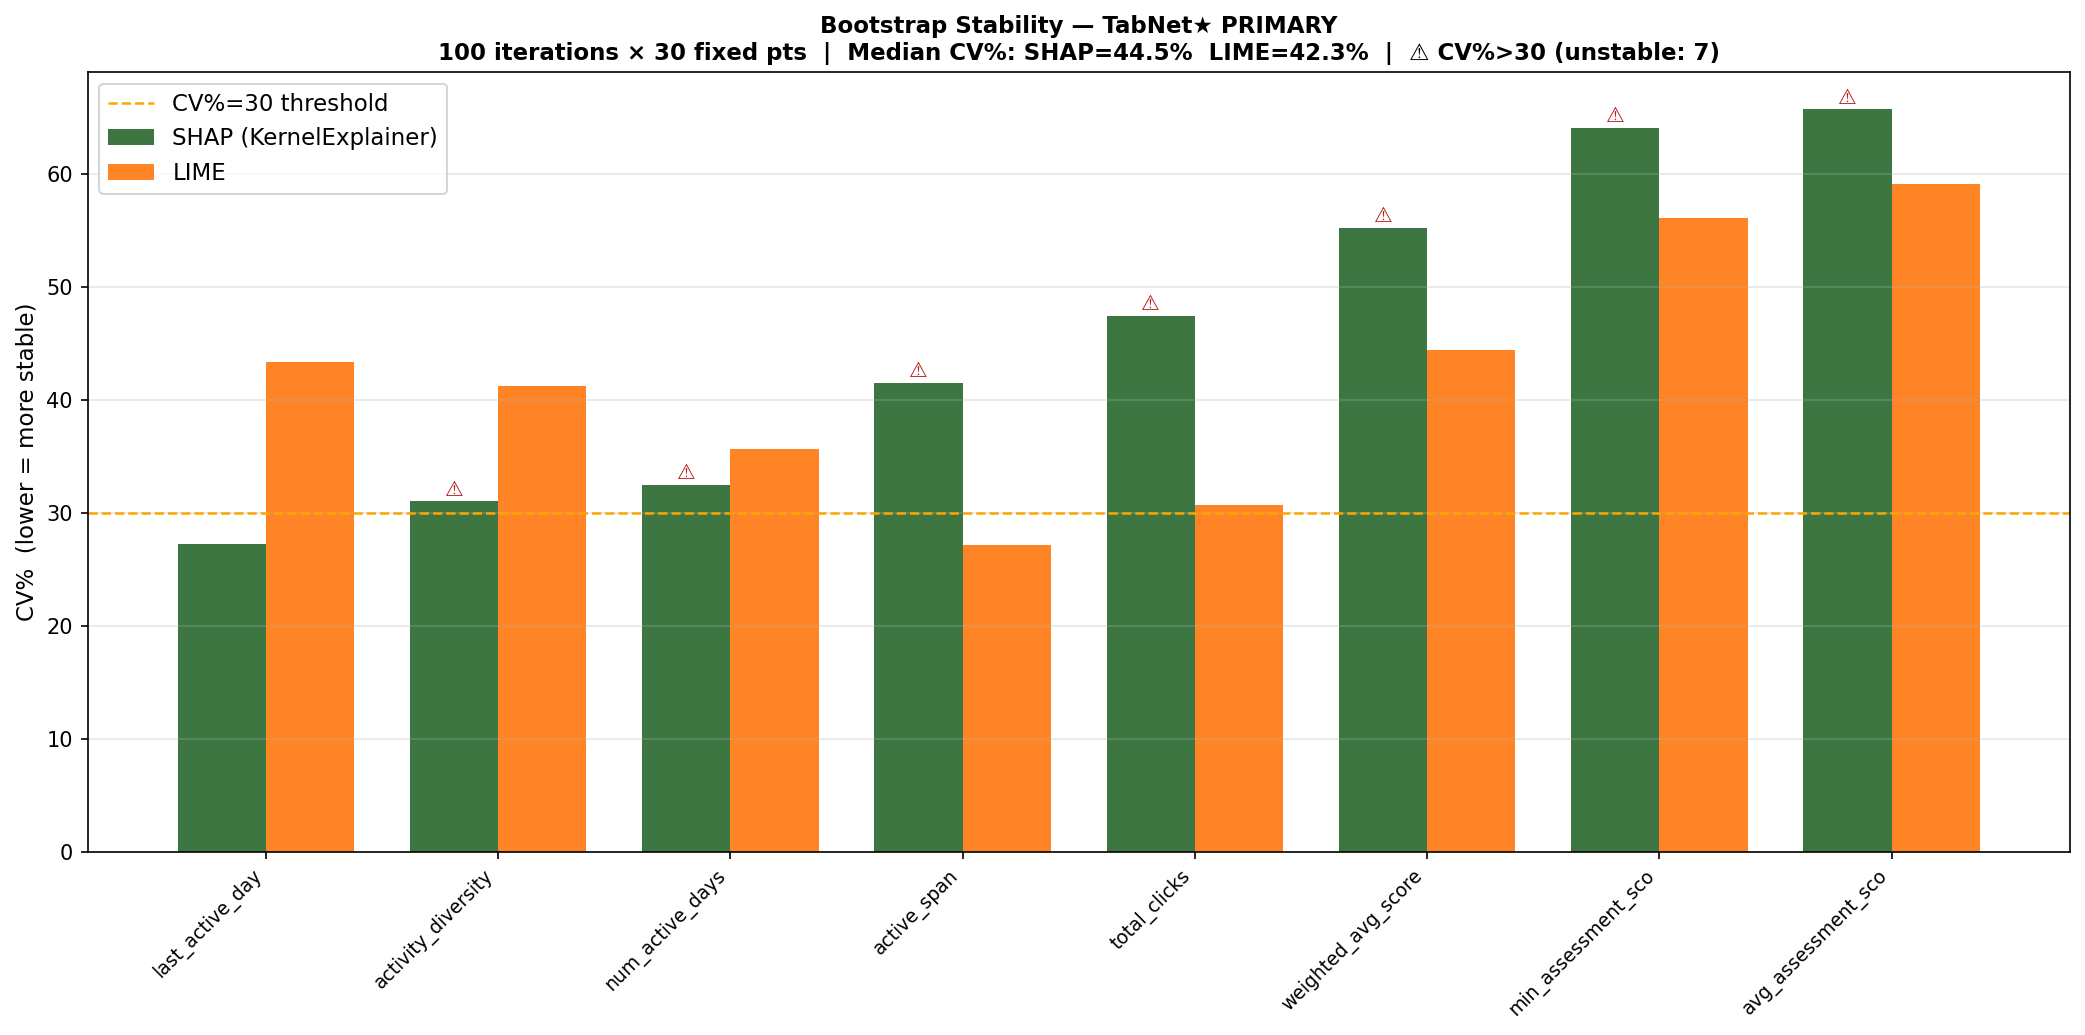


Stability Verdict:
  Stable   (CV% ≤ 30): 1 features
  Unstable (CV% > 30): 7 features
  Unstable features  : ['activity_diversity', 'num_active_days', 'active_span', 'total_clicks', 'weighted_avg_score', 'min_assessment_score', 'avg_assessment_score']
  → Interpret their SHAP/LIME importance with caution.
Bootstrap Stability analysis saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 17 — BOOTSTRAP STABILITY  (100 iterations x 30 fixed points)
#

# ════════════════════════════════════════════════════════════════════════════

N_BOOT      = 100
N_FIX       = 30
N_LIME_FEAT = len(auto_shap_tn)
# 1000 = literature lower bound; full 5000 x bootstrap iters is prohibitive.
# Single-shot global LIME uses the full 5000.
N_LIME_SAMP = 1000
trk_feats   = list(auto_shap_tn.index)

np.random.seed(SEED)
torch.manual_seed(SEED)


# ── [FIX F1] Stratified selection of the fixed bootstrap evaluation points ──
# The previous version used np.random.choice(..., replace=False), i.e. a simple
# random sample. The methodology requires proportional representation of the
# four confusion-matrix categories (TP, TN, FP, FN) at the default threshold
# tau = 0.50, so that the stability estimate is not dominated by whichever
# category happens to be over-drawn. This helper enforces that quota and
# reports the realised composition, which is the number the thesis cites.
def stratified_fixed_points(y_true, y_prob, n_fix, thr=0.50, seed=SEED, verbose=True):
    """Pick n_fix test indices with ~equal representation of TP/TN/FP/FN."""
    y_true = np.asarray(y_true).astype(int)
    y_hat  = (np.asarray(y_prob) >= thr).astype(int)
    cats = {
        'TP': np.where((y_true == 1) & (y_hat == 1))[0],
        'TN': np.where((y_true == 0) & (y_hat == 0))[0],
        'FP': np.where((y_true == 0) & (y_hat == 1))[0],
        'FN': np.where((y_true == 1) & (y_hat == 0))[0],
    }
    rng = np.random.RandomState(seed)
    base, extra = divmod(n_fix, 4)
    quota = {k: base for k in cats}
    # distribute the remainder to the largest categories first, deterministically
    for k in sorted(cats, key=lambda c: -len(cats[c]))[:extra]:
        quota[k] += 1
    picked, realised = [], {}
    for k in ['TP', 'TN', 'FP', 'FN']:
        take = min(quota[k], len(cats[k]))
        if take > 0:
            picked.extend(rng.choice(cats[k], take, replace=False))
        realised[k] = take
    picked = np.array(picked)
    # if a category was too small to fill its quota, top up from the remainder
    if len(picked) < n_fix:
        pool = np.setdiff1d(np.arange(len(y_true)), picked)
        picked = np.concatenate([picked, rng.choice(pool, n_fix - len(picked),
                                                    replace=False)])
    picked = np.sort(picked)
    if verbose:
        print(f'  [F1] Fixed points (threshold {thr:.2f}): '
              + ', '.join(f'{k}={realised[k]}' for k in ["TP","TN","FP","FN"])
              + f'  | total={len(picked)}')
        print(f'  [F1] REPORT THESE COUNTS IN SECTIONS 3.6.3 AND 4.8.1')
    return picked, realised

fix_idx, fix_composition = stratified_fixed_points(
    y_test_arr, y_prob_tn, N_FIX, thr=0.50, seed=SEED)
X_fix   = X_te_p[fix_idx]

# [FIX F2/F3] bootstrap configuration now mirrors the main analysis
BOOT_TN_EPOCHS     = 200     # was 50
BOOT_TN_PATIENCE   = 20      # was 10
BOOT_SHAP_BG       = 100     # was 50
BOOT_SHAP_NSAMPLES = 100     # was 50

sb = {f: [] for f in trk_feats}   # SHAP weights per iteration
lb = {f: [] for f in trk_feats}   # LIME weights per iteration
n_lime_fail = 0                                     # [FIX F5]

print(f'Bootstrap Stability — TabNet★ PRIMARY (TabNet retrained each iteration)')
print(f'  {N_BOOT} iterations  x  {N_FIX} fixed points')
print(f'  SHAP : KernelExplainer  (bg={BOOT_SHAP_BG}, nsamples={BOOT_SHAP_NSAMPLES})')
print(f'  LIME : {N_LIME_FEAT} features, {N_LIME_SAMP} perturbations/point')
print(f'  TabNet: max_epochs={BOOT_TN_EPOCHS}, patience={BOOT_TN_PATIENCE}, '
      f'balanced sample weights  (identical to the main model)')
print(f'  Device: {DEVICE}')
print('-' * 60)
# ── Academic note on expected instability (RQ1 finding) ──────────────────
# TabNet is retrained from scratch each iteration under the SAME regime as
# the main model (max_epochs=200, patience=20, balanced sample weights), so
# any residual instability is attributable to the architecture rather than to
# under-training or to an untreated class imbalance. Higher CV% vs XGBoost
# is therefore a valid RQ1 finding:
#   'Deep learning XAI explanations (KernelSHAP on TabNet) are less
#    stable under bootstrap perturbation than tree-based SHAP (XGBoost),
#    consistent with the stochastic nature of neural attention mechanisms.'
# Reference: Alvarez-Melis & Jaakkola (2018). Towards Robust Interpretability.

t_start = time.time()

for b in range(N_BOOT):

    # ── Bootstrap sample ──────────────────────────────────────────────────
    bi  = np.random.choice(len(X_train_np), len(X_train_np), replace=True)
    Xb  = X_train_np[bi].astype(np.float32)
    yb  = y_train_arr[bi].astype(np.int64)

    # Stratified val split
    try:
        Xb_tr, Xb_val, yb_tr, yb_val = tts(
            Xb, yb, test_size=0.15, stratify=yb, random_state=SEED + b)
    except ValueError:
        Xb_tr, Xb_val, yb_tr, yb_val = tts(
            Xb, yb, test_size=0.15, random_state=SEED + b)

    # ── Retrain TabNet (stability mode) ───────────────────────────────────
    tn_b = TabNetClassifier(
        n_d=32, n_a=32, n_steps=5, gamma=1.5,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params={'lr': 2e-3, 'weight_decay': 1e-5},
        mask_type='sparsemax',
        device_name=DEVICE,
        seed=SEED + b,
        verbose=0,
    )
    # [FIX F2] The bootstrap models must be trained under the SAME regime as
    #          the main model, otherwise the measured instability confounds
    #          architecture with under-training and with an untreated class
    #          imbalance. Restored: max_epochs/patience from Cell 8, and the
    #          balanced sample weights that the main model receives.
    # identical formula to the main model (Cell 6): neg_weight=1, pos_weight=imb_ratio
    _imb_b = (yb_tr == 0).sum() / max((yb_tr == 1).sum(), 1)
    sw_b   = np.where(yb_tr == 1, _imb_b, 1.0).astype(np.float32)
    tn_b.fit(
        X_train=Xb_tr, y_train=yb_tr,
        eval_set=[(Xb_val, yb_val)],
        eval_name=['val'], eval_metric=['auc'],
        weights=sw_b,
        max_epochs=BOOT_TN_EPOCHS,
        patience=BOOT_TN_PATIENCE,
        batch_size=256,
        virtual_batch_size=128,
        num_workers=0,
    )

    # ── SHAP: KernelExplainer ─────────────────────────────────────────────
    # [FIX F3] raised from 50/50 to match the main analysis (100/100)
    bg_b     = shap.sample(Xb_tr, BOOT_SHAP_BG, random_state=SEED + b)
    se_b     = shap.KernelExplainer(
        lambda x: tn_b.predict_proba(x.astype(np.float32))[:, 1], bg_b)
    sv_b_raw = se_b.shap_values(X_fix, nsamples=BOOT_SHAP_NSAMPLES)
    sv_b     = safe_kernel_shap(sv_b_raw, len(FEATURE_NAMES_SEL))
    ms       = np.abs(sv_b).mean(0)
    for f in trk_feats:
        if f in FEATURE_NAMES_SEL:
            sb[f].append(ms[FEATURE_NAMES_SEL.index(f)])

    # ── LIME: all N_FIX points ────────────────────────────────────────────
    le_b = lime_tabular.LimeTabularExplainer(
        Xb_tr.astype(np.float32),
        feature_names=FEATURE_NAMES_SEL,
        class_names=['Success', 'At-Risk'],
        mode='classification',
        random_state=SEED + b)
    lw_iter = {f: [] for f in trk_feats}
    for j in range(N_FIX):
        try:
            ex = le_b.explain_instance(
                X_fix[j].astype(np.float32),
                lambda x: tn_b.predict_proba(x.astype(np.float32)),
                num_features=N_LIME_FEAT,
                num_samples=N_LIME_SAMP,
                labels=(1,))
            for feat_str, w in ex.as_list(label=1):
                # [FIX F4] use the same matcher as compute_lime_global
                fn = _match_feature(feat_str, FEATURE_NAMES_SEL)
                if fn in lw_iter:
                    lw_iter[fn].append(abs(w))
        except Exception as e:                      # [FIX F5] count, don't swallow
            n_lime_fail += 1
            if n_lime_fail <= 3:
                print(f'    [warn] LIME failed (iter {b}, point {j}): '
                      f'{type(e).__name__}: {e}')
    for f in trk_feats:
        if lw_iter[f]:
            lb[f].append(np.mean(lw_iter[f]))

    if (b + 1) % 10 == 0:
        elapsed = time.time() - t_start
        eta     = elapsed / (b + 1) * (N_BOOT - b - 1)
        print(f'  [{b+1:3d}/{N_BOOT}]  '
              f'elapsed={elapsed/60:.1f}min  '
              f'ETA={eta/60:.1f}min')

total_time = time.time() - t_start
print(f'\nTotal bootstrap time: {total_time/60:.1f} min')

# ── CV% ───────────────────────────────────────────────────────────────────
if n_lime_fail:                                     # [FIX F5]
    print(f'\n[F5] LIME explanations that failed: {n_lime_fail} '
          f'of {N_BOOT*N_FIX} ({100*n_lime_fail/(N_BOOT*N_FIX):.2f}%) '
          f'- report this figure if non-zero.')
else:
    print('\n[F5] No LIME explanation failures.')

def cv_percent(values):
    arr = np.array(values, dtype=float)
    if len(arr) < 5 or arr.mean() == 0:
        return np.nan
    return arr.std() / arr.mean() * 100

stab_rows = []
for f in trk_feats:
    stab_rows.append({
        'Feature'  : f,
        'SHAP_n'   : len(sb[f]),
        'SHAP_Mean': np.mean(sb[f])    if sb[f] else np.nan,
        'SHAP_Std' : np.std(sb[f])     if sb[f] else np.nan,
        'SHAP_CV%' : cv_percent(sb[f]),
        'LIME_n'   : len(lb[f]),
        'LIME_Mean': np.nanmean(lb[f]) if lb[f] else np.nan,
        'LIME_CV%' : cv_percent(lb[f]),
    })

stab = pd.DataFrame(stab_rows).sort_values('SHAP_CV%')
stab.to_csv(CSV_DIR / 'stability_TabNet.csv', index=False)

shap_cv_med = stab['SHAP_CV%'].dropna().median()
lime_cv_med = stab['LIME_CV%'].dropna().median()

print('\nStability Results (sorted by SHAP CV%):')
print(stab[['Feature','SHAP_n','SHAP_CV%','LIME_n','LIME_CV%']].to_string(
    index=False, float_format='{:.2f}'.format))
print(f'\nMedian CV% — SHAP: {shap_cv_med:.1f}%   LIME: {lime_cv_med:.1f}%')
print('(Lower CV% = more stable explanations)')

# ── Visualisation ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(stab)); w = 0.38

shap_cv_plot = stab['SHAP_CV%'].fillna(0).values
lime_cv_plot = stab['LIME_CV%'].fillna(0).values

ax.bar(x - w/2, shap_cv_plot, w,
       label='SHAP (KernelExplainer)', color=PRIMARY_COLOR, alpha=0.85)
lime_bars = ax.bar(x + w/2, lime_cv_plot, w,
                   label='LIME', color='#FF6F00', alpha=0.85)

# NaN LIME bars
for j, lv in enumerate(stab['LIME_CV%']):
    if np.isnan(lv):
        lime_bars[j].set_hatch('///')
        lime_bars[j].set_edgecolor('#888')
        lime_bars[j].set_facecolor('#CCCCCC')
        ax.text(x[j] + w/2, 1.5, 'N/A',
                ha='center', va='bottom', fontsize=7,
                color='#555', style='italic')

ax.axhline(30, color='orange', linestyle='--',
           linewidth=1.2, label='CV%=30 threshold')

# Unstable markers
stab_r = stab.reset_index(drop=True)
for j, row in stab_r.iterrows():
    if not np.isnan(row['SHAP_CV%']) and row['SHAP_CV%'] > 30:
        ax.text(x[j] - w/2, row['SHAP_CV%'] + 0.5, '⚠',
                ha='center', fontsize=10, color='#B71C1C')

ax.set_xticks(x)
ax.set_xticklabels([f[:18] for f in stab['Feature']],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('CV%  (lower = more stable)', fontsize=11)

n_stable   = (stab['SHAP_CV%'].dropna() <= 30).sum()
n_unstable = (stab['SHAP_CV%'].dropna() >  30).sum()

ax.set_title(
    f'Bootstrap Stability — TabNet★ PRIMARY\n'
    f'{N_BOOT} iterations × {N_FIX} fixed pts  |  '
    f'Median CV%: SHAP={shap_cv_med:.1f}%  LIME={lime_cv_med:.1f}%  |  '
    f'⚠ CV%>30 (unstable: {n_unstable})',
    fontweight='bold', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'stability_TabNet.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStability Verdict:')
print(f'  Stable   (CV% ≤ 30): {n_stable} features')
print(f'  Unstable (CV% > 30): {n_unstable} features')
if n_unstable > 0:
    unstable_list = stab[stab['SHAP_CV%'] > 30]['Feature'].tolist()
    print(f'  Unstable features  : {unstable_list}')
    print('  → Interpret their SHAP/LIME importance with caution.')
print('Bootstrap Stability analysis saved.')


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Method  Total_s  Per_Instance_ms
  SHAP   90.020          900.197
  LIME   35.746          357.456


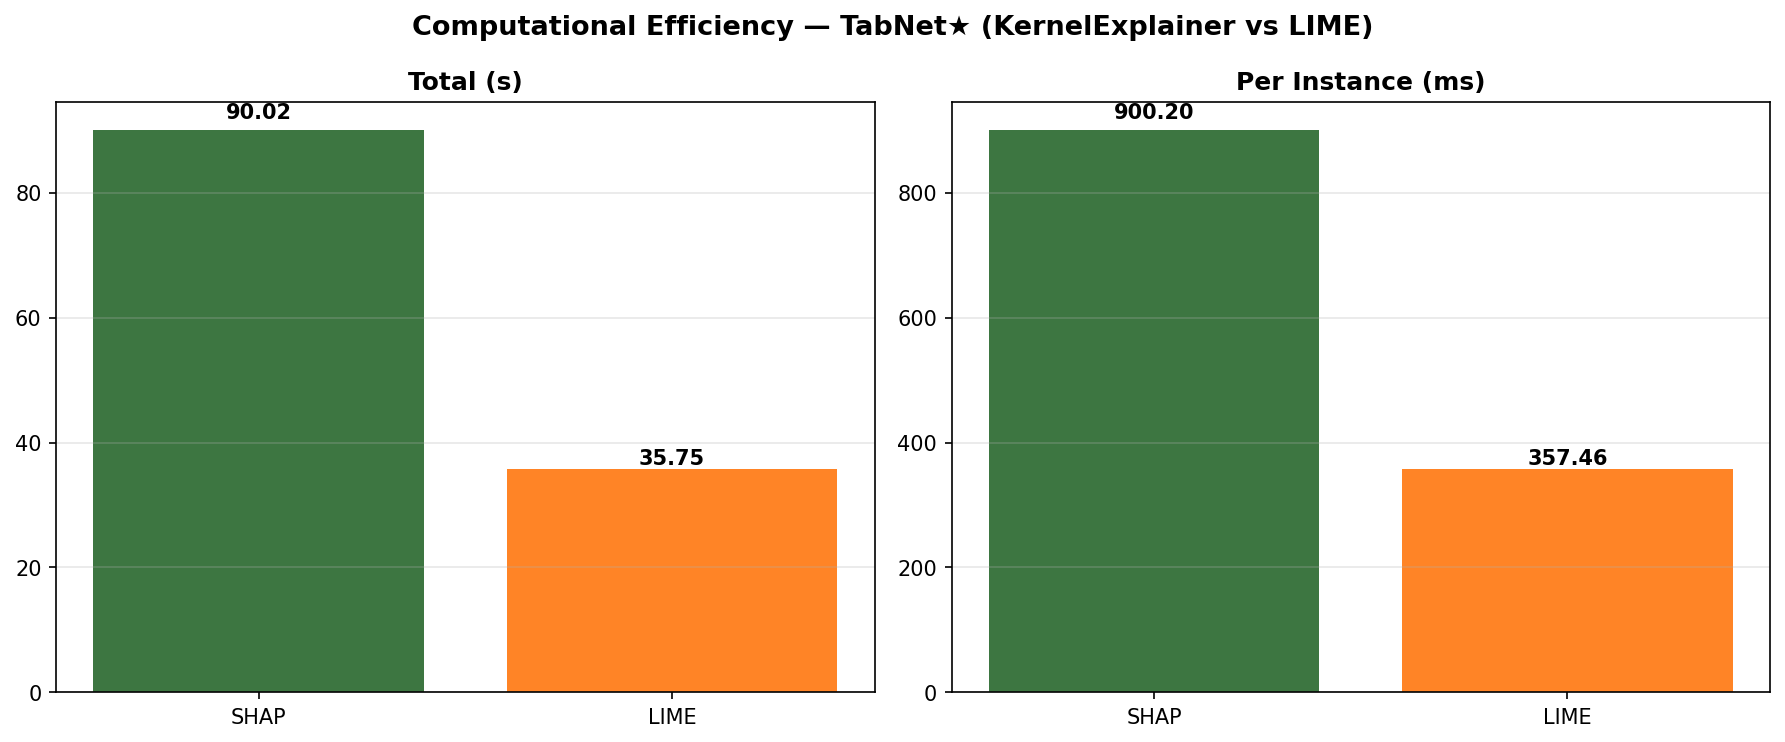


All TabNet analyses complete.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 16 — COMPUTATIONAL EFFICIENCY (SHAP vs LIME for TabNet)
# ════════════════════════════════════════════════════════════════════════════
N_EFF=100; N_LIME_SAMP=LIME_PERTURB_SAMPLES
np.random.seed(SEED)
eff_idx=np.random.choice(len(X_te_p),N_EFF,replace=False); Xe=X_te_p[eff_idx]

bg_sp=shap.sample(X_tr_p,100,random_state=SEED)
se_sp=shap.KernelExplainer(lambda x:tabnet.predict_proba(x.astype(np.float32))[:,1],bg_sp)

# Warm-up
se_sp.shap_values(Xe[:3],nsamples=50)
_=lime_exp_tn.explain_instance(Xe[0],lime_fn_tn,num_features=len(auto_shap_tn),num_samples=N_LIME_SAMP,labels=(1,))

t0=time.time(); se_sp.shap_values(Xe,nsamples=100); shap_eff=time.time()-t0
t0=time.time()
for i in range(N_EFF):
    lime_exp_tn.explain_instance(Xe[i],lime_fn_tn,num_features=len(auto_shap_tn),num_samples=N_LIME_SAMP,labels=(1,))
lime_eff=time.time()-t0

eff=pd.DataFrame({'Method':['SHAP','LIME'],'Total_s':[shap_eff,lime_eff],
    'Per_Instance_ms':[shap_eff/N_EFF*1000,lime_eff/N_EFF*1000]})
eff.to_csv(CSV_DIR/'efficiency_TabNet.csv',index=False)
print(eff.to_string(index=False,float_format='{:.3f}'.format))

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
for ax,vals,title in[(a1,[shap_eff,lime_eff],'Total (s)'),(a2,[shap_eff/N_EFF*1000,lime_eff/N_EFF*1000],'Per Instance (ms)')]:
    bars=ax.bar(['SHAP','LIME'],vals,color=[PRIMARY_COLOR,'#FF6F00'],alpha=0.85)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+v*0.02,f'{v:.2f}',ha='center',fontweight='bold')
    ax.set_title(title,fontweight='bold'); ax.grid(axis='y',alpha=0.3)
plt.suptitle('Computational Efficiency — TabNet★ (KernelExplainer vs LIME)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(FIGURES_DIR/'efficiency_TabNet.png',dpi=150,bbox_inches='tight'); plt.show()
print('\nAll TabNet analyses complete.')


  TabNet★ PRIMARY — Youden's J Optimal Threshold
  Optimal threshold : 0.5381
  Youden's J score  : 0.4430
  (J = Sensitivity + Specificity − 1)

── Default Threshold (0.50) ──────────────────────────
              precision    recall  f1-score   support

     Success     0.6761    0.7926    0.7297      5457
     At-Risk     0.7672    0.6429    0.6996      5803

    accuracy                         0.7155     11260
   macro avg     0.7217    0.7178    0.7147     11260
weighted avg     0.7231    0.7155    0.7142     11260

── Optimal Threshold (J = 0.5381) ───────────────────
              precision    recall  f1-score   support

     Success     0.6674    0.8338    0.7413      5457
     At-Risk     0.7958    0.6092    0.6901      5803

    accuracy                         0.7180     11260
   macro avg     0.7316    0.7215    0.7157     11260
weighted avg     0.7336    0.7180    0.7149     11260


── Gain from Youden's J Threshold ──────────────────
                     Default  Optimal

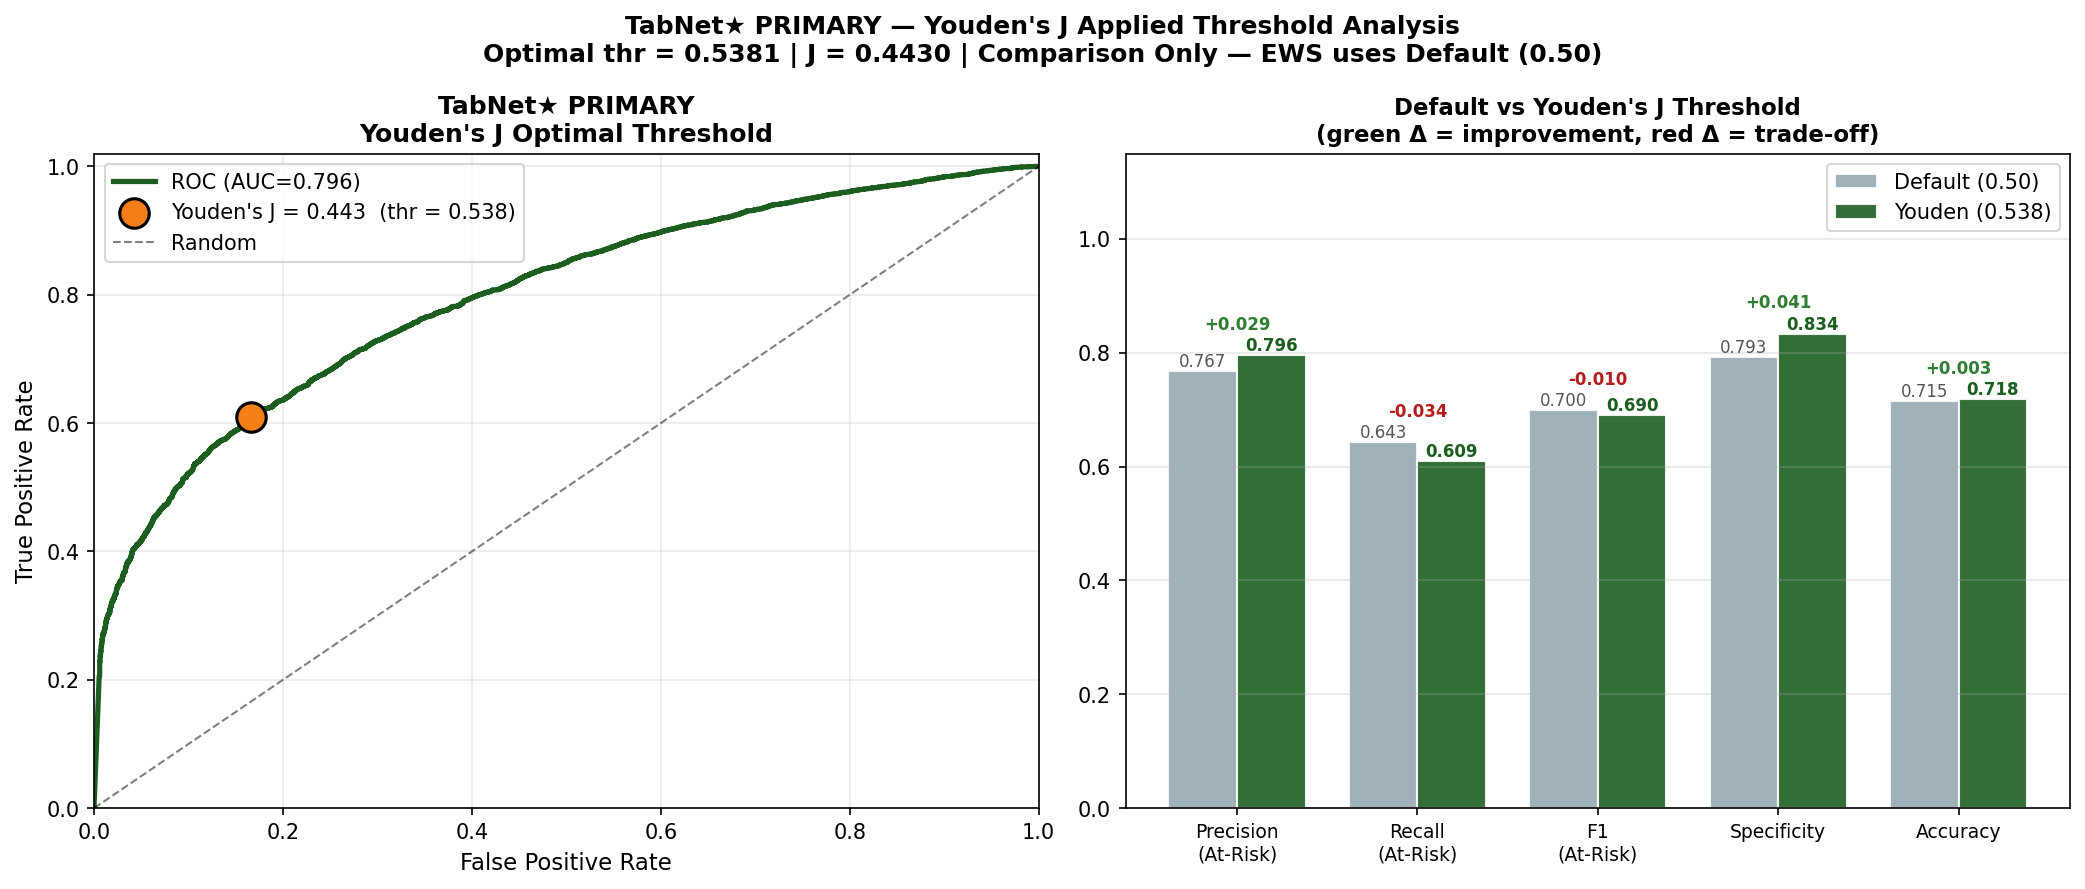

Youden Applied analysis saved.

📌 NOTE: Youden optimal threshold = 0.5381 — For research comparison only.
   Production EWS uses DEFAULT threshold = 0.50 (conservative: avoids missing at-risk students.)
   At-Risk Recall gain  : -0.0338
   Specificity trade-off: +0.0412


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10b — YOUDEN'S J APPLIED THRESHOLD ANALYSIS — TabNet★ PRIMARY


fpr_j, tpr_j, _ = roc_curve(y_test_arr, y_prob_tn)
best_j_idx = np.argmax(tpr_j - fpr_j)
j_score    = float(tpr_j[best_j_idx] - fpr_j[best_j_idx])

yp_default_j = (y_prob_tn >= 0.50).astype(int)
yp_optimal_j = (y_prob_tn >= best_j_thr).astype(int)

print('=' * 57)
print('  TabNet★ PRIMARY — Youden\'s J Optimal Threshold')
print('=' * 57)
print(f'  Optimal threshold : {best_j_thr:.4f}')
print(f'  Youden\'s J score  : {j_score:.4f}')
print(f'  (J = Sensitivity + Specificity − 1)')
print()

# ── Classification reports ────────────────────────────────────────────────
print('── Default Threshold (0.50) ──────────────────────────')
print(classification_report(y_test_arr, yp_default_j,
      target_names=['Success', 'At-Risk'], digits=4))

print(f'── Optimal Threshold (J = {best_j_thr:.4f}) ───────────────────')
print(classification_report(y_test_arr, yp_optimal_j,
      target_names=['Success', 'At-Risk'], digits=4))

# ── Per-metric gain table ─────────────────────────────────────────────────
metrics_compare = {}
for label, yp in [('Default', yp_default_j), ('Optimal', yp_optimal_j)]:
    metrics_compare[label] = {
        'Precision (At-Risk)' : precision_score(y_test_arr, yp, zero_division=0),
        'Recall (At-Risk)'    : recall_score(y_test_arr, yp, zero_division=0),
        'F1 (At-Risk)'        : f1_score(y_test_arr, yp, zero_division=0),
        'Specificity'         : float((yp[y_test_arr == 0] == 0).sum() /
                                       (y_test_arr == 0).sum()),
        'Accuracy'            : accuracy_score(y_test_arr, yp),
    }

tbl = pd.DataFrame({
    'Default' : metrics_compare['Default'],
    'Optimal' : metrics_compare['Optimal'],
})
tbl['Δ (Optimal−Default)'] = tbl['Optimal'] - tbl['Default']
print('\n── Gain from Youden\'s J Threshold ──────────────────')
print(tbl.to_string(float_format='{:.4f}'.format))
tbl.to_csv(CSV_DIR / 'youden_threshold_gain_TabNet_PRIMARY.csv')

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC with Youden point
ax = axes[0]
ax.plot(fpr_j, tpr_j, color=PRIMARY_COLOR, lw=2.5,
        label=f'ROC (AUC={roc_auc_score(y_test_arr, y_prob_tn):.3f})')
ax.scatter(fpr_j[best_j_idx], tpr_j[best_j_idx],
           s=200, zorder=6, color='#F57F17',
           edgecolors='black', linewidths=1.5,
           label=f"Youden\'s J = {j_score:.3f}  (thr = {best_j_thr:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f"TabNet★ PRIMARY\nYouden\'s J Optimal Threshold",
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

# Plot 2: Metric comparison bar chart
ax = axes[1]
metric_names = ['Precision\n(At-Risk)', 'Recall\n(At-Risk)',
                'F1\n(At-Risk)', 'Specificity', 'Accuracy']
metric_keys  = list(metrics_compare['Default'].keys())
default_vals = [metrics_compare['Default'][k] for k in metric_keys]
optimal_vals = [metrics_compare['Optimal'][k] for k in metric_keys]
x = np.arange(len(metric_names)); w = 0.38

bars1 = ax.bar(x - w/2, default_vals, w, label='Default (0.50)',
               color='#90A4AE', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, optimal_vals, w,
               label=f'Youden ({best_j_thr:.3f})',
               color=PRIMARY_COLOR, alpha=0.90, edgecolor='white')

for bar, v in zip(bars1, default_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.008,
            f'{v:.3f}', ha='center', fontsize=8, color='#555')
for bar, v in zip(bars2, optimal_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.008,
            f'{v:.3f}', ha='center', fontsize=8,
            fontweight='bold', color=PRIMARY_COLOR)

for i, (d, o) in enumerate(zip(default_vals, optimal_vals)):
    gain = o - d
    if abs(gain) > 0.001:
        color = '#2E7D32' if gain > 0 else '#B71C1C'
        ax.text(i, max(d, o) + 0.045, f'{gain:+.3f}',
                ha='center', fontsize=8, fontweight='bold', color=color)

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("Default vs Youden\'s J Threshold\n"
             '(green Δ = improvement, red Δ = trade-off)',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    f"TabNet★ PRIMARY — Youden\'s J Applied Threshold Analysis\n"
    f'Optimal thr = {best_j_thr:.4f} | J = {j_score:.4f} | '    f'Comparison Only — EWS uses Default (0.50)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'youden_applied_TabNet_PRIMARY.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Youden Applied analysis saved.')
print(f"\n📌 NOTE: Youden optimal threshold = {best_j_thr:.4f} — For research comparison only.")
print("   Production EWS uses DEFAULT threshold = 0.50 (conservative: avoids missing at-risk students.)")
print(f"   At-Risk Recall gain  : "
      f"{metrics_compare['Optimal']['Recall (At-Risk)'] - metrics_compare['Default']['Recall (At-Risk)']:+.4f}")
print(f"   Specificity trade-off: "
      f"{metrics_compare['Optimal']['Specificity'] - metrics_compare['Default']['Specificity']:+.4f}")


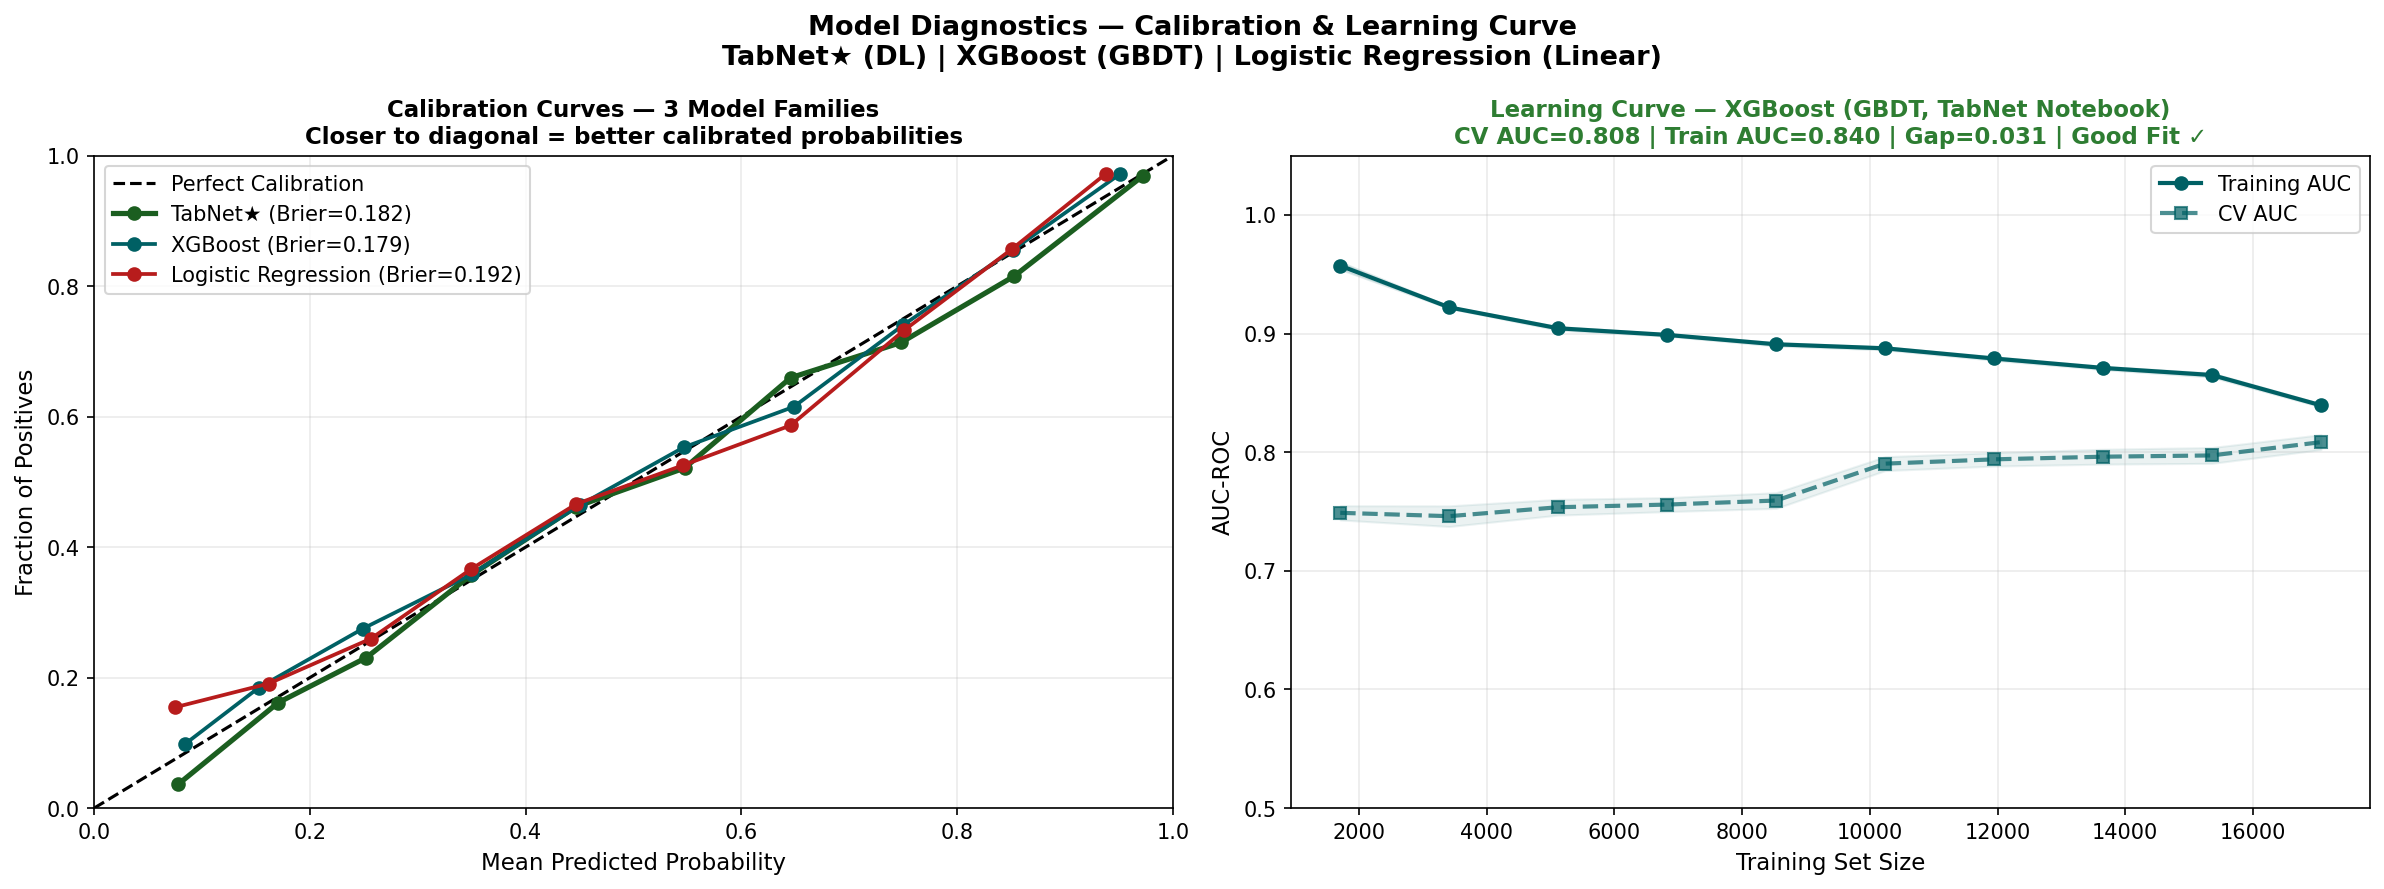

Diagnostics saved.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 13b — CALIBRATION CURVE + LEARNING CURVE
#
# Calibration: compares probability quality across 3 model families.
#   - TabNet★ (DL)  vs  XGBoost (GBDT)  vs  LR (Linear)
#   - Brier Score: lower = better calibrated probabilities.
# ════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Calibration Curve — 3 Model Families ─────────────────────────────────
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect Calibration')

calib_models = [
    ('TabNet★',             y_prob_tn,     PRIMARY_COLOR, 2.5),
    ('XGBoost',             y_prob_xgb_tn, '#006064',     1.8),
    ('Logistic Regression', y_prob_lr,     '#B71C1C',     1.8),
]
for mname, yp, col, lw in calib_models:
    frac_pos, mean_pred = calibration_curve(y_test_arr, yp, n_bins=10)
    bs = brier_score_loss(y_test_arr, yp)
    ax1.plot(mean_pred, frac_pos, marker='o', color=col, lw=lw,
             label=f'{mname} (Brier={bs:.3f})')

ax1.set_xlabel('Mean Predicted Probability', fontsize=11)
ax1.set_ylabel('Fraction of Positives', fontsize=11)
ax1.set_title('Calibration Curves — 3 Model Families\n'
              'Closer to diagonal = better calibrated probabilities',
              fontweight='bold', fontsize=11)
ax1.legend(fontsize=10); ax1.grid(alpha=0.25)
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1])

# ── Learning Curve — XGBoost (GBDT representative) ───────────────────────

train_sizes, train_scores, val_scores = sk_lc(
    xgb_model,
    X_train_sel, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10))

t_mean = train_scores.mean(axis=1); t_std = train_scores.std(axis=1)
v_mean = val_scores.mean(axis=1);   v_std = val_scores.std(axis=1)
gap    = float(t_mean[-1] - v_mean[-1])

# ── 4-Criterion Academic Generalisation Verdict ───────────────────────────
cv_adequate = v_mean[-1] >= 0.70
cv_stable   = (v_mean[-1] - v_mean[0]) > -0.05
gap_growing = (gap - float(t_mean[0] - v_mean[0])) > 0.10

if not cv_adequate:
    verdict, verdict_c = 'Underfitting ⚠', '#B71C1C'
elif gap_growing and not cv_stable:
    verdict, verdict_c = 'Progressive Overfitting ⚠', '#E65100'
elif gap > 0.05 and cv_stable and not gap_growing:
    verdict, verdict_c = 'High Variance — Stable Generalisation ✓', '#1565C0'
elif gap <= 0.05 and cv_adequate:
    verdict, verdict_c = 'Good Fit ✓', '#2E7D32'
else:
    verdict, verdict_c = 'Acceptable Fit ✓', '#2E7D32'

ax2.plot(train_sizes, t_mean, 'o-', color='#006064', lw=2, label='Training AUC')
ax2.fill_between(train_sizes, t_mean - t_std, t_mean + t_std,
                 alpha=0.12, color='#006064')
ax2.plot(train_sizes, v_mean, 's--', color='#006064', lw=2,
         alpha=0.7, label='CV AUC')
ax2.fill_between(train_sizes, v_mean - v_std, v_mean + v_std,
                 alpha=0.08, color='#006064')
ax2.set_xlabel('Training Set Size', fontsize=11)
ax2.set_ylabel('AUC-ROC', fontsize=11)
ax2.set_title(
    f'Learning Curve — XGBoost (GBDT, TabNet Notebook)\n'
    f'CV AUC={v_mean[-1]:.3f} | Train AUC={t_mean[-1]:.3f} | '
    f'Gap={gap:.3f} | {verdict}',
    fontweight='bold', color=verdict_c, fontsize=11)
ax2.legend(fontsize=10); ax2.grid(alpha=0.25); ax2.set_ylim([0.5, 1.05])

plt.suptitle(
    'Model Diagnostics — Calibration & Learning Curve\n'
    'TabNet★ (DL) | XGBoost (GBDT) | Logistic Regression (Linear)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'diagnostics_TabNet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagnostics saved.')


LIME sensitivity analysis (TabNet primary) ...
     Setting    Group  vs_reference_tau      p
perturb=1000  perturb            0.9667 0.0000
perturb=2500  perturb            0.9667 0.0000
perturb=5000  perturb            0.9500 0.0000
global_n=150 global_n            0.9167 0.0000
global_n=300 global_n            0.9500 0.0000


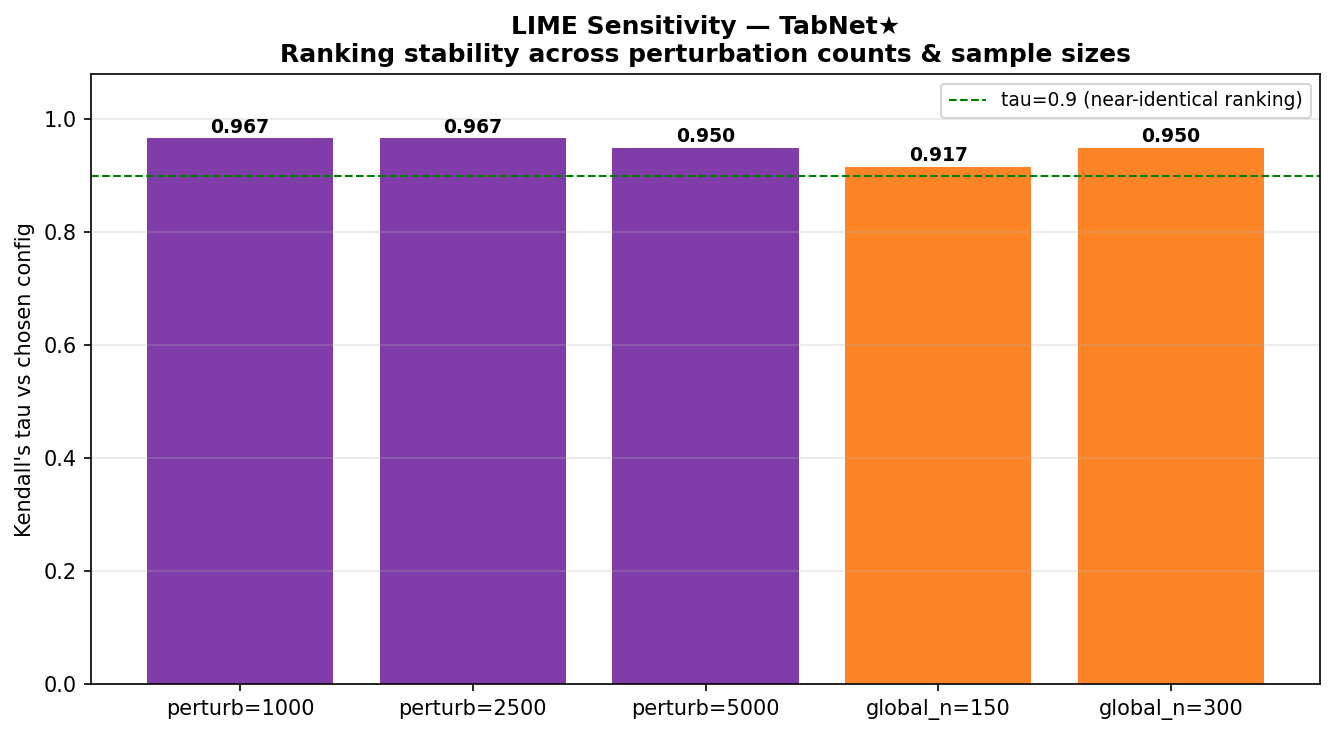


Interpretation: tau close to 1.0 => the adopted configuration (5,000 perturbations, global_n=300) is empirically justified.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# LIME SENSITIVITY ANALYSIS — justifies n_lime_samples (perturbations) & LIME_GLOBAL_N
# TabNet is costly, so sensitivity varies:
#   (a) perturbation counts {1000,2500,5000} at the standard global sample size
#   (b) global sample sizes {150,300} at the standard perturbation count
# Rank agreement vs the adopted configuration via Kendall's tau.
# ════════════════════════════════════════════════════════════════════════════
print('LIME sensitivity analysis (TabNet primary) ...')
_ref_order = list(lime_global_tn.index)

def _tau_vs_ref(r):
    return kendalltau([_ref_order.index(f) for f in _ref_order],
                       [list(r.index).index(f) for f in _ref_order])

sens_rows = []

# (a) Perturbation-count sensitivity (global sample fixed at LIME_GLOBAL_N)
for ns in [1000, 2500, 5000]:
    r = compute_lime_global_tn(lime_fn_tn, X_te_p, y_test_arr,
                                n_samples=LIME_GLOBAL_N, n_lime_samples=ns, seed=SEED)
    tau_s, p_s = _tau_vs_ref(r)
    sens_rows.append({'Setting': f'perturb={ns}', 'Group': 'perturb', 'vs_reference_tau': tau_s, 'p': p_s})

# (b) Global-sample-size sensitivity (perturbation count fixed at LIME_PERTURB_SAMPLES)
for gn in [150, 300]:
    r = compute_lime_global_tn(lime_fn_tn, X_te_p, y_test_arr,
                                n_samples=gn, n_lime_samples=LIME_PERTURB_SAMPLES, seed=SEED)
    tau_s, p_s = _tau_vs_ref(r)
    sens_rows.append({'Setting': f'global_n={gn}', 'Group': 'global_n', 'vs_reference_tau': tau_s, 'p': p_s})

sens_df = pd.DataFrame(sens_rows)
try: sens_df.to_csv(CSV_DIR / 'lime_sensitivity.csv', index=False)
except Exception: sens_df.to_csv('lime_sensitivity.csv', index=False)
print(sens_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#6A1B9A' if g == 'perturb' else '#FF6F00' for g in sens_df['Group']]
bars = ax.bar(sens_df['Setting'], sens_df['vs_reference_tau'], color=colors, alpha=0.85)
for bar, v in zip(bars, sens_df['vs_reference_tau']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
ax.axhline(0.9, color='green', linestyle='--', linewidth=1, label='tau=0.9 (near-identical ranking)')
ax.set_ylabel("Kendall's tau vs chosen config"); ax.set_ylim(0,1.08)
ax.set_title("LIME Sensitivity — TabNet\u2605\nRanking stability across perturbation counts & sample sizes", fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
try: plt.savefig(FIGURES_DIR / 'lime_sensitivity.png', dpi=150, bbox_inches='tight')
except Exception: plt.savefig('lime_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInterpretation: tau close to 1.0 => the adopted configuration (5,000 perturbations, global_n=300) is empirically justified.')

In [ ]:
import joblib
from pathlib import Path

for p in sorted(Path('models_TabNet').glob('*.pkl')):
    m = joblib.load(p)
    clf = m.named_steps['clf'] if hasattr(m, 'named_steps') else m
    print(f'\n--- {p.stem} ---')
    for k, v in clf.get_params().items():
        if v is not None and k not in ('random_state','n_jobs','verbose'):
            print(f'  {k}: {v}')


--- XGBoost_in_TabNet ---
  objective: binary:logistic
  enable_categorical: True
  eval_metric: logloss
  learning_rate: 0.05
  max_depth: 4
  missing: nan
  n_estimators: 200
  scale_pos_weight: 0.8704953967558089
  subsample: 0.8


In [ ]:
print(df.groupby('code_presentation')['target'].agg(['size','sum','mean']))

                    size   sum   mean
code_presentation                    
2013B               4684  2589 0.5527
2013J               8845  4370 0.4941
2014B               7804  4446 0.5697
2014J              11260  5803 0.5154
